# Data Download

In [1]:
import pandas as pd
df_train = pd.read_csv("/kaggle/input/datasets/hmgfils/tour-data/train.csv")
df_test = pd.read_csv("/kaggle/input/datasets/hmgfils/tour-data/test.csv")

# Preview of the Training Data

In [2]:
df_train.head()

,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
0,dtf_0000001_ffa5beb5,0,op_05,636.75,acc_o_307358626ad66fed,87.00,-549.75,acc_d_7fac3b16af7d127b,630.88,1267.62,0
1,dtf_0000002_61992e82,0,op_05,636.12,acc_o_aeb690c57bf5d1de,76.93,76.93,acc_d_1d6120e8b117aa14,731.70,731.70,0
2,dtf_0000003_9a123b6d,0,op_05,681.00,acc_o_655c41913944d2b7,15943.74,15262.75,acc_d_ec2c21517a0ccb1a,758.83,1439.84,0
3,dtf_0000004_240f3dae,0,op_03,28175.40,acc_o_ba23a2b955a79a8b,-443.88,-28619.28,acc_d_a3dd8504815ec133,770924.84,799100.24,0
4,dtf_0000005_f18939e7,0,op_03,86429.15,acc_o_d05a23079bd066c1,-670.85,-87100.01,acc_d_0d4880267e62d5c4,91.13,86520.29,0


In [3]:
period_counts = df_train['period'].value_counts().sort_index()
print(period_counts)

period
0      6407
1      8687
2      7182
3      6653
4      6620
       ... 
101    7973
102    7955
103    7911
104    7926
105    7921
Name: count, Length: 106, dtype: int64


#  **Comprehensive Dataset Summary**

This section provides a comprehensive overview of the training and test datasets, including:

- Dataset dimensions
- Feature types (numerical and categorical)
- Target variable distribution
- Missing values
- Memory usage
- Summary statistics for numerical features
- Summary statistics for categorical features
- Cardinality of categorical features

In [4]:
import pandas as pd
import numpy as np

print("=" * 80)
print("RÉSUMÉ GLOBAL DES DONNÉES")
print("=" * 80)

# ============================================================
# Dimensions
# ============================================================
print("\n📊 DIMENSIONS")
print(f"df_train : {df_train.shape[0]:,} lignes × {df_train.shape[1]} colonnes")
print(f"df_test  : {df_test.shape[0]:,} lignes × {df_test.shape[1]} colonnes")

# ============================================================
# Types de colonnes
# ============================================================
num_cols_train = df_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_train = df_train.select_dtypes(exclude=[np.number]).columns.tolist()

num_cols_test = df_test.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_test = df_test.select_dtypes(exclude=[np.number]).columns.tolist()

print("\n📌 DF_TRAIN")
print(f"Colonnes numériques    : {len(num_cols_train)}")
print(f"Colonnes catégorielles : {len(cat_cols_train)}")

print("\n📌 DF_TEST")
print(f"Colonnes numériques    : {len(num_cols_test)}")
print(f"Colonnes catégorielles : {len(cat_cols_test)}")

# ============================================================
# Variable cible
# ============================================================
target_col = "fraud_flag"

if target_col in df_train.columns:
    print("\n🎯 VARIABLE CIBLE")
    
    counts = df_train[target_col].value_counts().sort_index()
    rates = df_train[target_col].value_counts(normalize=True).sort_index()

    print("\nEffectifs :")
    print(counts)

    print("\nProportions :")
    print((rates * 100).round(2).astype(str) + "%")

# ============================================================
# Valeurs manquantes
# ============================================================
print("\n🕳️ VALEURS MANQUANTES")

train_missing = df_train.isna().sum().sum()
test_missing = df_test.isna().sum().sum()

print(f"df_train : {train_missing:,}")
print(f"df_test  : {test_missing:,}")

# ============================================================
# Mémoire
# ============================================================
train_mem = df_train.memory_usage(deep=True).sum() / 1024**2
test_mem = df_test.memory_usage(deep=True).sum() / 1024**2

print("\n💾 UTILISATION MÉMOIRE")
print(f"df_train : {train_mem:.2f} MB")
print(f"df_test  : {test_mem:.2f} MB")

# ============================================================
# Statistiques numériques
# ============================================================
print("\n📈 STATISTIQUES NUMÉRIQUES (df_train)")
print(df_train[num_cols_train].describe().T)

# ============================================================
# Statistiques catégorielles
# ============================================================
if len(cat_cols_train) > 0:
    print("\n📋 STATISTIQUES CATÉGORIELLES (df_train)")
    print(df_train[cat_cols_train].describe().T)

# ============================================================
# Cardinalité des variables catégorielles
# ============================================================
if len(cat_cols_train) > 0:
    print("\n🔢 CARDINALITÉ DES VARIABLES CATÉGORIELLES")
    
    cardinality = pd.DataFrame({
        "colonne": cat_cols_train,
        "modalites_uniques": [df_train[c].nunique() for c in cat_cols_train]
    }).sort_values("modalites_uniques", ascending=False)

    print(cardinality.to_string(index=False))

print("\n" + "=" * 80)
print("FIN DU RAPPORT")
print("=" * 80)

RÉSUMÉ GLOBAL DES DONNÉES

📊 DIMENSIONS
df_train : 1,290,081 lignes × 11 colonnes
df_test  : 430,100 lignes × 10 colonnes

📌 DF_TRAIN
Colonnes numériques    : 7
Colonnes catégorielles : 4

📌 DF_TEST
Colonnes numériques    : 6
Colonnes catégorielles : 4

🎯 VARIABLE CIBLE

Effectifs :
fraud_flag
0    1160539
1     129542
Name: count, dtype: int64

Proportions :
fraud_flag
0    89.96%
1    10.04%
Name: proportion, dtype: object

🕳️ VALEURS MANQUANTES
df_train : 0
df_test  : 0

💾 UTILISATION MÉMOIRE
df_train : 394.93 MB
df_test  : 128.39 MB

📈 STATISTIQUES NUMÉRIQUES (df_train)
                                count          mean           std        min  \
period                      1290081.0  4.463454e+01  2.946460e+01       0.00   
amount                      1290081.0  6.416038e+04  1.055554e+05       0.37   
origin_balance_before       1290081.0  2.875629e+06  1.595036e+06 -235838.15   
origin_balance_after        1290081.0  2.889497e+06  1.579518e+06 -235838.15   
destination_balance

# **Dataset Summary Interpretation**

| Aspect | Observation | Interpretation |
|---------|-------------|----------------|
| **Dataset Size** | **Train:** 1,290,081 rows × 11 columns<br>**Test:** 430,100 rows × 10 columns | The dataset is large enough to train complex machine learning models. The test set does not contain the target variable (`fraud_flag`), which is expected for a prediction task. |
| **Feature Types** | Train: **7 numerical**, **4 categorical** features.<br>Test: **6 numerical**, **4 categorical** features. | Most variables are numerical, while categorical variables mainly represent identifiers and transaction types. The only missing numerical feature in the test set is the target variable. |
| **Target Distribution** | Non-fraud: **1,160,539 (89.96%)**<br>Fraud: **129,542 (10.04%)** | The dataset is **moderately imbalanced**, with fraudulent transactions representing about 10% of the observations. This justifies using evaluation metrics such as **PR-AUC** instead of accuracy. |
| **Missing Values** | No missing values in either dataset. | No imputation or missing-value treatment is required before modeling. |
| **Memory Usage** | Train: **394.93 MB**<br>Test: **128.39 MB** | The datasets fit comfortably into memory, allowing efficient preprocessing and model training without special memory optimization. |
| **Numerical Features** | Transaction amounts vary from **0.37** to over **2.5 million**. Account balances also span a very wide range and include a few negative values. | The numerical variables exhibit high variability and likely contain outliers. Log transformations or robust feature engineering may improve model performance. Negative balances should be investigated as they may represent overdrafts or data inconsistencies. |
| **Categorical Features** | `operation` has **5 categories**.<br>`origin_account` has **13,431 unique values**.<br>`destination_account` has **15,818 unique values**.<br>`id` is unique for every record. | `operation` is a low-cardinality categorical feature suitable for one-hot or target encoding. Account identifiers are high-cardinality features that may benefit from frequency encoding, target encoding, or aggregation-based feature engineering. The `id` column is only an identifier and should not be used directly for prediction. |
| **Identifier Column** | Every `id` value is unique. | The `id` column carries no predictive information by itself and should be excluded from model training while being retained for submission generation. |
| **Overall Assessment** | Large dataset, no missing values, moderate class imbalance, and several high-cardinality categorical features. | The dataset is well suited for gradient boosting algorithms such as CatBoost, LightGBM, and XGBoost. Feature engineering on account identifiers and transaction balances is likely to provide the greatest performance improvements. |

#  **Target Variable Distribution**

The target variable (`fraud_flag`) exhibits a **moderately imbalanced** distribution.

| Observation | Interpretation |
|--------------|----------------|
| **Non-fraud (Class 0): 89.96%** | The majority of transactions are legitimate, representing nearly 90% of the dataset. |
| **Fraud (Class 1): 10.04%** | Fraudulent transactions account for approximately one out of every ten transactions. |
| **Class imbalance** | Although the imbalance is not extreme, it is significant enough to influence model training and evaluation. |
| **Pie chart** | The pie chart clearly illustrates the dominance of legitimate transactions over fraudulent ones. |
| **Count plot** | The count plot confirms the numerical imbalance between the two classes and provides the exact number of observations in each class. |
| **Fraud rate** | The overall fraud rate is **10.04%**, meaning that approximately one transaction out of ten is fraudulent. |
| **Modeling implication** | Since the positive class is underrepresented, evaluation metrics such as **Precision-Recall AUC (PR-AUC)**, **Precision**, **Recall**, and **F1-score** are more appropriate than overall accuracy. Class weighting or sampling techniques may also improve model performance. |

### Key Takeaways

- The dataset is **moderately imbalanced**, with fraudulent transactions representing about **10%** of all observations.
- A naive classifier predicting every transaction as legitimate would achieve nearly **90% accuracy**, making accuracy an unreliable performance metric.
- Special attention should therefore be given to detecting the minority (fraud) class during model development.

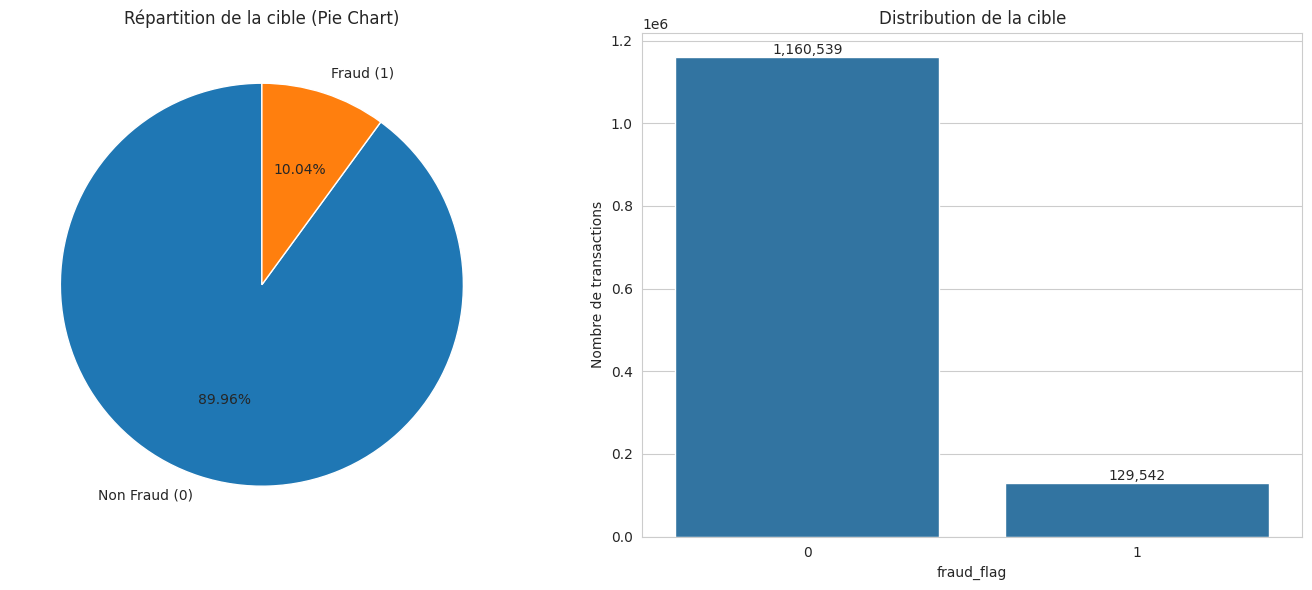

RÉPARTITION DE LA CIBLE

Effectifs :
fraud_flag
0    1160539
1     129542
Name: count, dtype: int64

Pourcentages :
fraud_flag
0    89.96
1    10.04
Name: proportion, dtype: float64

Taux de fraude : 10.04%


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
sns.set_style("whitegrid")

# Comptage
target_counts = df_train['fraud_flag'].value_counts().sort_index()

# Création de la figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================================
# Diagramme circulaire
# ==========================================================
axes[0].pie(
    target_counts,
    labels=['Non Fraud (0)', 'Fraud (1)'],
    autopct='%1.2f%%',
    startangle=90
)

axes[0].set_title('Répartition de la cible (Pie Chart)')

# ==========================================================
# Histogramme / Countplot
# ==========================================================
ax = sns.countplot(
    x='fraud_flag',
    data=df_train,
    ax=axes[1]
)

axes[1].set_title('Distribution de la cible')
axes[1].set_xlabel('fraud_flag')
axes[1].set_ylabel('Nombre de transactions')

# Ajouter les valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

# ==========================================================
# Affichage numérique
# ==========================================================
print("=" * 60)
print("RÉPARTITION DE LA CIBLE")
print("=" * 60)

print("\nEffectifs :")
print(df_train['fraud_flag'].value_counts())

print("\nPourcentages :")
print(
    (df_train['fraud_flag']
     .value_counts(normalize=True)
     .mul(100)
     .round(2))
)

print(f"\nTaux de fraude : {df_train['fraud_flag'].mean()*100:.2f}%")

# **Distribution of Numerical Features by Target Class**

This analysis compares the distribution of each numerical feature across the two target classes (`fraud_flag = 0` and `fraud_flag = 1`) using histograms with kernel density estimation (KDE).

| Observation | Interpretation |
|--------------|----------------|
| **Distribution comparison** | Each numerical feature is visualized separately for legitimate and fraudulent transactions, allowing direct comparison between the two classes. |
| **Density normalization** | The distributions are displayed as densities (`stat="density"`), making the comparison independent of the class sizes despite the class imbalance. |
| **Kernel Density Estimation (KDE)** | The KDE curves provide a smooth representation of each feature's distribution and help identify differences that may not be obvious from the histograms alone. |
| **Distribution overlap** | Features with little overlap between the two classes are likely to be more discriminative and therefore more useful for fraud detection. |
| **Distribution similarity** | If both classes exhibit nearly identical distributions, the feature is unlikely to contribute significantly to classification performance when considered alone. |
| **Outliers and skewness** | Histograms also reveal skewed distributions, heavy tails, or extreme values, indicating that transformations such as logarithmic scaling or robust feature engineering may be beneficial. |

### Key Takeaways

- Compare the distribution of each numerical feature between fraudulent and non-fraudulent transactions.
- Identify features that clearly separate the two classes.
- Detect skewed distributions and potential outliers.
- Select promising variables for feature engineering and predictive modeling.

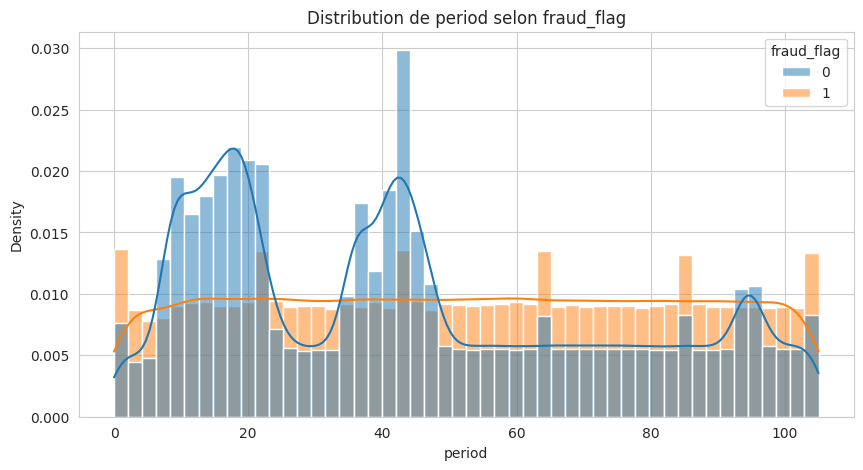

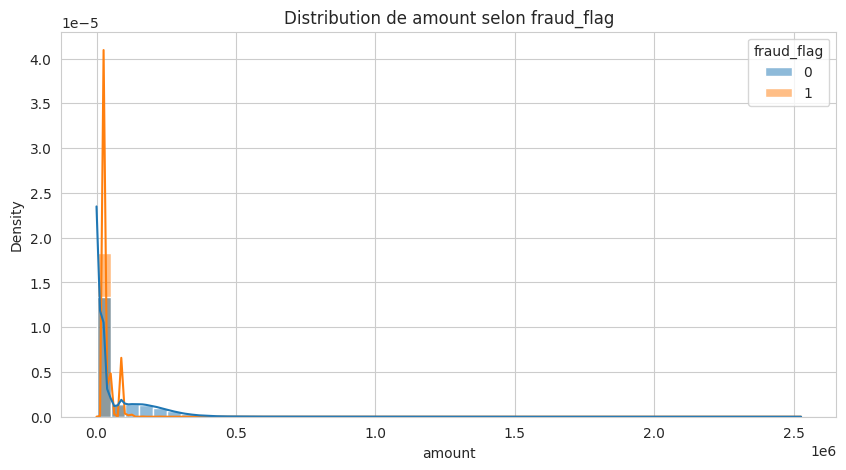

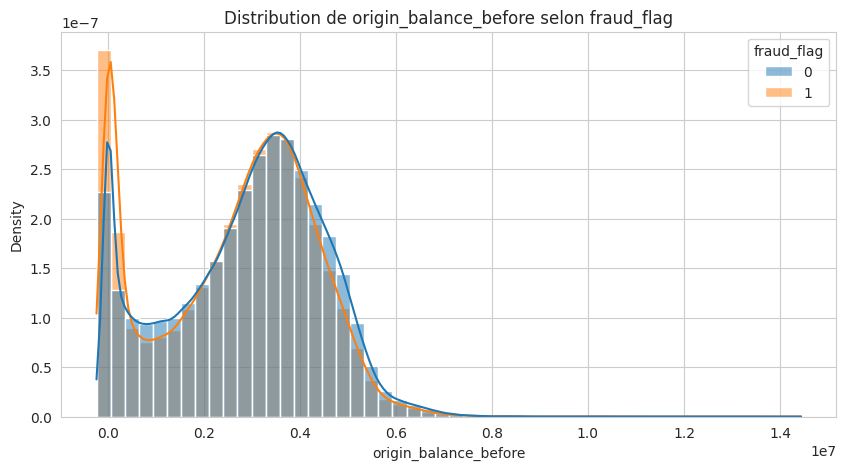

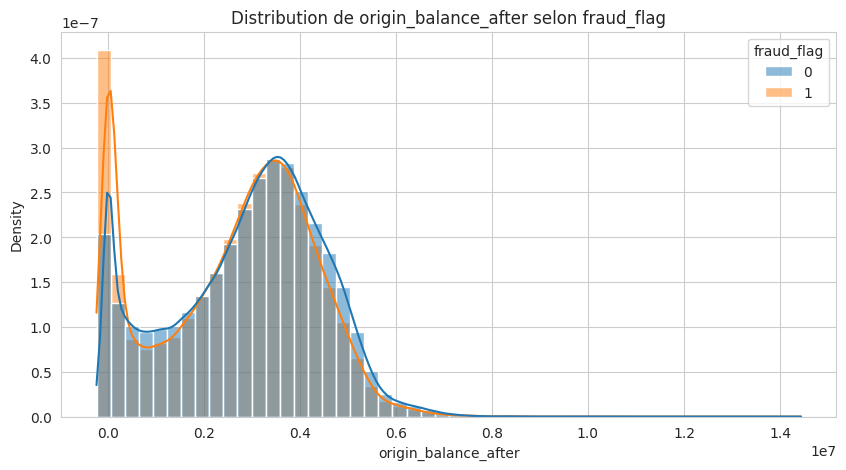

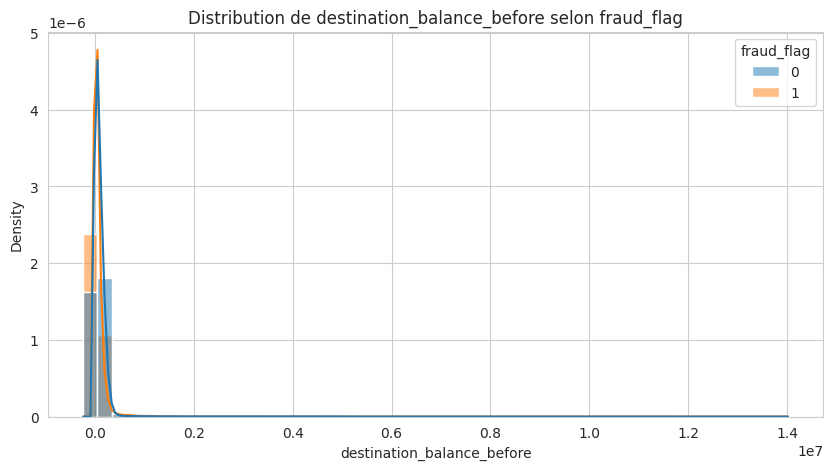

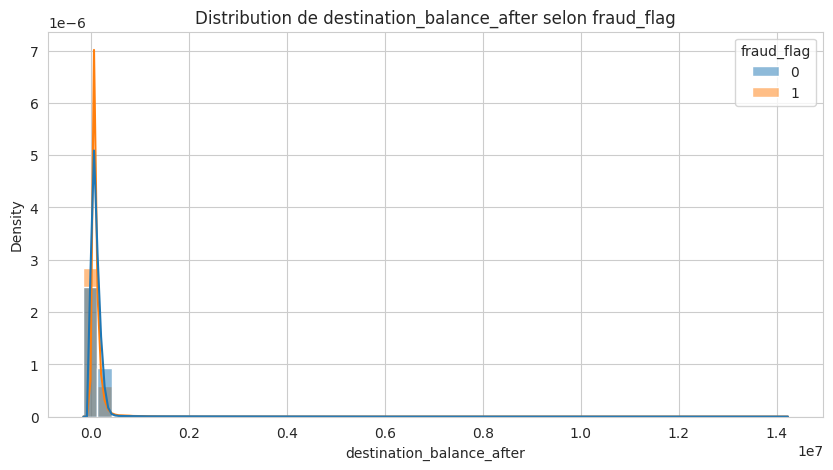

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

target = "fraud_flag"

num_cols = df_train.select_dtypes(include=np.number).columns.tolist()

if target in num_cols:
    num_cols.remove(target)

for col in num_cols:
    plt.figure(figsize=(10,5))

    sns.histplot(
        data=df_train,
        x=col,
        hue=target,
        bins=50,
        stat="density",
        common_norm=False,
        kde=True
    )

    plt.title(f"Distribution de {col} selon {target}")
    plt.show()

### **Conclusion**

From the distribution plots, we observe that most numerical features exhibit **highly skewed (asymmetric) distributions**, with the presence of long tails and potential outliers.

These characteristics indicate that special care should be taken when handling extreme values, as they may significantly influence statistical analyses and machine learning models. Appropriate preprocessing techniques, such as robust transformations or feature engineering, should therefore be considered.

However, visual inspection alone is not sufficient to draw definitive conclusions. The observed patterns should be **validated using rigorous statistical tests** (e.g., normality tests, skewness and kurtosis measures, or outlier detection methods) to objectively assess the distributional properties of each feature before making preprocessing decisions.

# **Boxplot Analysis of Numerical Features**

The boxplots compare the distribution of each numerical feature across the two target classes (`fraud_flag = 0` and `fraud_flag = 1`).

| Observation | Interpretation |
|--------------|----------------|
| **Median comparison** | Differences in the median values between the two classes may indicate that a feature is informative for distinguishing fraudulent from legitimate transactions. |
| **Interquartile Range (IQR)** | The spread of the boxes reflects the variability of each feature. A larger IQR indicates greater dispersion within a class. |
| **Outliers** | Numerous observations lie outside the whiskers, suggesting the presence of many extreme values. These outliers may correspond to rare but meaningful transaction behaviors rather than data errors. |
| **Class separation** | Features whose boxplots differ substantially between the two classes are likely to have stronger predictive power. Conversely, heavily overlapping boxplots indicate weaker discriminative ability. |
| **Distribution variability** | Differences in spread and variability between the two classes may reveal distinct transaction patterns associated with fraudulent activities. |

### **Conclusion**

The boxplots confirm that several numerical features contain a **large number of outliers** and exhibit **high variability**. Since fraud detection datasets often contain genuine extreme transactions, these outliers should **not be removed indiscriminately**. Instead, they should be carefully analyzed to determine whether they represent fraudulent behavior or legitimate but unusual transactions.

Moreover, visual inspection should be complemented with **rigorous statistical analyses**, such as outlier detection methods (e.g., IQR, Z-score, or robust statistics), to objectively assess the significance of these extreme observations before applying any preprocessing techniques.

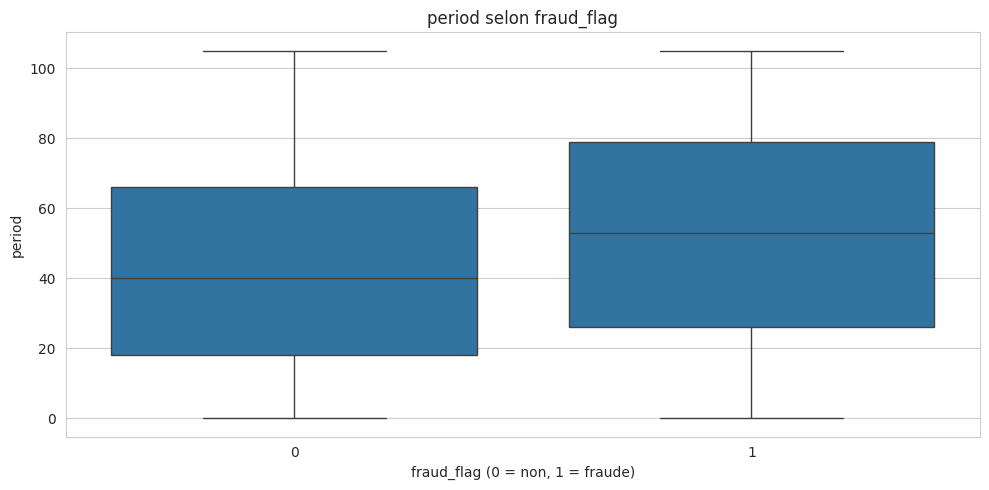

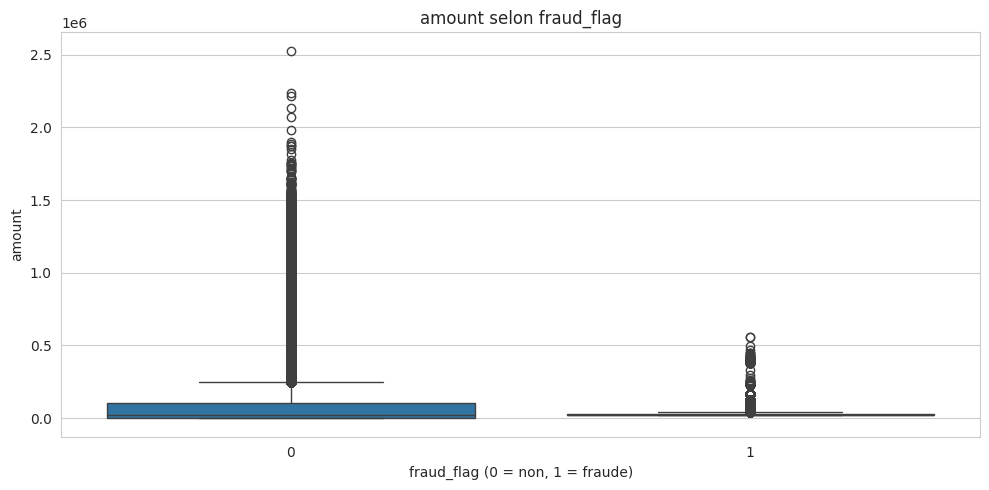

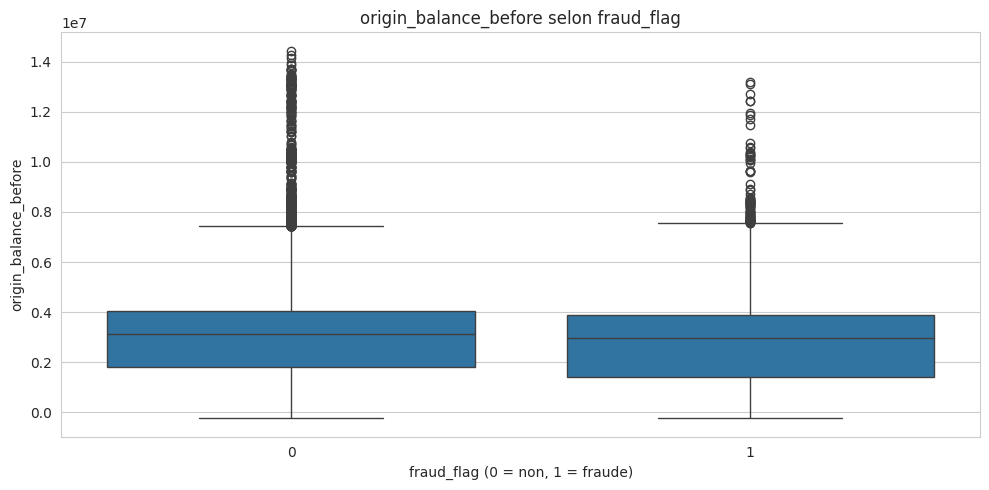

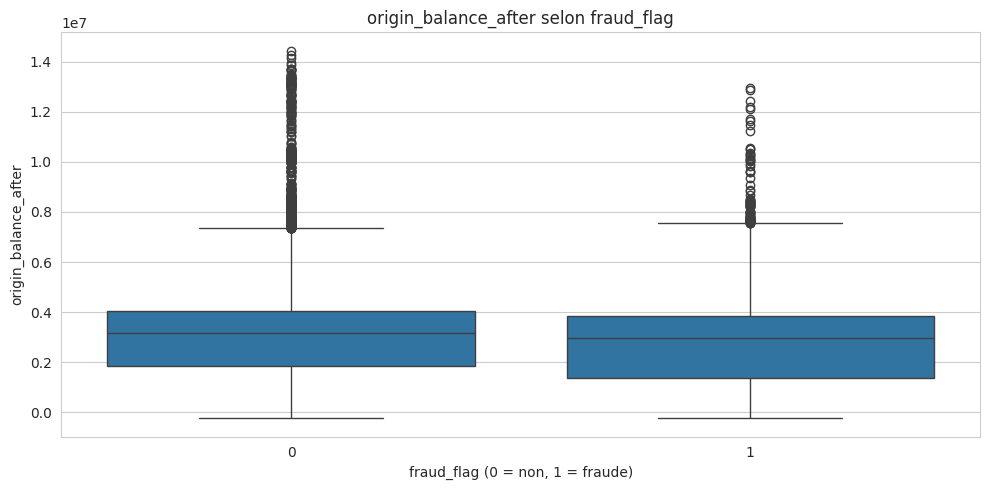

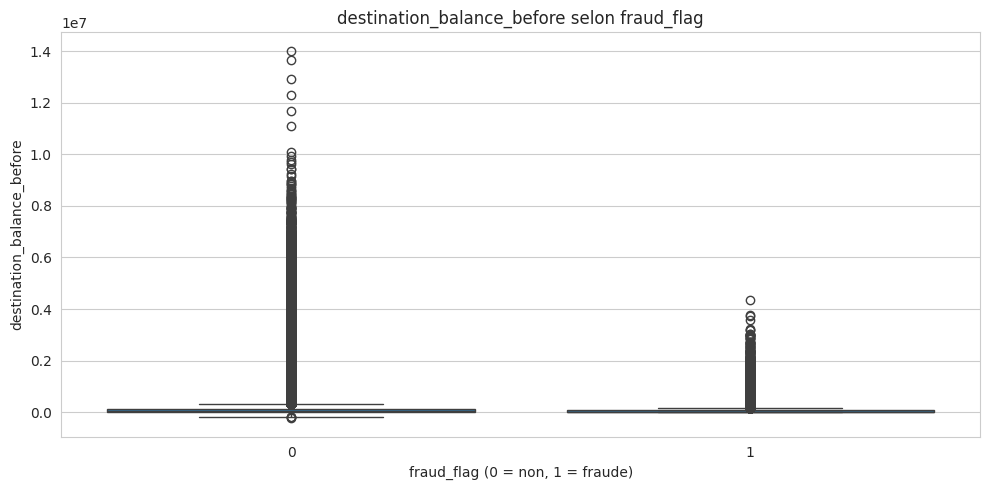

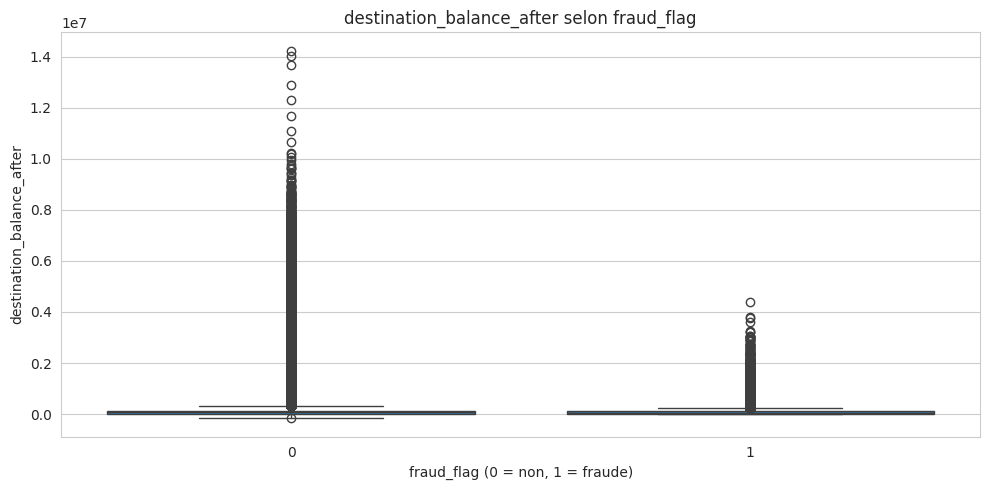

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

target = "fraud_flag"

num_cols = df_train.select_dtypes(include=np.number).columns.tolist()

if target in num_cols:
    num_cols.remove(target)

for col in num_cols:

    plt.figure(figsize=(10,5))

    sns.boxplot(
        data=df_train,
        x=target,
        y=col
    )

    plt.title(f"{col} selon fraud_flag")
    plt.xlabel("fraud_flag (0 = non, 1 = fraude)")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

# **Categorical Feature Analysis by Target Class**

This analysis examines the distribution of fraudulent and legitimate transactions across the most frequent categories of each categorical feature using stacked bar charts.

| Observation | Interpretation |
|--------------|----------------|
| **Fraud rate by category** | Each bar represents the percentage of fraudulent and non-fraudulent transactions within a given category, allowing direct comparison of fraud prevalence across categories. |
| **Category discrimination** | Categories with noticeably higher fraud proportions may carry strong predictive information and should be considered important features for model training. |
| **Dominant categories** | Only the 20 most frequent categories are displayed to improve readability while focusing on the categories that contribute most to the dataset. |
| **Balanced vs. unbalanced categories** | Categories with similar fraud proportions are less informative, whereas those with large differences between classes are more likely to help distinguish fraudulent transactions. |
| **High-cardinality features** | Variables such as account identifiers may contain thousands of unique values. Although only the most frequent categories are visualized, these features may still provide valuable information through appropriate encoding or aggregation techniques. |.

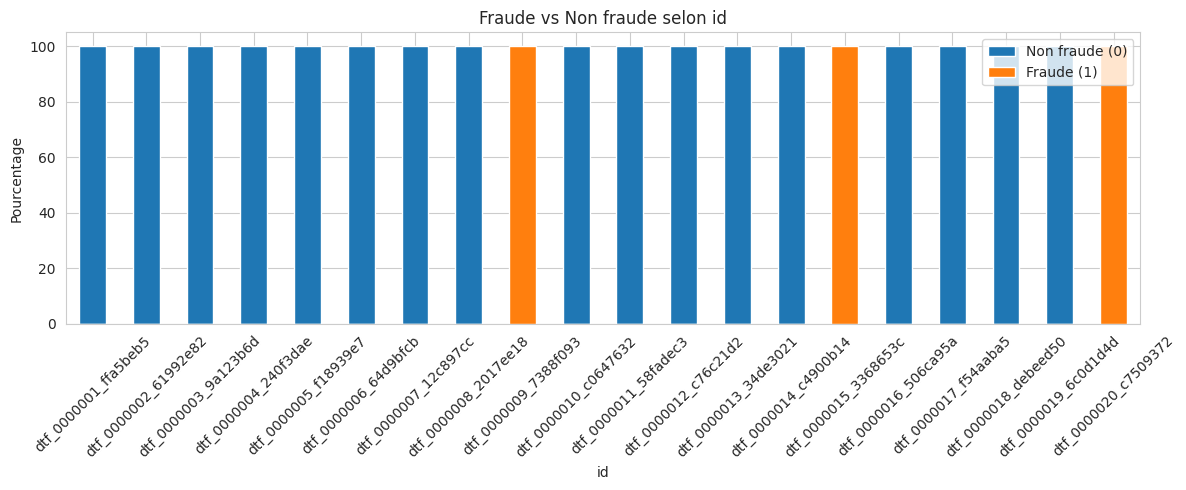

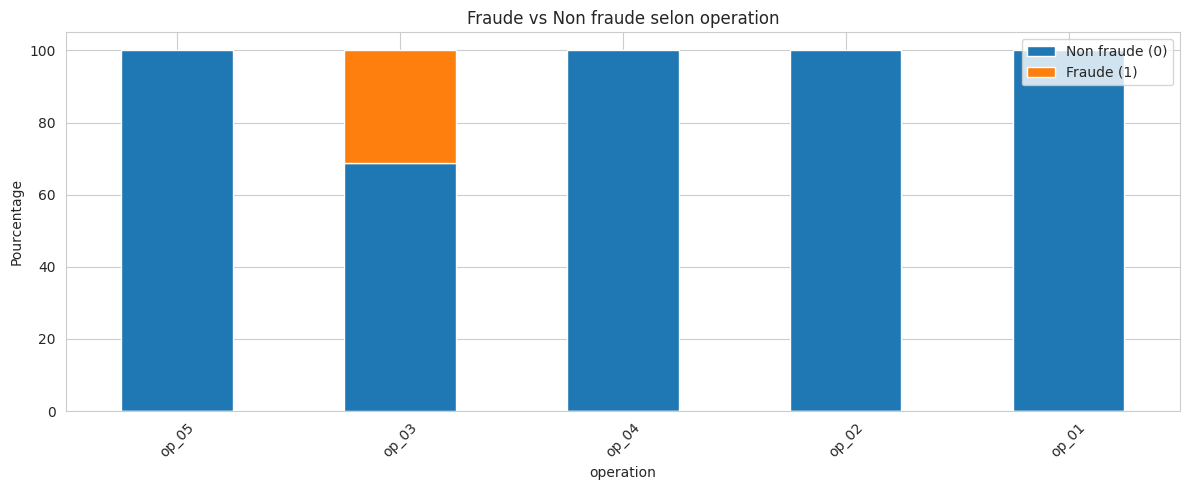

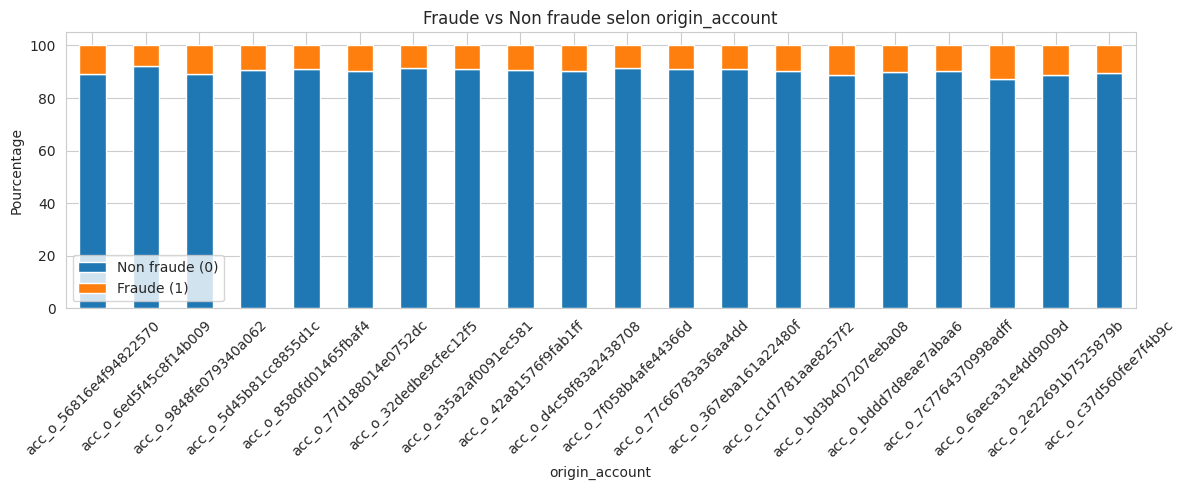

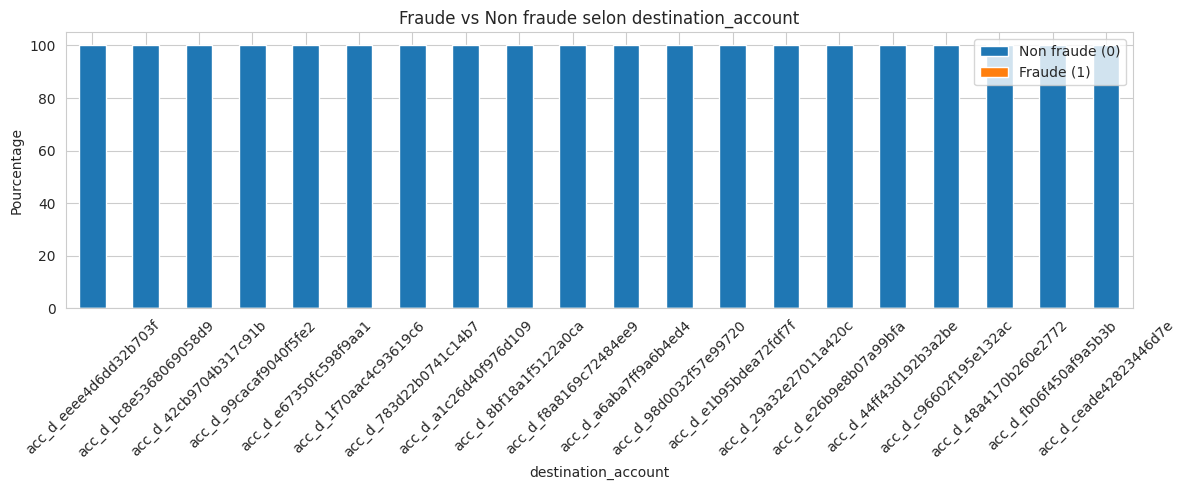

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

target = "fraud_flag"

cat_cols = df_train.select_dtypes(exclude=np.number).columns.tolist()

for col in cat_cols:

    # Pourcentage fraude / non fraude par catégorie
    tab = pd.crosstab(
        df_train[col],
        df_train[target],
        normalize='index'
    ) * 100

    # garder les 20 modalités les plus fréquentes
    top_categories = df_train[col].value_counts().head(20).index
    tab = tab.loc[top_categories]

    tab.plot(
        kind='bar',
        stacked=True,
        figsize=(12,5)
    )

    plt.title(f"Fraude vs Non fraude selon {col}")
    plt.xlabel(col)
    plt.ylabel("Pourcentage")

    plt.legend([
        'Non fraude (0)',
        'Fraude (1)'
    ])

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### **Conclusion**

The stacked bar charts help identify categorical variables whose categories exhibit different fraud rates. Categories with unusually high fraud proportions are likely to be informative predictors and may deserve special attention during feature engineering.

For high-cardinality variables such as account identifiers, simple one-hot encoding is generally not appropriate. Instead, techniques such as **frequency encoding**, **target encoding**, or **aggregation-based feature engineering** should be considered to better capture their predictive information while avoiding excessive dimensionality.

A particularly important observation concerns the **`operation`** feature. Almost all fraudulent transactions are concentrated within a single category (`op_03`). While this suggests that `operation` is a highly informative feature, it should be handled with caution. The model may over-rely on this variable and learn a dataset-specific pattern rather than a general fraud detection rule. If the distribution of operation types changes in the test set or in future data, the model's performance may degrade significantly due to distribution shift.

In contrast, the **`origin_account`** feature shows that fraudulent transactions are distributed across many different accounts rather than being concentrated in a few categories. This observation suggests that fraud is not limited to a small subset of origin accounts and highlights the risk of relying excessively on the `operation` feature alone. Consequently, the model should leverage information from multiple features instead of depending on a single highly predictive categorical variable.

Overall, these findings emphasize the importance of validating whether the observed categorical patterns remain consistent across different datasets and ensuring that the model does not exploit spurious correlations that may not generalize well.

#  **Countplot Analysis of Categorical Features**

This analysis displays the distribution of the **10 most frequent categories** of each categorical feature across the two target classes (`fraud_flag = 0` and `fraud_flag = 1`).

| Observation | Interpretation |
|--------------|----------------|
| **Category frequency** | The plots show the absolute number of legitimate and fraudulent transactions for each of the most frequent categories. |
| **Dominant categories** | Some categories appear much more frequently than others, indicating an uneven distribution of observations across categories. |
| **Fraud concentration** | Categories with a disproportionately large number of fraudulent transactions may contain valuable predictive information for fraud detection. |
| **Class imbalance** | The imbalance between legitimate and fraudulent transactions remains visible across almost all categories, reflecting the overall dataset imbalance. |
| **Feature importance** | Categorical variables exhibiting distinct transaction patterns between the two classes are likely to be informative features for predictive modeling. |

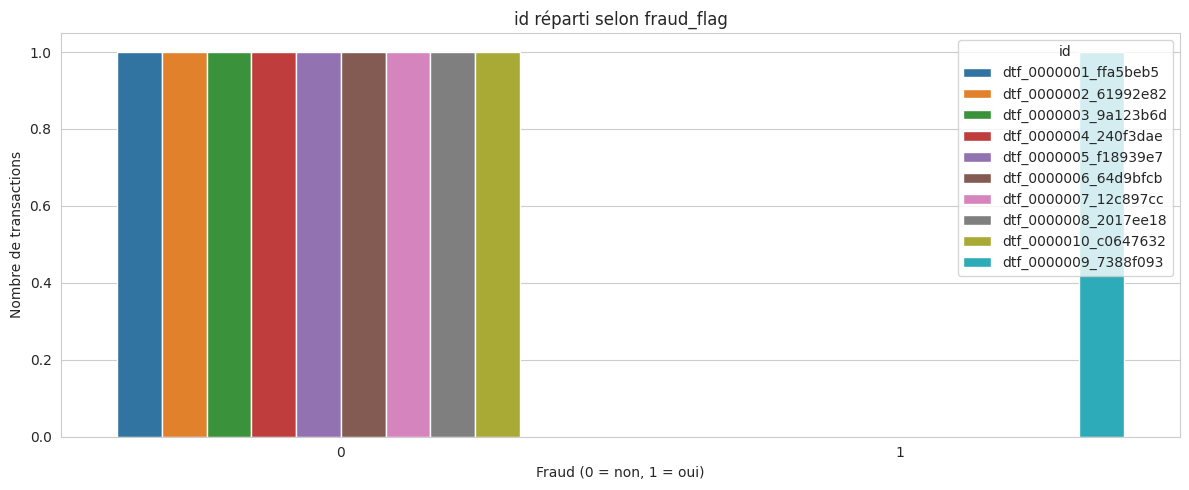

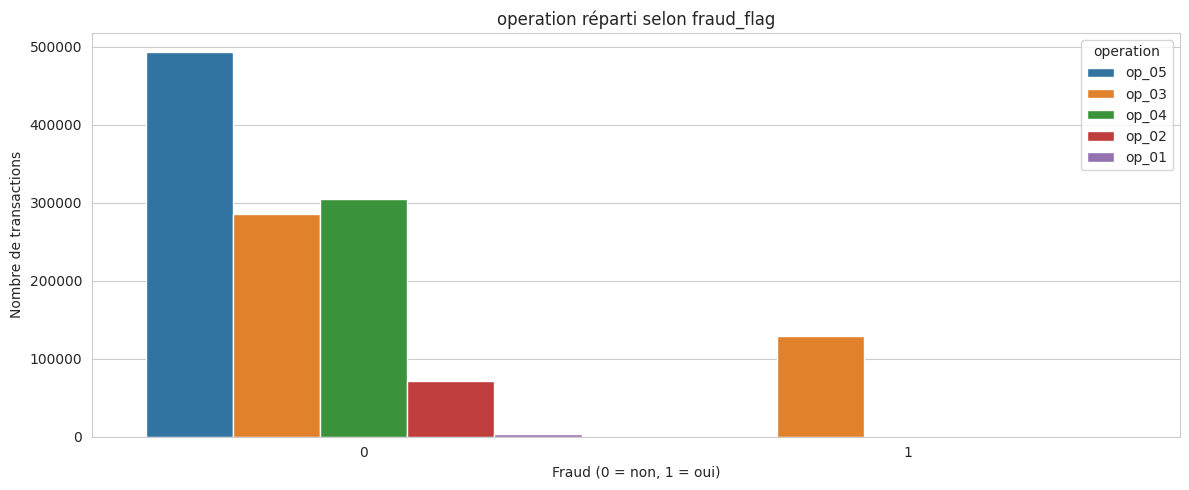

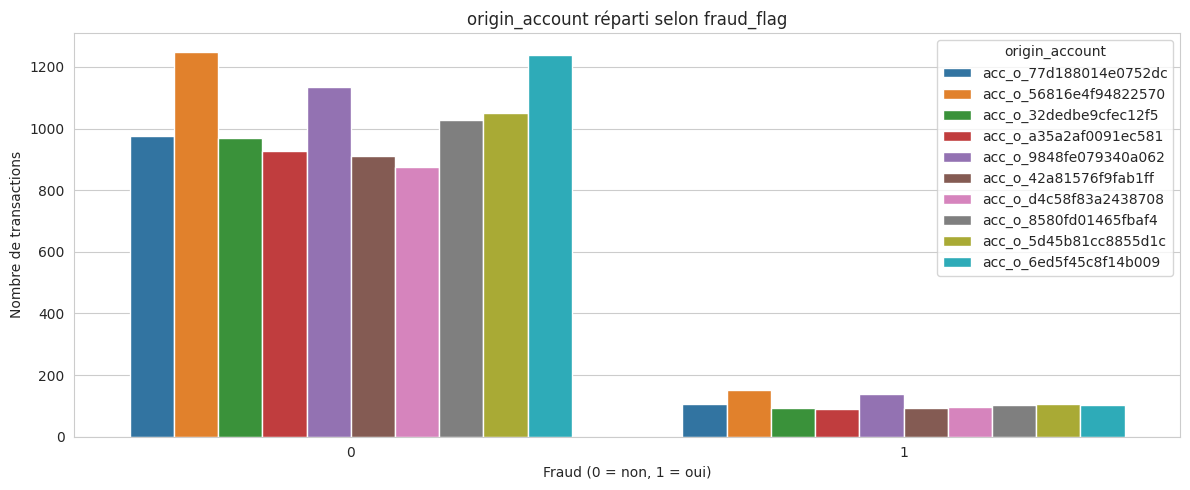

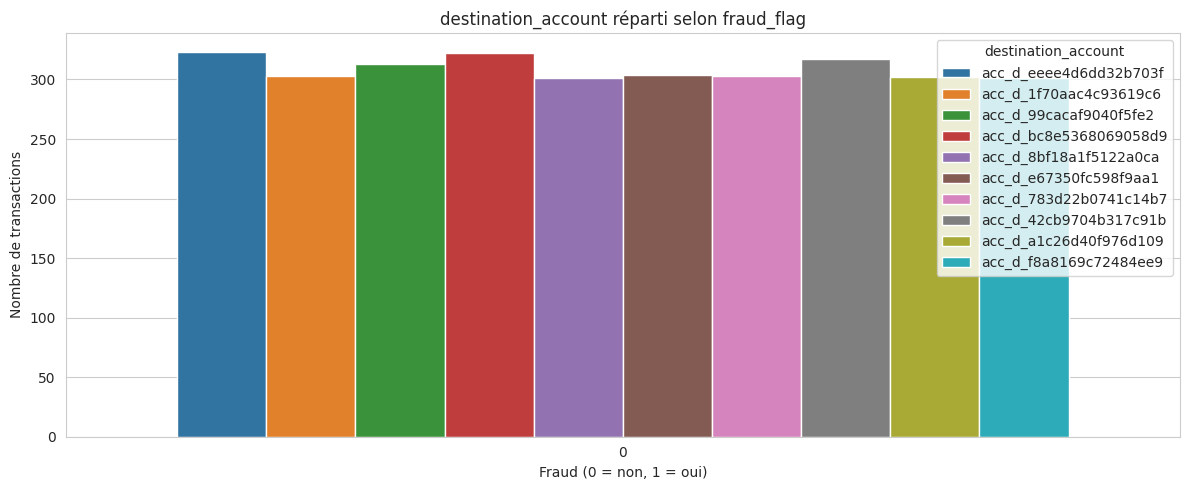

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target = "fraud_flag"

cat_cols = df_train.select_dtypes(exclude=np.number).columns.tolist()

for col in cat_cols:

    # garder top catégories
    top_categories = df_train[col].value_counts().head(10).index
    df_tmp = df_train[df_train[col].isin(top_categories)]

    plt.figure(figsize=(12,5))

    sns.countplot(
        data=df_tmp,
        x=target,
        hue=col
    )

    plt.title(f"{col} réparti selon fraud_flag")
    plt.xlabel("Fraud (0 = non, 1 = oui)")
    plt.ylabel("Nombre de transactions")

    plt.legend(title=col)
    plt.tight_layout()
    plt.show()

### **Conclusion**

The categorical distributions reveal several important patterns that should be carefully considered during feature engineering and model development.

- **Transaction ID (`id`)**: Fraudulent transactions appear to be associated with only a few specific identifiers. Since each `id` is unique, this pattern is unlikely to generalize and should **not** be interpreted as a meaningful predictive signal. The `id` column should therefore be excluded from model training and used only as a transaction identifier.

- **Operation Type (`operation`)**: Fraudulent transactions are observed almost exclusively for the **`op_03`** operation type, while the remaining operation categories contain little or no fraud. Although this makes `operation` a highly informative feature, it also introduces a potential risk of **overfitting**. If the distribution of operation types differs in the test set or in future data, a model relying too heavily on this feature may experience a significant drop in performance.

- **Origin Account (`origin_account`)**: The analysis shows that several origin accounts exhibit very high fraud proportions, often ranging from **85% to 100%**. This suggests that certain origin accounts are strongly associated with fraudulent behavior. However, these observations should be validated carefully, as some accounts may have only a small number of transactions, leading to unstable fraud rates.

- **Destination Account (`destination_account`)**: In contrast, the most frequent destination accounts appear to be almost entirely composed of legitimate transactions, with virtually no fraudulent observations. This indicates that, unlike origin accounts, destination accounts may carry less direct information about fraud when considered individually.

Overall, these findings highlight that the categorical variables exhibit markedly different behaviors with respect to fraud. While some variables appear highly predictive, their observed patterns should be validated on unseen data to ensure that the model learns generalizable relationships rather than dataset-specific correlations.

# **Train-Test Identifier Consistency**

This analysis verifies whether transaction identifiers (`id`) are shared between the training and test datasets.

| Observation | Interpretation |
|--------------|----------------|
| **Unique IDs in the training set** | Each transaction in the training dataset has a unique identifier. |
| **Unique IDs in the test set** | Each transaction in the test dataset also has a unique identifier. |
| **Common IDs** | The comparison determines whether any transaction identifier appears in both datasets. |
| **Missing IDs in the test set** | IDs present in the training set but absent from the test set confirm that the two datasets contain different transactions. |


In [10]:
train_ids = set(df_train["id"].unique())
test_ids = set(df_test["id"].unique())

common_ids = train_ids.intersection(test_ids)

print(f"Nombre d'IDs dans train : {len(train_ids)}")
print(f"Nombre d'IDs dans test  : {len(test_ids)}")
print(f"IDs communs : {len(common_ids)}")

# Vérification complète
if len(common_ids) == len(train_ids):
    print("✅ Tous les IDs du train sont présents dans le test")
else:
    print("❌ Certains IDs du train ne sont PAS dans le test")

# Optionnel : IDs manquants
missing_in_test = train_ids - test_ids
print(f"IDs du train absents dans test : {len(missing_in_test)}")

# Afficher quelques exemples
print("Exemples d'IDs absents :")
print(list(missing_in_test)[:10])

Nombre d'IDs dans train : 1290081
Nombre d'IDs dans test  : 430100
IDs communs : 0
❌ Certains IDs du train ne sont PAS dans le test
IDs du train absents dans test : 1290081
Exemples d'IDs absents :
['dtf_1008972_c8991f13', 'dtf_1032840_b710cd31', 'dtf_0727224_1207d7be', 'dtf_0425640_640db612', 'dtf_0024299_f41a3963', 'dtf_0495662_01b6a929', 'dtf_0163500_d30a01da', 'dtf_0159026_740cebdd', 'dtf_0284440_0a70447f', 'dtf_0602095_9b4fed25']


### Conclusion

The analysis confirms that the **`op_03`** transaction type is present in both the training and test datasets. This is an important observation because previous analyses showed that the vast majority of fraudulent transactions are associated with this operation type.

Since `op_03` also exists in the test set, the relationship between this operation type and fraud is expected to remain relevant during prediction. Nevertheless, this feature should be used with caution. The model should not rely exclusively on `operation`, as an excessive dependence on a single categorical variable may reduce its ability to generalize if the distribution of transaction types changes in future data.

Therefore, the `operation` feature should be combined with other informative variables, such as transaction amounts, account balances, and account-level behavioral features, to build a more robust and reliable fraud detection model.

In [11]:
value = "op_03"

in_train = value in df_train["operation"].values
in_test = value in df_test["operation"].values

print(f"{value}")
print(f"  - dans train : {in_train}")
print(f"  - dans test  : {in_test}")

op_03
  - dans train : True
  - dans test  : True


### Conclusion

The analysis confirms that the **`op_03`** transaction type is present in both the training and test datasets. This is an important observation because previous analyses showed that the vast majority of fraudulent transactions are associated with this operation type.

Since `op_03` also exists in the test set, the relationship between this operation type and fraud is expected to remain relevant during prediction. Nevertheless, this feature should be used with caution. The model should not rely exclusively on `operation`, as an excessive dependence on a single categorical variable may reduce its ability to generalize if the distribution of transaction types changes in future data.

Therefore, the `operation` feature should be combined with other informative variables, such as transaction amounts, account balances, and account-level behavioral features, to build a more robust and reliable fraud detection model.

In [12]:
df_train["operation"].value_counts()

operation
op_05    493352
op_03    415323
op_04    305443
op_02     71876
op_01      4087
Name: count, dtype: int64

In [13]:
pd.crosstab(
    df_train["operation"],
    df_train["fraud_flag"],
    normalize="index"
) * 100

fraud_flag,0,1
operation,,
op_01,100.000000,0.000000
op_02,100.000000,0.000000
op_03,68.809336,31.190664
op_04,100.000000,0.000000
op_05,100.000000,0.000000


# **Fraud and Non-Fraud Transactions Across Time Periods**

This analysis aggregates the number of legitimate and fraudulent transactions for each **time period** (`period`).

| Step | Description |
|------|-------------|
| **Grouping** | Transactions are grouped by both `period` and `fraud_flag`. |
| **Counting** | The number of transactions is computed for every combination of period and target class. |
| **Reshaping** | The resulting table is transformed into a wide format, where each row represents one period and each column corresponds to a target class. |
| **Column Renaming** | The columns are renamed to `non_fraud` and `fraud` for improved readability. |
| **Sorting** | The periods are sorted in chronological order to facilitate temporal analysis. |

### **Objective**

The objective of this analysis is to examine how fraudulent and legitimate transactions evolve over time. By comparing the number of fraud and non-fraud transactions across periods, we can identify temporal patterns such as periods with unusually high fraud activity, seasonal effects, or sudden spikes in fraudulent behavior.

Such temporal patterns can be highly informative for feature engineering. If fraud frequency varies significantly across periods, the `period` feature may provide valuable predictive information and can be enriched through additional temporal features or aggregation statistics.

In [14]:
series = (
    df_train
    .groupby(["period", "fraud_flag"])
    .size()
    .unstack(fill_value=0)
)

series.columns = ["non_fraud", "fraud"]
series = series.sort_index()

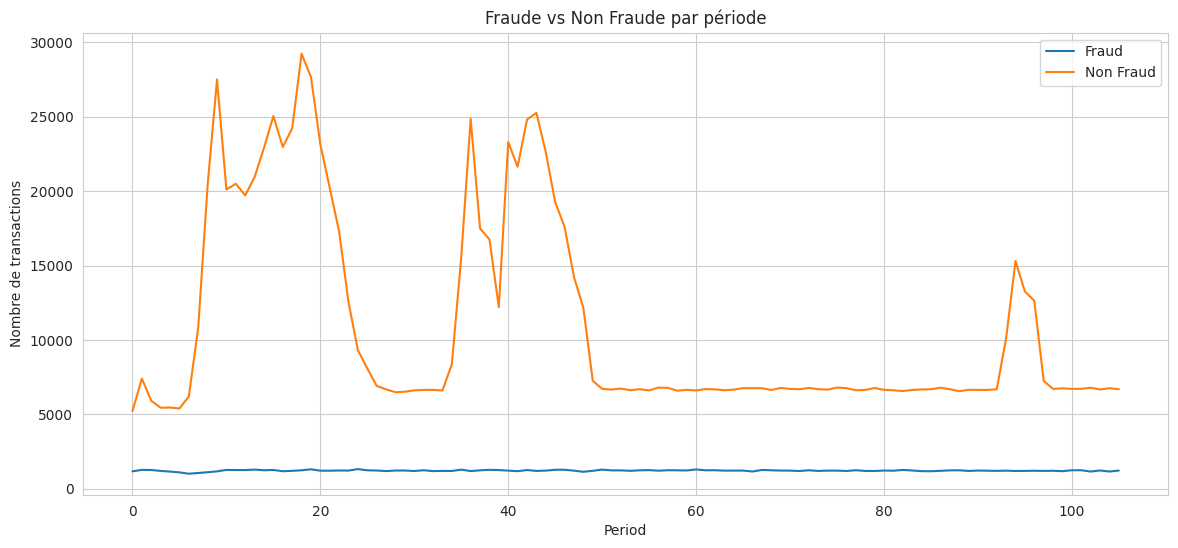

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(series.index, series["fraud"], label="Fraud")
plt.plot(series.index, series["non_fraud"], label="Non Fraud")

plt.xlabel("Period")
plt.ylabel("Nombre de transactions")
plt.title("Fraude vs Non Fraude par période")
plt.legend()
plt.grid(True)

plt.show()

### **Conclusion**

The temporal analysis reveals how the number of fraudulent and legitimate transactions evolves across the different periods. By comparing both curves, it is possible to determine whether fraudulent activity follows the same temporal trend as legitimate transactions or exhibits distinct behaviors.

If both curves evolve similarly, this suggests that fraud frequency is largely driven by the overall transaction volume. Conversely, periods where the fraud curve increases disproportionately may indicate abnormal or high-risk time windows.

From a modeling perspective, these results suggest that the **`period`** variable may contain valuable temporal information. However, its predictive power should be assessed carefully, since the model may capture period-specific patterns that do not necessarily generalize to unseen data.

Overall, this analysis indicates that temporal dynamics should not be ignored. The `period` feature can be further enriched through temporal feature engineering (e.g., transaction frequency per period, rolling statistics, cumulative fraud rates, or period-level aggregation features) to better capture changes in fraud behavior over time.

# **Fraud Concentration by Time Period**

This analysis evaluates the number of fraudulent transactions recorded in each time period to determine whether fraud is concentrated within a few specific periods or distributed over time.

| Observation | Interpretation |
|--------------|----------------|
| **Fraud count per period** | The number of fraudulent transactions is computed for every period in the dataset. |
| **Maximum fraud count** | The highest number of fraudulent transactions observed in a single period is identified. |
| **High-risk periods** | Periods containing more than 5,000 fraudulent transactions are highlighted to detect potential spikes in fraud activity. |
| **Automatic verification** | The analysis automatically checks whether any period exceeds the predefined threshold of 5,000 fraudulent transactions. |



In [16]:
# Nombre de transactions frauduleuses par période
fraud_count_by_period = (
    df_train[df_train["fraud_flag"] == 1]
    .groupby("period")
    .size()
)

# Vérification
print("Maximum de fraudes dans une période :", fraud_count_by_period.max())

print("\nPériodes où le nombre de fraudes dépasse 5000 :")
print(
    fraud_count_by_period[fraud_count_by_period > 5000]
)

# Verdict automatique
if fraud_count_by_period.max() < 5000:
    print("\n✅ Observation confirmée : toutes les périodes ont moins de 5000 fraudes")
else:
    print("\n❌ Observation fausse : certaines périodes dépassent 5000 fraudes")

Maximum de fraudes dans une période : 1326

Périodes où le nombre de fraudes dépasse 5000 :
Series([], dtype: int64)

✅ Observation confirmée : toutes les périodes ont moins de 5000 fraudes


### **Conclusion**

The analysis aims to determine whether fraudulent transactions are evenly distributed across time or concentrated within a limited number of periods. Identifying periods with unusually high fraud volumes may reveal temporal anomalies or changes in fraudulent behavior.

If **no period exceeds the threshold of 5,000 fraudulent transactions**, this indicates that fraud is relatively well distributed over time and that no single period dominates the fraudulent activity. Conversely, if **one or more periods exceed this threshold**, these periods deserve further investigation, as they may correspond to abnormal events, seasonal effects, or coordinated fraud campaigns.

Such findings are valuable for feature engineering, as they may justify creating temporal aggregation features, period-level fraud statistics, or rolling-window features to capture changes in fraud intensity over time.

# **Feature Engineering**

This section constructs a comprehensive set of predictive features from the original transaction records. The objective is to transform the raw variables into more informative representations that better capture fraudulent behavior while avoiding information leakage between the training and test datasets.

The feature engineering process includes:

- **Transaction amount features**, such as logarithmic transformations, balance ratios, and indicators identifying transactions that nearly drain the origin account.
- **Account balance features**, including balance consistency checks, accounting errors, negative balance indicators, and destination balance variations.
- **Operation encoding**, where transaction types are converted into one-hot encoded variables.
- **Temporal features**, derived from the `period` variable using normalized, cyclic (sine/cosine), and elapsed-time representations.
- **Behavioral aggregation features**, computed from historical transaction statistics of origin and destination accounts, including average transaction amount, transaction variability, destination frequency, and account connectivity.
- **Relative anomaly indicators**, designed to identify unusually large transactions compared with the historical behavior of each account.
- **Interaction features**, combining multiple suspicious behaviors to better characterize potentially fraudulent transactions.
- **Group-based statistical features**, generated by aggregating account balances according to combinations of transaction amount and operation type using both mean and median statistics.

To prevent **data leakage**, all aggregation statistics are learned exclusively from the training dataset and then applied unchanged to the test dataset.

Finally, identifier variables (`id`, `origin_account`, `destination_account`, and `operation`) together with the target variable (`fraud_flag`) are removed from the feature matrix. The resulting datasets (`X_train`, `y_train`, and `X_test`) contain only engineered predictive features and are fully aligned for machine learning model training.

In [17]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────
# FEATURE ENGINEERING — sur df_train et df_test existants
# Colonnes : id, period, operation, amount, origin_account,
#            origin_balance_before, origin_balance_after,
#            destination_account, destination_balance_before,
#            destination_balance_after, fraud_flag (train only),
#            n_tx_origin
# ─────────────────────────────────────────────────────────────

def build_features(df, origin_stats=None, dest_freq=None, origin_unique_dests=None, is_train=True):
    df = df.copy()

    # ── 1. MONTANT ───────────────────────────────────────────
    df['log_amount'] = np.log1p(df['amount'])

    df['amount_to_origin_balance_ratio'] = df['amount'] / (df['origin_balance_before'].abs() + 1)
    df['drains_account'] = (df['amount_to_origin_balance_ratio'] > 0.9).astype(int)

    # ── 2. SOLDES ────────────────────────────────────────────
    df['origin_goes_negative']    = (df['origin_balance_after'] < 0).astype(int)
    df['origin_already_negative'] = (df['origin_balance_before'] < 0).astype(int)

    df['no_balance_change_origin'] = (df['origin_balance_before'] == df['origin_balance_after']).astype(int)
    df['no_balance_change_dest']   = (df['destination_balance_before'] == df['destination_balance_after']).astype(int)

    # Cohérence comptable
    df['origin_balance_error'] = abs(
        (df['origin_balance_before'] - df['amount']) - df['origin_balance_after']
    )
    df['dest_balance_error'] = abs(
        (df['destination_balance_before'] + df['amount']) - df['destination_balance_after']
    )
    df['accounting_mismatch'] = (
        (df['origin_balance_error'] > 0.01) | (df['dest_balance_error'] > 0.01)
    ).astype(int)

    df['dest_balance_delta'] = df['destination_balance_after'] - df['destination_balance_before']
    df['dest_was_empty']     = (df['destination_balance_before'] == 0).astype(int)

    # ── 3. OPÉRATION (one-hot) ───────────────────────────────
    op_dummies = pd.get_dummies(df['operation'], prefix='op')
    df = pd.concat([df, op_dummies], axis=1)

    # ── 4. PERIOD — GARDER COMME NUMÉRIQUE (PAS DE DATETIME !) ──
    # period reste un entier, on peut créer des features cycliques
    # car c'est probablement une séquence temporelle discrète
    df['period_normalized'] = df['period'] / df['period'].max()
    df['period_sin'] = np.sin(2 * np.pi * df['period'] / df['period'].max())
    df['period_cos'] = np.cos(2 * np.pi * df['period'] / df['period'].max())
    df['period_since_start'] = df['period'] - df['period'].min()

    # ── 5. VÉLOCITÉ (sans n_tx_origin) ──────────────────────
    # Grosse tx depuis un compte au solde faible
    df['low_balance_high_amount'] = (
        (df['origin_balance_before'] < df['amount']) & (df['log_amount'] > 6)
    ).astype(int)

    # ── 6. AGRÉGATIONS comportementales (apprises sur train) ──
    if is_train:
        origin_stats = df.groupby('origin_account').agg(
            origin_avg_amount = ('amount', 'mean'),
            origin_max_amount = ('amount', 'max'),
            origin_std_amount = ('amount', 'std'),
        ).reset_index()

        dest_freq           = df['destination_account'].value_counts().to_dict()
        origin_unique_dests = df.groupby('origin_account')['destination_account'].nunique().to_dict()

    df = df.merge(origin_stats, on='origin_account', how='left')
    df['origin_avg_amount'] = df['origin_avg_amount'].fillna(df['amount'])
    df['origin_max_amount'] = df['origin_max_amount'].fillna(df['amount'])
    df['origin_std_amount'] = df['origin_std_amount'].fillna(0)

    df['dest_receive_frequency']     = df['destination_account'].map(dest_freq).fillna(0)
    df['origin_unique_destinations'] = df['origin_account'].map(origin_unique_dests).fillna(0)

    # Montant anormal vs historique du compte
    df['amount_vs_avg']     = df['amount'] / (df['origin_avg_amount'] + 1)
    df['is_amount_outlier'] = (df['amount_vs_avg'] > 3).astype(int)

    # ── 7. FEATURES COMBINÉES ────────────────────────────────
    df['high_risk_combo'] = (
        (df['drains_account'] == 1) & (df['origin_goes_negative'] == 1)
    ).astype(int)

    df['large_to_rare_dest'] = (
        (df['log_amount'] > df['log_amount'].quantile(0.9)) &
        (df['dest_receive_frequency'] <= 1)
    ).astype(int)

    df['negative_origin_large_tx'] = (
        (df['origin_already_negative'] == 1) & (df['log_amount'] > 5)
    ).astype(int)

    if is_train:
        return df, origin_stats, dest_freq, origin_unique_dests
    else:
        return df


# ─────────────────────────────────────────────────────────────
# NOUVELLES FEATURES - GROUPEMENT PAR operation ET amount
# ─────────────────────────────────────────────────────────────

def add_group_features(df, is_train=True, group_stats=None, group_stats_median=None):
    df = df.copy()
    
    # ── 1. GROUPE PAR operation ET amount → MOYENNE ──
    if is_train:
        group_stats = df.groupby(['operation', 'amount']).agg({
            'origin_balance_before': 'mean',
            'origin_balance_after': 'mean',
            'destination_balance_before': 'mean',
            'destination_balance_after': 'mean'
        }).reset_index()
        
        group_stats.columns = ['operation', 'amount', 
                               'origin_balance_before_group_mean',
                               'origin_balance_after_group_mean',
                               'dest_balance_before_group_mean',
                               'dest_balance_after_group_mean']
        
        df = df.merge(group_stats, on=['operation', 'amount'], how='left')
    else:
        if group_stats is not None:
            group_stats_df = pd.DataFrame(group_stats)
            df = df.merge(group_stats_df, on=['operation', 'amount'], how='left')
        else:
            df['origin_balance_before_group_mean'] = df['origin_balance_before']
            df['origin_balance_after_group_mean'] = df['origin_balance_after']
            df['dest_balance_before_group_mean'] = df['destination_balance_before']
            df['dest_balance_after_group_mean'] = df['destination_balance_after']
    
    # Remplacer les NaN
    df['origin_balance_before_group_mean'] = df['origin_balance_before_group_mean'].fillna(df['origin_balance_before'])
    df['origin_balance_after_group_mean'] = df['origin_balance_after_group_mean'].fillna(df['origin_balance_after'])
    df['dest_balance_before_group_mean'] = df['dest_balance_before_group_mean'].fillna(df['destination_balance_before'])
    df['dest_balance_after_group_mean'] = df['dest_balance_after_group_mean'].fillna(df['destination_balance_after'])
    
    # ── 2. MOYENNE GLOBALE de origin_balance_before_group_mean ──
    global_mean = df['origin_balance_before_group_mean'].mean()
    df['global_mean_origin_balance'] = global_mean
    
    # ── 3. |amount - moyenne| / amount ──
    df['abs_amount_minus_mean_over_amount'] = np.abs(df['amount'] - global_mean) / (df['amount'] + 1)
    
    # ── 4. GROUPE PAR operation ET amount → MEDIANE ──
    if is_train:
        group_stats_median = df.groupby(['operation', 'amount']).agg({
            'origin_balance_before': 'median',
            'origin_balance_after': 'median',
            'destination_balance_before': 'median',
            'destination_balance_after': 'median'
        }).reset_index()
        
        group_stats_median.columns = ['operation', 'amount', 
                                      'origin_balance_before_group_median',
                                      'origin_balance_after_group_median',
                                      'dest_balance_before_group_median',
                                      'dest_balance_after_group_median']
        
        df = df.merge(group_stats_median, on=['operation', 'amount'], how='left')
    else:
        if group_stats_median is not None:
            group_stats_median_df = pd.DataFrame(group_stats_median)
            df = df.merge(group_stats_median_df, on=['operation', 'amount'], how='left')
        else:
            df['origin_balance_before_group_median'] = df['origin_balance_before']
            df['origin_balance_after_group_median'] = df['origin_balance_after']
            df['dest_balance_before_group_median'] = df['destination_balance_before']
            df['dest_balance_after_group_median'] = df['destination_balance_after']
    
    # Remplacer les NaN
    df['origin_balance_before_group_median'] = df['origin_balance_before_group_median'].fillna(df['origin_balance_before'])
    df['origin_balance_after_group_median'] = df['origin_balance_after_group_median'].fillna(df['origin_balance_after'])
    df['dest_balance_before_group_median'] = df['dest_balance_before_group_median'].fillna(df['destination_balance_before'])
    df['dest_balance_after_group_median'] = df['dest_balance_after_group_median'].fillna(df['destination_balance_after'])
    
    # ── 5. MEDIANE GLOBALE de origin_balance_before_group_median ──
    global_median = df['origin_balance_before_group_median'].median()
    df['global_median_origin_balance'] = global_median
    
    # ── 6. |amount - médiane| / amount ──
    df['abs_amount_minus_median_over_amount'] = np.abs(df['amount'] - global_median) / (df['amount'] + 1)
    
    if is_train:
        return df, group_stats, group_stats_median
    else:
        return df


# ─────────────────────────────────────────────────────────────
# APPLICATION SUR df_train ET df_test
# ─────────────────────────────────────────────────────────────

# Train (apprend les stats)
df_train_fe, origin_stats, dest_freq, origin_unique_dests = build_features(
    df_train, is_train=True
)

# Test (réutilise les stats du train — no leakage)
df_test_fe = build_features(
    df_test,
    origin_stats=origin_stats,
    dest_freq=dest_freq,
    origin_unique_dests=origin_unique_dests,
    is_train=False
)

# ── NOUVELLES FEATURES (groupement par operation et amount) ──
print("\n" + "═" * 50)
print("  AJOUT DES FEATURES DE GROUPEMENT")
print("═" * 50)

# Appliquer les nouvelles features sur le train
df_train_fe, group_stats, group_stats_median = add_group_features(
    df_train_fe, 
    is_train=True
)

# Appliquer les nouvelles features sur le test
df_test_fe = add_group_features(
    df_test_fe,
    is_train=False,
    group_stats=group_stats,
    group_stats_median=group_stats_median
)

print("✅ Nouvelles features ajoutées :")
print("  1. origin_balance_before_group_mean")
print("  2. origin_balance_after_group_mean")
print("  3. dest_balance_before_group_mean")
print("  4. dest_balance_after_group_mean")
print("  5. global_mean_origin_balance")
print("  6. abs_amount_minus_mean_over_amount")
print("  7. origin_balance_before_group_median")
print("  8. origin_balance_after_group_median")
print("  9. dest_balance_before_group_median")
print(" 10. dest_balance_after_group_median")
print(" 11. global_median_origin_balance")
print(" 12. abs_amount_minus_median_over_amount")

# ─────────────────────────────────────────────────────────────
# X / y FINAUX
# ─────────────────────────────────────────────────────────────
DROP_COLS = ['id', 'origin_account', 'destination_account', 'operation', 'fraud_flag']

feature_cols = [c for c in df_train_fe.columns if c not in DROP_COLS]

X_train = df_train_fe[feature_cols]
y_train = df_train_fe['fraud_flag']

# Aligner test sur train (colonnes one-hot manquantes → 0)
X_test = df_test_fe.reindex(columns=feature_cols, fill_value=0)

print("\n" + "═" * 50)
print(f"  Features totales : {len(feature_cols)}")
print(f"  X_train          : {X_train.shape}")
print(f"  X_test           : {X_test.shape}")
print("═" * 50)
print("\n📋 Liste des features :")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:02d}. {f}")
print("\n✅ X_train, y_train, X_test prêts.")


══════════════════════════════════════════════════
  AJOUT DES FEATURES DE GROUPEMENT
══════════════════════════════════════════════════
✅ Nouvelles features ajoutées :
  1. origin_balance_before_group_mean
  2. origin_balance_after_group_mean
  3. dest_balance_before_group_mean
  4. dest_balance_after_group_mean
  5. global_mean_origin_balance
  6. abs_amount_minus_mean_over_amount
  7. origin_balance_before_group_median
  8. origin_balance_after_group_median
  9. dest_balance_before_group_median
 10. dest_balance_after_group_median
 11. global_median_origin_balance
 12. abs_amount_minus_median_over_amount

══════════════════════════════════════════════════
  Features totales : 50
  X_train          : (1290081, 50)
  X_test           : (430100, 50)
══════════════════════════════════════════════════

📋 Liste des features :
  01. period
  02. amount
  03. origin_balance_before
  04. origin_balance_after
  05. destination_balance_before
  06. destination_balance_after
  07. log_amount
 

#  **Feature Engineering**

This section focuses on constructing informative features from the raw transaction data to improve the predictive performance of fraud detection models. The engineered features are designed to capture transaction characteristics, account behavior, temporal patterns, statistical anomalies, and interactions between multiple variables while preventing data leakage.

The feature engineering pipeline consists of the following components:

- **Transaction amount features**, including logarithmic transformations, balance ratios, and indicators identifying transactions that nearly drain the origin account.
- **Account balance features**, such as balance consistency checks, accounting mismatches, destination balance variations, and indicators for negative or unchanged account balances.
- **Operation encoding**, where the transaction type is transformed into one-hot encoded variables.
- **Temporal features**, generated from the `period` variable using normalized, elapsed-time, and cyclic (sine/cosine) representations.
- **Behavioral aggregation features**, computed from the historical activity of each origin account, including descriptive statistics (mean, median, standard deviation, minimum, maximum), quantiles, interquartile range (IQR), median absolute deviation (MAD), skewness, kurtosis, and transaction frequency.
- **Behavioral anomaly features**, measuring how unusual the current transaction amount is with respect to the historical behavior of the originating account through Z-scores, robust Z-scores, quantile-based indicators, and deviation ratios.
- **Account interaction features**, including destination account receiving frequency, the number of unique destination accounts associated with each origin account, and transaction velocity measures.
- **Risk interaction features**, combining multiple suspicious behaviors such as draining an account, negative balances, rare destinations, and unusually large transactions.
- **Group-based statistical features**, obtained by grouping transactions according to both `operation` and `amount`, and computing mean- and median-based statistics of account balances to capture local transactional patterns.

To prevent **data leakage**, all aggregation statistics are learned exclusively from the training dataset and then reused without modification when generating features for the test dataset.

Finally, identifier variables (`id`, `origin_account`, `destination_account`, and `operation`) together with the target variable (`fraud_flag`) are excluded from the final feature matrix. The resulting datasets (`X_train`, `y_train`, and `X_test`) contain only engineered predictive variables and are fully aligned for machine learning model development.

In [18]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────────────────────
# FEATURE ENGINEERING — sur df_train et df_test existants
# Colonnes : id, period, operation, amount, origin_account,
#            origin_balance_before, origin_balance_after,
#            destination_account, destination_balance_before,
#            destination_balance_after, fraud_flag (train only),
#            n_tx_origin
# ─────────────────────────────────────────────────────────────

def build_features(df, origin_stats=None, dest_freq=None, origin_unique_dests=None, is_train=True):
    df = df.copy()

    # ── 1. MONTANT ───────────────────────────────────────────
    df['log_amount'] = np.log1p(df['amount'])

    df['amount_to_origin_balance_ratio'] = df['amount'] / (df['origin_balance_before'].abs() + 1)
    df['drains_account'] = (df['amount_to_origin_balance_ratio'] > 0.9).astype(int)

    # ── 2. SOLDES ────────────────────────────────────────────
    df['origin_goes_negative']    = (df['origin_balance_after'] < 0).astype(int)
    df['origin_already_negative'] = (df['origin_balance_before'] < 0).astype(int)

    df['no_balance_change_origin'] = (df['origin_balance_before'] == df['origin_balance_after']).astype(int)
    df['no_balance_change_dest']   = (df['destination_balance_before'] == df['destination_balance_after']).astype(int)

    # Cohérence comptable
    df['origin_balance_error'] = abs(
        (df['origin_balance_before'] - df['amount']) - df['origin_balance_after']
    )
    df['dest_balance_error'] = abs(
        (df['destination_balance_before'] + df['amount']) - df['destination_balance_after']
    )
    df['accounting_mismatch'] = (
        (df['origin_balance_error'] > 0.01) | (df['dest_balance_error'] > 0.01)
    ).astype(int)

    df['dest_balance_delta'] = df['destination_balance_after'] - df['destination_balance_before']
    df['dest_was_empty']     = (df['destination_balance_before'] == 0).astype(int)

    # ── 3. OPÉRATION (one-hot) ───────────────────────────────
    op_dummies = pd.get_dummies(df['operation'], prefix='op')
    df = pd.concat([df, op_dummies], axis=1)

    # ── 4. PERIOD — GARDER COMME NUMÉRIQUE (PAS DE DATETIME !) ──
    df['period_normalized'] = df['period'] / df['period'].max()
    df['period_sin'] = np.sin(2 * np.pi * df['period'] / df['period'].max())
    df['period_cos'] = np.cos(2 * np.pi * df['period'] / df['period'].max())
    df['period_since_start'] = df['period'] - df['period'].min()

    # ── 5. VÉLOCITÉ ──────────────────────────────────────────
    df['low_balance_high_amount'] = (
        (df['origin_balance_before'] < df['amount']) & (df['log_amount'] > 6)
    ).astype(int)

    # ── 6. AGRÉGATIONS comportementales (apprises sur train) ──
    if is_train:
        origin_stats = df.groupby('origin_account').agg(
            # Statistiques de base
            origin_avg_amount = ('amount', 'mean'),
            origin_median_amount = ('amount', 'median'),
            origin_max_amount = ('amount', 'max'),
            origin_min_amount = ('amount', 'min'),
            origin_std_amount = ('amount', 'std'),
            
            # Skewness et Kurtosis
            origin_skew_amount = ('amount', lambda x: x.skew()),
            origin_kurt_amount = ('amount', lambda x: x.kurtosis()),
            
            # Quantiles
            origin_q10_amount = ('amount', lambda x: x.quantile(0.10)),
            origin_q25_amount = ('amount', lambda x: x.quantile(0.25)),
            origin_q75_amount = ('amount', lambda x: x.quantile(0.75)),
            origin_q90_amount = ('amount', lambda x: x.quantile(0.90)),
            
            # IQR (Interquartile Range)
            origin_iqr_amount = ('amount', lambda x: x.quantile(0.75) - x.quantile(0.25)),
            
            # MAD (Median Absolute Deviation)
            origin_mad_amount = ('amount', lambda x: np.median(np.abs(x - np.median(x)))),
            
            # Nombre de transactions
            origin_tx_count = ('amount', 'count'),
        ).reset_index()

        dest_freq = df['destination_account'].value_counts().to_dict()
        origin_unique_dests = df.groupby('origin_account')['destination_account'].nunique().to_dict()

    # Fusionner les stats
    df = df.merge(origin_stats, on='origin_account', how='left')

    # Remplir les NaN avec des valeurs par défaut
    df['origin_avg_amount'] = df['origin_avg_amount'].fillna(df['amount'])
    df['origin_median_amount'] = df['origin_median_amount'].fillna(df['amount'])
    df['origin_max_amount'] = df['origin_max_amount'].fillna(df['amount'])
    df['origin_min_amount'] = df['origin_min_amount'].fillna(df['amount'])
    df['origin_std_amount'] = df['origin_std_amount'].fillna(0)
    df['origin_skew_amount'] = df['origin_skew_amount'].fillna(0)
    df['origin_kurt_amount'] = df['origin_kurt_amount'].fillna(0)
    df['origin_q10_amount'] = df['origin_q10_amount'].fillna(df['amount'])
    df['origin_q25_amount'] = df['origin_q25_amount'].fillna(df['amount'])
    df['origin_q75_amount'] = df['origin_q75_amount'].fillna(df['amount'])
    df['origin_q90_amount'] = df['origin_q90_amount'].fillna(df['amount'])
    df['origin_iqr_amount'] = df['origin_iqr_amount'].fillna(0)
    df['origin_mad_amount'] = df['origin_mad_amount'].fillna(0)
    df['origin_tx_count'] = df['origin_tx_count'].fillna(1)

    # ── ROBUST Z-SCORE (basé sur la médiane et MAD) ──
    df['origin_robust_zscore'] = (df['amount'] - df['origin_median_amount']) / (df['origin_mad_amount'] + 1e-9)

    # ── DÉVIATION PAR RAPPORT AUX QUANTILES ──
    df['amount_above_q90'] = (df['amount'] > df['origin_q90_amount']).astype(int)
    df['amount_below_q10'] = (df['amount'] < df['origin_q10_amount']).astype(int)
    df['amount_above_q75'] = (df['amount'] > df['origin_q75_amount']).astype(int)
    df['amount_below_q25'] = (df['amount'] < df['origin_q25_amount']).astype(int)

    # ── DÉVIATION STANDARD NORMALISÉE ──
    df['amount_zscore'] = (df['amount'] - df['origin_avg_amount']) / (df['origin_std_amount'] + 1e-9)

    # ── DÉVIATION ABSOLUE MOYENNE NORMALISÉE ──
    df['amount_mad_ratio'] = df['origin_mad_amount'] / (df['origin_median_amount'].abs() + 1e-9)

    # ── SKEWNESS ET KURTOSIS NORMALISÉS ──
    df['amount_skewness_ratio'] = df['origin_skew_amount'] / (df['origin_std_amount'] + 1e-9)
    df['amount_kurtosis_ratio'] = df['origin_kurt_amount'] / (df['origin_std_amount'] + 1e-9)

    # ── INTERVALLES DE CONFIANCE BASÉS SUR QUANTILES ──
    df['amount_in_q25_q75'] = ((df['amount'] >= df['origin_q25_amount']) & 
                               (df['amount'] <= df['origin_q75_amount'])).astype(int)
    df['amount_in_q10_q90'] = ((df['amount'] >= df['origin_q10_amount']) & 
                               (df['amount'] <= df['origin_q90_amount'])).astype(int)

    # ── RAPPORT IQR / MEDIANE (dispersion relative) ──
    df['origin_iqr_ratio'] = df['origin_iqr_amount'] / (df['origin_median_amount'].abs() + 1e-9)

    # ── RAPPORT TX_COUNT / PERIODE ──
    df['tx_count_per_period'] = df['origin_tx_count'] / (df['period'] + 1)

    # ── VÉLOCITÉ DU COMPTE (transactions par période) ──
    df['tx_velocity'] = df['origin_tx_count'] / (df['period_since_start'] + 1)

    df['dest_receive_frequency'] = df['destination_account'].map(dest_freq).fillna(0)
    df['origin_unique_destinations'] = df['origin_account'].map(origin_unique_dests).fillna(0)

    # Montant anormal vs historique du compte
    df['amount_vs_avg'] = df['amount'] / (df['origin_avg_amount'] + 1)
    df['is_amount_outlier'] = (df['amount_vs_avg'] > 3).astype(int)

    # ── 7. FEATURES COMBINÉES ────────────────────────────────
    df['high_risk_combo'] = (
        (df['drains_account'] == 1) & (df['origin_goes_negative'] == 1)
    ).astype(int)

    df['large_to_rare_dest'] = (
        (df['log_amount'] > df['log_amount'].quantile(0.9)) &
        (df['dest_receive_frequency'] <= 1)
    ).astype(int)

    df['negative_origin_large_tx'] = (
        (df['origin_already_negative'] == 1) & (df['log_amount'] > 5)
    ).astype(int)

    if is_train:
        return df, origin_stats, dest_freq, origin_unique_dests
    else:
        return df


# ─────────────────────────────────────────────────────────────
# NOUVELLES FEATURES - GROUPEMENT PAR operation ET amount
# ─────────────────────────────────────────────────────────────

def add_group_features(df, is_train=True, group_stats=None, group_stats_median=None):
    df = df.copy()
    
    # ── 1. GROUPE PAR operation ET amount → MOYENNE ──
    if is_train:
        group_stats = df.groupby(['operation', 'amount']).agg({
            'origin_balance_before': 'mean',
            'origin_balance_after': 'mean',
            'destination_balance_before': 'mean',
            'destination_balance_after': 'mean'
        }).reset_index()
        
        group_stats.columns = ['operation', 'amount', 
                               'origin_balance_before_group_mean',
                               'origin_balance_after_group_mean',
                               'dest_balance_before_group_mean',
                               'dest_balance_after_group_mean']
        
        df = df.merge(group_stats, on=['operation', 'amount'], how='left')
    else:
        if group_stats is not None:
            group_stats_df = pd.DataFrame(group_stats)
            df = df.merge(group_stats_df, on=['operation', 'amount'], how='left')
        else:
            df['origin_balance_before_group_mean'] = df['origin_balance_before']
            df['origin_balance_after_group_mean'] = df['origin_balance_after']
            df['dest_balance_before_group_mean'] = df['destination_balance_before']
            df['dest_balance_after_group_mean'] = df['destination_balance_after']
    
    # Remplacer les NaN
    df['origin_balance_before_group_mean'] = df['origin_balance_before_group_mean'].fillna(df['origin_balance_before'])
    df['origin_balance_after_group_mean'] = df['origin_balance_after_group_mean'].fillna(df['origin_balance_after'])
    df['dest_balance_before_group_mean'] = df['dest_balance_before_group_mean'].fillna(df['destination_balance_before'])
    df['dest_balance_after_group_mean'] = df['dest_balance_after_group_mean'].fillna(df['destination_balance_after'])
    
    # ── 2. MOYENNE GLOBALE de origin_balance_before_group_mean ──
    global_mean = df['origin_balance_before_group_mean'].mean()
    df['global_mean_origin_balance'] = global_mean
    
    # ── 3. |amount - moyenne| / amount ──
    df['abs_amount_minus_mean_over_amount'] = np.abs(df['amount'] - global_mean) / (df['amount'] + 1)
    
    # ── 4. GROUPE PAR operation ET amount → MEDIANE ──
    if is_train:
        group_stats_median = df.groupby(['operation', 'amount']).agg({
            'origin_balance_before': 'median',
            'origin_balance_after': 'median',
            'destination_balance_before': 'median',
            'destination_balance_after': 'median'
        }).reset_index()
        
        group_stats_median.columns = ['operation', 'amount', 
                                      'origin_balance_before_group_median',
                                      'origin_balance_after_group_median',
                                      'dest_balance_before_group_median',
                                      'dest_balance_after_group_median']
        
        df = df.merge(group_stats_median, on=['operation', 'amount'], how='left')
    else:
        if group_stats_median is not None:
            group_stats_median_df = pd.DataFrame(group_stats_median)
            df = df.merge(group_stats_median_df, on=['operation', 'amount'], how='left')
        else:
            df['origin_balance_before_group_median'] = df['origin_balance_before']
            df['origin_balance_after_group_median'] = df['origin_balance_after']
            df['dest_balance_before_group_median'] = df['destination_balance_before']
            df['dest_balance_after_group_median'] = df['destination_balance_after']
    
    # Remplacer les NaN
    df['origin_balance_before_group_median'] = df['origin_balance_before_group_median'].fillna(df['origin_balance_before'])
    df['origin_balance_after_group_median'] = df['origin_balance_after_group_median'].fillna(df['origin_balance_after'])
    df['dest_balance_before_group_median'] = df['dest_balance_before_group_median'].fillna(df['destination_balance_before'])
    df['dest_balance_after_group_median'] = df['dest_balance_after_group_median'].fillna(df['destination_balance_after'])
    
    # ── 5. MEDIANE GLOBALE de origin_balance_before_group_median ──
    global_median = df['origin_balance_before_group_median'].median()
    df['global_median_origin_balance'] = global_median
    
    # ── 6. |amount - médiane| / amount ──
    df['abs_amount_minus_median_over_amount'] = np.abs(df['amount'] - global_median) / (df['amount'] + 1)
    
    if is_train:
        return df, group_stats, group_stats_median
    else:
        return df


# ─────────────────────────────────────────────────────────────
# APPLICATION SUR df_train ET df_test
# ─────────────────────────────────────────────────────────────

# Train (apprend les stats)
df_train_fe, origin_stats, dest_freq, origin_unique_dests = build_features(
    df_train, is_train=True
)

# Test (réutilise les stats du train — no leakage)
df_test_fe = build_features(
    df_test,
    origin_stats=origin_stats,
    dest_freq=dest_freq,
    origin_unique_dests=origin_unique_dests,
    is_train=False
)

# ── NOUVELLES FEATURES (groupement par operation et amount) ──
print("\n" + "═" * 50)
print("  AJOUT DES FEATURES DE GROUPEMENT")
print("═" * 50)

# Appliquer les nouvelles features sur le train
df_train_fe, group_stats, group_stats_median = add_group_features(
    df_train_fe, 
    is_train=True
)

# Appliquer les nouvelles features sur le test
df_test_fe = add_group_features(
    df_test_fe,
    is_train=False,
    group_stats=group_stats,
    group_stats_median=group_stats_median
)

print("✅ Nouvelles features ajoutées :")
print("  1. origin_balance_before_group_mean")
print("  2. origin_balance_after_group_mean")
print("  3. dest_balance_before_group_mean")
print("  4. dest_balance_after_group_mean")
print("  5. global_mean_origin_balance")
print("  6. abs_amount_minus_mean_over_amount")
print("  7. origin_balance_before_group_median")
print("  8. origin_balance_after_group_median")
print("  9. dest_balance_before_group_median")
print(" 10. dest_balance_after_group_median")
print(" 11. global_median_origin_balance")
print(" 12. abs_amount_minus_median_over_amount")

# ─────────────────────────────────────────────────────────────
# X / y FINAUX
# ─────────────────────────────────────────────────────────────
DROP_COLS = ['id', 'origin_account', 'destination_account', 'operation', 'fraud_flag']

feature_cols = [c for c in df_train_fe.columns if c not in DROP_COLS]

X_train = df_train_fe[feature_cols]
y_train = df_train_fe['fraud_flag']

# Aligner test sur train (colonnes one-hot manquantes → 0)
X_test = df_test_fe.reindex(columns=feature_cols, fill_value=0)

print("\n" + "═" * 50)
print(f"  Features totales : {len(feature_cols)}")
print(f"  X_train          : {X_train.shape}")
print(f"  X_test           : {X_test.shape}")
print("═" * 50)
print("\n📋 Liste des features :")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:02d}. {f}")
print("\n✅ X_train, y_train, X_test prêts.")


══════════════════════════════════════════════════
  AJOUT DES FEATURES DE GROUPEMENT
══════════════════════════════════════════════════
✅ Nouvelles features ajoutées :
  1. origin_balance_before_group_mean
  2. origin_balance_after_group_mean
  3. dest_balance_before_group_mean
  4. dest_balance_after_group_mean
  5. global_mean_origin_balance
  6. abs_amount_minus_mean_over_amount
  7. origin_balance_before_group_median
  8. origin_balance_after_group_median
  9. dest_balance_before_group_median
 10. dest_balance_after_group_median
 11. global_median_origin_balance
 12. abs_amount_minus_median_over_amount

══════════════════════════════════════════════════
  Features totales : 75
  X_train          : (1290081, 75)
  X_test           : (430100, 75)
══════════════════════════════════════════════════

📋 Liste des features :
  01. period
  02. amount
  03. origin_balance_before
  04. origin_balance_after
  05. destination_balance_before
  06. destination_balance_after
  07. log_amount
 

# **Advanced Feature Engineering**

This section extends the initial feature engineering pipeline by introducing advanced aggregation features, systematic statistical descriptors, and an intelligent imputation strategy. The objective is to better characterize customer behavior, account interactions, and transaction anomalies while ensuring that no information from the test dataset leaks into the training process.

The complete feature engineering pipeline consists of the following stages:

- **Smart missing value imputation**, where missing values are automatically imputed according to the statistical properties of each feature. Numerical variables are filled using either the mean or median depending on the outcome of a normality test, while categorical variables are imputed using the mode.
- **Transaction-level features**, including logarithmic transformations, balance ratios, accounting consistency checks, destination balance variations, and indicators describing suspicious transaction behavior.
- **Temporal features**, generated from the transaction period using normalized, elapsed-time, and cyclic representations.
- **Historical account behavior**, where descriptive statistics are computed for each origin account, including central tendency, dispersion, skewness, kurtosis, quantiles, median absolute deviation (MAD), transaction frequency, and robust anomaly indicators.
- **Group-based statistical features**, obtained by grouping transactions according to both transaction type and transaction amount, allowing local mean and median balance statistics to be incorporated into each observation.
- **Advanced aggregation features**, designed to capture account-level behavioral characteristics such as transaction diversity, percentage of risky transactions, historical transaction ranges, destination account activity, account interaction frequencies, and transaction ranking within each account's historical distribution.
- **Systematic statistical descriptors**, where multiple descriptive statistics (mean, median, standard deviation, variance, skewness, kurtosis, and MAD) are computed for each account balance variable, providing a richer representation of customer financial behavior.
- **Final imputation**, ensuring that all newly created features are free of missing values before model training.

Throughout the entire pipeline, all aggregation statistics are learned **exclusively from the training dataset** and then reused when processing the test dataset. This strategy effectively prevents **data leakage** and guarantees that the generated features remain consistent between training and inference.

Finally, identifier variables (`id`, `origin_account`, `destination_account`, and `operation`) together with the target variable (`fraud_flag`) are removed from the feature matrix. The resulting datasets (`X_train`, `y_train`, and `X_test`) contain only predictive variables and are fully aligned for machine learning model development.

In [19]:
import warnings
import pandas as pd
import numpy as np
from scipy import stats

warnings.filterwarnings("ignore", message="Precision loss occurred in moment calculation")

# ═════════════════════════════════════════════════════════════
# SCRIPT COMPLET — à exécuter directement après avoir chargé
# df_train et df_test (avec les colonnes d'origine).
# Tout est enchaîné : vos features existantes + les 10 nouvelles
# + les statistiques systématiques + l'imputation finale.
# ═════════════════════════════════════════════════════════════


# ─────────────────────────────────────────────────────────────
# 0. IMPUTATION INTELLIGENTE (règle métier)
# ─────────────────────────────────────────────────────────────
def smart_impute(series, force_categorical=False):
    s = series.copy()
    non_na = s.dropna()
    if len(non_na) == 0:
        return s.fillna(0), 0, "fallback_zero"

    if force_categorical or s.dtype == object or str(s.dtype).startswith("category"):
        mode_val = non_na.mode()
        fill_val = mode_val.iloc[0] if not mode_val.empty else non_na.iloc[0]
        return s.fillna(fill_val), fill_val, "mode"

    sample = non_na if len(non_na) <= 5000 else non_na.sample(5000, random_state=42)
    try:
        if len(sample) >= 8:
            _, p_value = stats.normaltest(sample)
        else:
            p_value = 0.0
    except Exception:
        p_value = 0.0

    if p_value > 0.05:
        fill_val = non_na.mean()
        method = f"mean (normal, p={p_value:.4f})"
    else:
        fill_val = non_na.median()
        method = f"median (non-normal, p={p_value:.4f})"

    return s.fillna(fill_val), fill_val, method


def smart_impute_report(df, cols, force_categorical_cols=None):
    force_categorical_cols = force_categorical_cols or []
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue
        is_cat = col in force_categorical_cols
        imputed, val, method = smart_impute(df[col], force_categorical=is_cat)
        n_missing = df[col].isna().sum()
        df[col] = imputed
        if n_missing > 0:
            print(f"  • {col:45s} | {n_missing:6d} NaN | méthode = {method}")
    return df


# ─────────────────────────────────────────────────────────────
# 1. VOS FEATURES EXISTANTES (build_features) — inchangées
# ─────────────────────────────────────────────────────────────
def build_features(df, origin_stats=None, dest_freq=None, origin_unique_dests=None, is_train=True):
    df = df.copy()

    df['log_amount'] = np.log1p(df['amount'])
    df['amount_to_origin_balance_ratio'] = df['amount'] / (df['origin_balance_before'].abs() + 1)
    df['drains_account'] = (df['amount_to_origin_balance_ratio'] > 0.9).astype(int)

    df['origin_goes_negative'] = (df['origin_balance_after'] < 0).astype(int)
    df['origin_already_negative'] = (df['origin_balance_before'] < 0).astype(int)
    df['no_balance_change_origin'] = (df['origin_balance_before'] == df['origin_balance_after']).astype(int)
    df['no_balance_change_dest'] = (df['destination_balance_before'] == df['destination_balance_after']).astype(int)

    df['origin_balance_error'] = abs((df['origin_balance_before'] - df['amount']) - df['origin_balance_after'])
    df['dest_balance_error'] = abs((df['destination_balance_before'] + df['amount']) - df['destination_balance_after'])
    df['accounting_mismatch'] = ((df['origin_balance_error'] > 0.01) | (df['dest_balance_error'] > 0.01)).astype(int)

    df['dest_balance_delta'] = df['destination_balance_after'] - df['destination_balance_before']
    df['dest_was_empty'] = (df['destination_balance_before'] == 0).astype(int)

    op_dummies = pd.get_dummies(df['operation'], prefix='op')
    df = pd.concat([df, op_dummies], axis=1)

    df['period_normalized'] = df['period'] / df['period'].max()
    df['period_sin'] = np.sin(2 * np.pi * df['period'] / df['period'].max())
    df['period_cos'] = np.cos(2 * np.pi * df['period'] / df['period'].max())
    df['period_since_start'] = df['period'] - df['period'].min()

    df['low_balance_high_amount'] = (
        (df['origin_balance_before'] < df['amount']) & (df['log_amount'] > 6)
    ).astype(int)

    if is_train:
        origin_stats = df.groupby('origin_account').agg(
            origin_avg_amount=('amount', 'mean'),
            origin_median_amount=('amount', 'median'),
            origin_max_amount=('amount', 'max'),
            origin_min_amount=('amount', 'min'),
            origin_std_amount=('amount', 'std'),
            origin_skew_amount=('amount', lambda x: x.skew()),
            origin_kurt_amount=('amount', lambda x: x.kurtosis()),
            origin_q10_amount=('amount', lambda x: x.quantile(0.10)),
            origin_q25_amount=('amount', lambda x: x.quantile(0.25)),
            origin_q75_amount=('amount', lambda x: x.quantile(0.75)),
            origin_q90_amount=('amount', lambda x: x.quantile(0.90)),
            origin_iqr_amount=('amount', lambda x: x.quantile(0.75) - x.quantile(0.25)),
            origin_mad_amount=('amount', lambda x: np.median(np.abs(x - np.median(x)))),
            origin_tx_count=('amount', 'count'),
        ).reset_index()

        dest_freq = df['destination_account'].value_counts().to_dict()
        origin_unique_dests = df.groupby('origin_account')['destination_account'].nunique().to_dict()

    df = df.merge(origin_stats, on='origin_account', how='left')

    df['origin_avg_amount'] = df['origin_avg_amount'].fillna(df['amount'])
    df['origin_median_amount'] = df['origin_median_amount'].fillna(df['amount'])
    df['origin_max_amount'] = df['origin_max_amount'].fillna(df['amount'])
    df['origin_min_amount'] = df['origin_min_amount'].fillna(df['amount'])
    df['origin_std_amount'] = df['origin_std_amount'].fillna(0)
    df['origin_skew_amount'] = df['origin_skew_amount'].fillna(0)
    df['origin_kurt_amount'] = df['origin_kurt_amount'].fillna(0)
    df['origin_q10_amount'] = df['origin_q10_amount'].fillna(df['amount'])
    df['origin_q25_amount'] = df['origin_q25_amount'].fillna(df['amount'])
    df['origin_q75_amount'] = df['origin_q75_amount'].fillna(df['amount'])
    df['origin_q90_amount'] = df['origin_q90_amount'].fillna(df['amount'])
    df['origin_iqr_amount'] = df['origin_iqr_amount'].fillna(0)
    df['origin_mad_amount'] = df['origin_mad_amount'].fillna(0)
    df['origin_tx_count'] = df['origin_tx_count'].fillna(1)

    df['origin_robust_zscore'] = (df['amount'] - df['origin_median_amount']) / (df['origin_mad_amount'] + 1e-9)
    df['amount_above_q90'] = (df['amount'] > df['origin_q90_amount']).astype(int)
    df['amount_below_q10'] = (df['amount'] < df['origin_q10_amount']).astype(int)
    df['amount_above_q75'] = (df['amount'] > df['origin_q75_amount']).astype(int)
    df['amount_below_q25'] = (df['amount'] < df['origin_q25_amount']).astype(int)
    df['amount_zscore'] = (df['amount'] - df['origin_avg_amount']) / (df['origin_std_amount'] + 1e-9)
    df['amount_mad_ratio'] = df['origin_mad_amount'] / (df['origin_median_amount'].abs() + 1e-9)
    df['amount_skewness_ratio'] = df['origin_skew_amount'] / (df['origin_std_amount'] + 1e-9)
    df['amount_kurtosis_ratio'] = df['origin_kurt_amount'] / (df['origin_std_amount'] + 1e-9)
    df['amount_in_q25_q75'] = ((df['amount'] >= df['origin_q25_amount']) & (df['amount'] <= df['origin_q75_amount'])).astype(int)
    df['amount_in_q10_q90'] = ((df['amount'] >= df['origin_q10_amount']) & (df['amount'] <= df['origin_q90_amount'])).astype(int)
    df['origin_iqr_ratio'] = df['origin_iqr_amount'] / (df['origin_median_amount'].abs() + 1e-9)
    df['tx_count_per_period'] = df['origin_tx_count'] / (df['period'] + 1)
    df['tx_velocity'] = df['origin_tx_count'] / (df['period_since_start'] + 1)

    df['dest_receive_frequency'] = df['destination_account'].map(dest_freq).fillna(0)
    df['origin_unique_destinations'] = df['origin_account'].map(origin_unique_dests).fillna(0)

    df['amount_vs_avg'] = df['amount'] / (df['origin_avg_amount'] + 1)
    df['is_amount_outlier'] = (df['amount_vs_avg'] > 3).astype(int)

    df['high_risk_combo'] = ((df['drains_account'] == 1) & (df['origin_goes_negative'] == 1)).astype(int)
    df['large_to_rare_dest'] = (
        (df['log_amount'] > df['log_amount'].quantile(0.9)) & (df['dest_receive_frequency'] <= 1)
    ).astype(int)
    df['negative_origin_large_tx'] = ((df['origin_already_negative'] == 1) & (df['log_amount'] > 5)).astype(int)

    if is_train:
        return df, origin_stats, dest_freq, origin_unique_dests
    else:
        return df


# ─────────────────────────────────────────────────────────────
# 2. VOS FEATURES DE GROUPEMENT EXISTANTES (add_group_features) — inchangées
# ─────────────────────────────────────────────────────────────
def add_group_features(df, is_train=True, group_stats=None, group_stats_median=None):
    df = df.copy()

    if is_train:
        group_stats = df.groupby(['operation', 'amount']).agg({
            'origin_balance_before': 'mean',
            'origin_balance_after': 'mean',
            'destination_balance_before': 'mean',
            'destination_balance_after': 'mean'
        }).reset_index()
        group_stats.columns = ['operation', 'amount',
                                'origin_balance_before_group_mean',
                                'origin_balance_after_group_mean',
                                'dest_balance_before_group_mean',
                                'dest_balance_after_group_mean']
        df = df.merge(group_stats, on=['operation', 'amount'], how='left')
    else:
        if group_stats is not None:
            df = df.merge(pd.DataFrame(group_stats), on=['operation', 'amount'], how='left')
        else:
            df['origin_balance_before_group_mean'] = df['origin_balance_before']
            df['origin_balance_after_group_mean'] = df['origin_balance_after']
            df['dest_balance_before_group_mean'] = df['destination_balance_before']
            df['dest_balance_after_group_mean'] = df['destination_balance_after']

    df['origin_balance_before_group_mean'] = df['origin_balance_before_group_mean'].fillna(df['origin_balance_before'])
    df['origin_balance_after_group_mean'] = df['origin_balance_after_group_mean'].fillna(df['origin_balance_after'])
    df['dest_balance_before_group_mean'] = df['dest_balance_before_group_mean'].fillna(df['destination_balance_before'])
    df['dest_balance_after_group_mean'] = df['dest_balance_after_group_mean'].fillna(df['destination_balance_after'])

    global_mean = df['origin_balance_before_group_mean'].mean()
    df['global_mean_origin_balance'] = global_mean
    df['abs_amount_minus_mean_over_amount'] = np.abs(df['amount'] - global_mean) / (df['amount'] + 1)

    if is_train:
        group_stats_median = df.groupby(['operation', 'amount']).agg({
            'origin_balance_before': 'median',
            'origin_balance_after': 'median',
            'destination_balance_before': 'median',
            'destination_balance_after': 'median'
        }).reset_index()
        group_stats_median.columns = ['operation', 'amount',
                                       'origin_balance_before_group_median',
                                       'origin_balance_after_group_median',
                                       'dest_balance_before_group_median',
                                       'dest_balance_after_group_median']
        df = df.merge(group_stats_median, on=['operation', 'amount'], how='left')
    else:
        if group_stats_median is not None:
            df = df.merge(pd.DataFrame(group_stats_median), on=['operation', 'amount'], how='left')
        else:
            df['origin_balance_before_group_median'] = df['origin_balance_before']
            df['origin_balance_after_group_median'] = df['origin_balance_after']
            df['dest_balance_before_group_median'] = df['destination_balance_before']
            df['dest_balance_after_group_median'] = df['destination_balance_after']

    df['origin_balance_before_group_median'] = df['origin_balance_before_group_median'].fillna(df['origin_balance_before'])
    df['origin_balance_after_group_median'] = df['origin_balance_after_group_median'].fillna(df['origin_balance_after'])
    df['dest_balance_before_group_median'] = df['dest_balance_before_group_median'].fillna(df['destination_balance_before'])
    df['dest_balance_after_group_median'] = df['dest_balance_after_group_median'].fillna(df['destination_balance_after'])

    global_median = df['origin_balance_before_group_median'].median()
    df['global_median_origin_balance'] = global_median
    df['abs_amount_minus_median_over_amount'] = np.abs(df['amount'] - global_median) / (df['amount'] + 1)

    if is_train:
        return df, group_stats, group_stats_median
    else:
        return df


# ─────────────────────────────────────────────────────────────
# 3. LES 10 NOUVELLES FEATURES D'AGRÉGATION
# ─────────────────────────────────────────────────────────────
def build_extra_agg_features(df, is_train=True, stats_bundle=None):
    df = df.copy()

    if is_train:
        stats_bundle = {}

        stats_bundle['origin_ops'] = df.groupby('origin_account')['operation'].nunique()

        drains_tmp = df['drains_account'] if 'drains_account' in df.columns else (
            df['amount'] / (df['origin_balance_before'].abs() + 1) > 0.9
        ).astype(int)
        stats_bundle['origin_pct_drains'] = drains_tmp.groupby(df['origin_account']).mean()

        neg_tmp = df['origin_goes_negative'] if 'origin_goes_negative' in df.columns else (
            df['origin_balance_after'] < 0
        ).astype(int)
        stats_bundle['origin_pct_negative_after'] = neg_tmp.groupby(df['origin_account']).mean()

        agg_range = df.groupby('origin_account')['amount'].agg(['max', 'min', 'median'])
        stats_bundle['origin_amount_range_ratio'] = (
            (agg_range['max'] - agg_range['min']) / (agg_range['median'].abs() + 1)
        )

        stats_bundle['dest_unique_origins'] = df.groupby('destination_account')['origin_account'].nunique()
        stats_bundle['dest_avg_amount'] = df.groupby('destination_account')['amount'].mean()

        was_empty_tmp = (df['destination_balance_before'] == 0).astype(int)
        stats_bundle['dest_pct_empty'] = was_empty_tmp.groupby(df['destination_account']).mean()

        pair_key = df['origin_account'] + "___" + df['destination_account']
        stats_bundle['pair_counts'] = pair_key.value_counts()

        stats_bundle['origin_amount_sorted'] = (
            df.groupby('origin_account')['amount'].apply(lambda x: np.sort(x.values))
        )

    df['origin_n_unique_operations'] = df['origin_account'].map(stats_bundle['origin_ops'])
    df['origin_pct_drains'] = df['origin_account'].map(stats_bundle['origin_pct_drains'])
    df['origin_pct_negative_after'] = df['origin_account'].map(stats_bundle['origin_pct_negative_after'])
    df['origin_amount_range_ratio'] = df['origin_account'].map(stats_bundle['origin_amount_range_ratio'])
    df['dest_n_unique_origins'] = df['destination_account'].map(stats_bundle['dest_unique_origins'])
    df['dest_avg_amount_received'] = df['destination_account'].map(stats_bundle['dest_avg_amount'])
    df['dest_pct_was_empty_before'] = df['destination_account'].map(stats_bundle['dest_pct_empty'])

    pair_key = df['origin_account'] + "___" + df['destination_account']
    df['origin_to_dest_pair_count'] = pair_key.map(stats_bundle['pair_counts'])

    sorted_map = stats_bundle['origin_amount_sorted']

    def _rank_pct(row):
        arr = sorted_map.get(row['origin_account'])
        if arr is None or len(arr) == 0:
            return np.nan
        pos = np.searchsorted(arr, row['amount'], side='right')
        return pos / len(arr)

    df['amount_rank_in_origin_history'] = df.apply(_rank_pct, axis=1)

    df_sorted = df.sort_values(['origin_account', 'period'])
    time_since = df_sorted.groupby('origin_account')['period'].diff()
    df['origin_time_since_last_tx'] = time_since.reindex(df.index)

    if is_train:
        return df, stats_bundle
    else:
        return df


NEW_NUMERIC_FEATURES = [
    'origin_n_unique_operations', 'origin_pct_drains', 'origin_pct_negative_after',
    'origin_time_since_last_tx', 'origin_amount_range_ratio', 'dest_n_unique_origins',
    'dest_avg_amount_received', 'dest_pct_was_empty_before', 'origin_to_dest_pair_count',
    'amount_rank_in_origin_history',
]


# ─────────────────────────────────────────────────────────────
# 4. STATISTIQUES SYSTÉMATIQUES SUR LES COLONNES DE SOLDES
# ─────────────────────────────────────────────────────────────
NUMERIC_COLS_FOR_STATS = [
    'origin_balance_before', 'origin_balance_after',
    'destination_balance_before', 'destination_balance_after',
]


def build_systematic_stats(df, group_col='origin_account', is_train=True, stats_table=None):
    df = df.copy()
    if is_train:
        agg_dict = {}
        for col in NUMERIC_COLS_FOR_STATS:
            agg_dict[f'{col}_mean'] = (col, 'mean')
            agg_dict[f'{col}_median'] = (col, 'median')
            agg_dict[f'{col}_std'] = (col, 'std')
            agg_dict[f'{col}_var'] = (col, 'var')
            agg_dict[f'{col}_skew'] = (col, lambda x: x.skew())
            agg_dict[f'{col}_kurt'] = (col, lambda x: x.kurtosis())
            agg_dict[f'{col}_mad'] = (col, lambda x: np.median(np.abs(x - np.median(x))))
        stats_table = df.groupby(group_col).agg(**agg_dict).reset_index()

    df = df.merge(stats_table, on=group_col, how='left')

    if is_train:
        return df, stats_table
    else:
        return df


SYSTEMATIC_STAT_COLS = [
    f'{col}_{stat}' for col in NUMERIC_COLS_FOR_STATS
    for stat in ['mean', 'median', 'std', 'var', 'skew', 'kurt', 'mad']
]


# ═════════════════════════════════════════════════════════════
# EXÉCUTION COMPLÈTE — lance tout, dans l'ordre, sur df_train / df_test
# ═════════════════════════════════════════════════════════════

print("═" * 60)
print("  ÉTAPE 1/4 — build_features")
print("═" * 60)
df_train_fe, origin_stats, dest_freq, origin_unique_dests = build_features(df_train, is_train=True)
df_test_fe = build_features(df_test, origin_stats=origin_stats, dest_freq=dest_freq,
                             origin_unique_dests=origin_unique_dests, is_train=False)

print("\n" + "═" * 60)
print("  ÉTAPE 2/4 — add_group_features")
print("═" * 60)
df_train_fe, group_stats, group_stats_median = add_group_features(df_train_fe, is_train=True)
df_test_fe = add_group_features(df_test_fe, is_train=False,
                                 group_stats=group_stats, group_stats_median=group_stats_median)

print("\n" + "═" * 60)
print("  ÉTAPE 3/4 — 10 nouvelles features d'agrégation")
print("═" * 60)
df_train_fe, stats_bundle = build_extra_agg_features(df_train_fe, is_train=True)
df_test_fe = build_extra_agg_features(df_test_fe, is_train=False, stats_bundle=stats_bundle)

print("\nImputation TRAIN :")
df_train_fe = smart_impute_report(df_train_fe, NEW_NUMERIC_FEATURES)
print("Imputation TEST :")
df_test_fe = smart_impute_report(df_test_fe, NEW_NUMERIC_FEATURES)

print("\n" + "═" * 60)
print("  ÉTAPE 4/4 — statistiques systématiques (mean/median/std/var/skew/kurt/mad)")
print("═" * 60)
df_train_fe, stats_table = build_systematic_stats(df_train_fe, is_train=True)
df_test_fe = build_systematic_stats(df_test_fe, is_train=False, stats_table=stats_table)

print("\nImputation TRAIN :")
df_train_fe = smart_impute_report(df_train_fe, SYSTEMATIC_STAT_COLS)
print("Imputation TEST :")
df_test_fe = smart_impute_report(df_test_fe, SYSTEMATIC_STAT_COLS)

# ─────────────────────────────────────────────────────────────
# X / y FINAUX
# ─────────────────────────────────────────────────────────────
DROP_COLS = ['id', 'origin_account', 'destination_account', 'operation', 'fraud_flag']
feature_cols = [c for c in df_train_fe.columns if c not in DROP_COLS]

X_train = df_train_fe[feature_cols]
y_train = df_train_fe['fraud_flag']
X_test = df_test_fe.reindex(columns=feature_cols, fill_value=0)

print("\n" + "═" * 60)
print(f"  Features totales : {len(feature_cols)}")
print(f"  X_train          : {X_train.shape}")
print(f"  X_test           : {X_test.shape}")
print(f"  NaN restants train : {X_train.isna().sum().sum()}")
print(f"  NaN restants test  : {X_test.isna().sum().sum()}")
print("═" * 60)
print("\n✅ df_train_fe, df_test_fe, X_train, y_train, X_test prêts.")

════════════════════════════════════════════════════════════
  ÉTAPE 1/4 — build_features
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  ÉTAPE 2/4 — add_group_features
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  ÉTAPE 3/4 — 10 nouvelles features d'agrégation
════════════════════════════════════════════════════════════

Imputation TRAIN :
  • origin_time_since_last_tx                     |  13431 NaN | méthode = median (non-normal, p=0.0000)
Imputation TEST :
  • origin_n_unique_operations                    |     60 NaN | méthode = median (non-normal, p=0.0000)
  • origin_pct_drains                             |     60 NaN | méthode = median (non-normal, p=0.0000)
  • origin_pct_negative_after                     |     60 NaN | méthode = median (non-normal, p=0.0000)
  • origin_time_since_last_tx                     |  10253 NaN 

# **Advanced Group-Based Feature Engineering**

This section introduces an advanced group-based feature engineering strategy designed to capture the historical behavior of accounts through robust statistical aggregations. All statistics are **learned exclusively from the training dataset** and then applied unchanged to the test dataset, ensuring a completely **leakage-free** feature generation process.

The pipeline generates several complementary families of features:

- **Transaction amount quantiles (Origin Account):** Computes multiple quantiles (1%, 5%, 10%, 25%, 50%, 75%, 90%, 95%, and 99%) of transaction amounts for each origin account. Additional features measure how the current transaction compares to these historical thresholds using ratios and differences.

- **Transaction amount quantiles (Destination Account):** Similar quantile statistics are computed for destination accounts, allowing the model to determine whether an incoming transaction is unusually large relative to the historical behavior of the receiving account.

- **Amount distribution complexity:** Transaction amounts are discretized into quantile-based bins, from which several behavioral descriptors are extracted, including:
  - Shannon entropy of transaction amounts,
  - Frequency of the dominant transaction bin,
  - Number of distinct amount bins used by each account.

  These features characterize the diversity and regularity of each account's transaction behavior.

- **Advanced statistical descriptors:** Higher-order statistics such as **skewness**, **kurtosis**, and the **coefficient of variation (CV)** are computed separately for origin and destination accounts. These variables capture asymmetry, tail behavior, and relative variability in transaction amounts.

- **Historical balance quantiles:** Multiple quantiles are computed for both the account balances **before** and **after** each transaction for origin and destination accounts. Relative ratio features are subsequently created to evaluate whether the current account balance is unusually high or low compared with its historical distribution.

Throughout the pipeline, missing aggregation values (typically associated with previously unseen accounts) are replaced using robust fallback strategies based on global dataset statistics or the corresponding transaction values. This guarantees complete feature availability for both training and inference.

### Advantages of this approach

- Completely **free of target leakage**, since every aggregation is learned only from the training data.
- Captures the **historical financial behavior** of both origin and destination accounts.
- Detects **anomalous transactions** by comparing each observation with its historical quantile distribution.
- Measures the **complexity, diversity, and stability** of transaction patterns through entropy and higher-order statistical moments.
- Produces robust account-level behavioral features that can significantly improve the predictive performance of tree-based machine learning models such as CatBoost, LightGBM, and XGBoost.

In [20]:
import pandas as pd
import numpy as np
from scipy.stats import entropy as scipy_entropy

# ═══════════════════════════════════════════════════════════════════════════════
# add_advanced_groupby_features()
# Apprend toutes les stats sur le train, les applique au test, sans leakage.
# Retourne : df_train_fe, df_test_fe, stats_bundle
# ═══════════════════════════════════════════════════════════════════════════════

def add_advanced_groupby_features(df_train_fe, df_test_fe):

    train = df_train_fe.copy()
    test  = df_test_fe.copy()
    stats_bundle = {}

    # ─────────────────────────────────────────────────────────────────────────
    # HELPER : calcul entropy + max_bin_freq + unique_bins sur amount_bin
    # ─────────────────────────────────────────────────────────────────────────
    def _bin_entropy(x):
        vc = x.value_counts(normalize=True)
        return scipy_entropy(vc.values, base=2) if len(vc) > 0 else 0.0

    def _max_bin_freq(x):
        vc = x.value_counts(normalize=True)
        return vc.iloc[0] if len(vc) > 0 else 0.0

    def _unique_bins(x):
        return x.nunique()

    # ─────────────────────────────────────────────────────────────────────────
    # PRÉ-CALCUL : amount_bin sur le TRAIN (qcut appris sur train uniquement)
    # ─────────────────────────────────────────────────────────────────────────
    train_amount = train['amount']
    _, bin_edges = pd.qcut(train_amount, q=20, retbins=True, duplicates='drop')
    bin_edges[0]  = -np.inf
    bin_edges[-1] =  np.inf

    train['amount_bin'] = pd.cut(train_amount, bins=bin_edges, labels=False)
    test['amount_bin']  = pd.cut(test['amount'],  bins=bin_edges, labels=False)

    stats_bundle['amount_bin_edges'] = bin_edges

    # =========================================================================
    # A. QUANTILES SUR amount — groupby('origin_account')
    # =========================================================================
    origin_amount_q = (
        train.groupby('origin_account')['amount']
        .quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
        .unstack(level=-1)
    )
    origin_amount_q.columns = [
        'orig_amt_q01', 'orig_amt_q05', 'orig_amt_q10',
        'orig_amt_q25', 'orig_amt_q50', 'orig_amt_q75',
        'orig_amt_q90', 'orig_amt_q95', 'orig_amt_q99',
    ]
    origin_amount_q = origin_amount_q.reset_index()
    stats_bundle['origin_amount_q'] = origin_amount_q

    for df_ in [train, test]:
        df_.drop(columns=[c for c in origin_amount_q.columns if c != 'origin_account' and c in df_.columns], errors='ignore', inplace=True)
        tmp = df_.merge(origin_amount_q, on='origin_account', how='left')

        fill_map = {c: df_['amount'].median() for c in origin_amount_q.columns if c != 'origin_account'}
        for c, fv in fill_map.items():
            tmp[c] = tmp[c].fillna(fv)

        # Derived ratio / diff features
        tmp['amount_vs_origin_q90']      = tmp['amount'] / (tmp['orig_amt_q90'] + 1e-9)
        tmp['amount_vs_origin_q95']      = tmp['amount'] / (tmp['orig_amt_q95'] + 1e-9)
        tmp['amount_vs_origin_q99']      = tmp['amount'] / (tmp['orig_amt_q99'] + 1e-9)
        tmp['amount_minus_origin_q99']   = tmp['amount'] - tmp['orig_amt_q99']
        tmp['amount_minus_origin_median']= tmp['amount'] - tmp['orig_amt_q50']

        if df_ is train:
            train = tmp
        else:
            test = tmp

    # =========================================================================
    # B. QUANTILES SUR amount — groupby('destination_account')
    # =========================================================================
    dest_amount_q = (
        train.groupby('destination_account')['amount']
        .quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
        .unstack(level=-1)
    )
    dest_amount_q.columns = [
        'dest_amt_q10', 'dest_amt_q25', 'dest_amt_q50',
        'dest_amt_q75', 'dest_amt_q90', 'dest_amt_q95', 'dest_amt_q99',
    ]
    dest_amount_q = dest_amount_q.reset_index()
    stats_bundle['dest_amount_q'] = dest_amount_q

    for df_ in [train, test]:
        df_.drop(columns=[c for c in dest_amount_q.columns if c != 'destination_account' and c in df_.columns], errors='ignore', inplace=True)
        tmp = df_.merge(dest_amount_q, on='destination_account', how='left')

        fill_map = {c: train['amount'].median() for c in dest_amount_q.columns if c != 'destination_account'}
        for c, fv in fill_map.items():
            tmp[c] = tmp[c].fillna(fv)

        tmp['amount_vs_dest_q90'] = tmp['amount'] / (tmp['dest_amt_q90'] + 1e-9)
        tmp['amount_vs_dest_q95'] = tmp['amount'] / (tmp['dest_amt_q95'] + 1e-9)
        tmp['amount_vs_dest_q99'] = tmp['amount'] / (tmp['dest_amt_q99'] + 1e-9)

        if df_ is train:
            train = tmp
        else:
            test = tmp

    # =========================================================================
    # C. HISTOGRAMME DES MONTANTS ENVOYÉS — groupby('origin_account')['amount_bin']
    # =========================================================================
    origin_bin_stats = (
        train.groupby('origin_account')['amount_bin']
        .agg(
            origin_amount_entropy   = _bin_entropy,
            origin_amount_max_bin_freq = _max_bin_freq,
            origin_amount_unique_bins  = _unique_bins,
        )
        .reset_index()
    )
    stats_bundle['origin_bin_stats'] = origin_bin_stats

    for df_ in [train, test]:
        df_.drop(columns=[c for c in ['origin_amount_entropy','origin_amount_max_bin_freq','origin_amount_unique_bins'] if c in df_.columns], errors='ignore', inplace=True)
        tmp = df_.merge(origin_bin_stats, on='origin_account', how='left')
        tmp['origin_amount_entropy']      = tmp['origin_amount_entropy'].fillna(0.0)
        tmp['origin_amount_max_bin_freq'] = tmp['origin_amount_max_bin_freq'].fillna(1.0)
        tmp['origin_amount_unique_bins']  = tmp['origin_amount_unique_bins'].fillna(1)
        if df_ is train:
            train = tmp
        else:
            test = tmp

    # =========================================================================
    # D. HISTOGRAMME DES MONTANTS REÇUS — groupby('destination_account')['amount_bin']
    # =========================================================================
    dest_bin_stats = (
        train.groupby('destination_account')['amount_bin']
        .agg(
            dest_amount_entropy      = _bin_entropy,
            dest_amount_max_bin_freq = _max_bin_freq,
            dest_amount_unique_bins  = _unique_bins,
        )
        .reset_index()
    )
    stats_bundle['dest_bin_stats'] = dest_bin_stats

    for df_ in [train, test]:
        df_.drop(columns=[c for c in ['dest_amount_entropy','dest_amount_max_bin_freq','dest_amount_unique_bins'] if c in df_.columns], errors='ignore', inplace=True)
        tmp = df_.merge(dest_bin_stats, on='destination_account', how='left')
        tmp['dest_amount_entropy']      = tmp['dest_amount_entropy'].fillna(0.0)
        tmp['dest_amount_max_bin_freq'] = tmp['dest_amount_max_bin_freq'].fillna(1.0)
        tmp['dest_amount_unique_bins']  = tmp['dest_amount_unique_bins'].fillna(1)
        if df_ is train:
            train = tmp
        else:
            test = tmp

    # =========================================================================
    # E. STATS AVANCÉES SUR amount — groupby('origin_account')
    # =========================================================================
    origin_adv = (
        train.groupby('origin_account')['amount']
        .agg(
            origin_amount_skew     = lambda x: x.skew(),
            origin_amount_kurtosis = lambda x: x.kurtosis(),
            _mean_tmp              = 'mean',
            _std_tmp               = 'std',
        )
        .reset_index()
    )
    origin_adv['origin_amount_cv'] = origin_adv['_std_tmp'] / (origin_adv['_mean_tmp'].abs() + 1e-9)
    origin_adv.drop(columns=['_mean_tmp', '_std_tmp'], inplace=True)
    stats_bundle['origin_adv'] = origin_adv

    for df_ in [train, test]:
        df_.drop(columns=[c for c in ['origin_amount_skew','origin_amount_kurtosis','origin_amount_cv'] if c in df_.columns], errors='ignore', inplace=True)
        tmp = df_.merge(origin_adv, on='origin_account', how='left')
        tmp['origin_amount_skew']     = tmp['origin_amount_skew'].fillna(0.0)
        tmp['origin_amount_kurtosis'] = tmp['origin_amount_kurtosis'].fillna(0.0)
        tmp['origin_amount_cv']       = tmp['origin_amount_cv'].fillna(0.0)
        if df_ is train:
            train = tmp
        else:
            test = tmp

    # =========================================================================
    # F. STATS AVANCÉES SUR amount — groupby('destination_account')
    # =========================================================================
    dest_adv = (
        train.groupby('destination_account')['amount']
        .agg(
            dest_amount_skew     = lambda x: x.skew(),
            dest_amount_kurtosis = lambda x: x.kurtosis(),
            _mean_tmp            = 'mean',
            _std_tmp             = 'std',
        )
        .reset_index()
    )
    dest_adv['dest_amount_cv'] = dest_adv['_std_tmp'] / (dest_adv['_mean_tmp'].abs() + 1e-9)
    dest_adv.drop(columns=['_mean_tmp', '_std_tmp'], inplace=True)
    stats_bundle['dest_adv'] = dest_adv

    for df_ in [train, test]:
        df_.drop(columns=[c for c in ['dest_amount_skew','dest_amount_kurtosis','dest_amount_cv'] if c in df_.columns], errors='ignore', inplace=True)
        tmp = df_.merge(dest_adv, on='destination_account', how='left')
        tmp['dest_amount_skew']     = tmp['dest_amount_skew'].fillna(0.0)
        tmp['dest_amount_kurtosis'] = tmp['dest_amount_kurtosis'].fillna(0.0)
        tmp['dest_amount_cv']       = tmp['dest_amount_cv'].fillna(0.0)
        if df_ is train:
            train = tmp
        else:
            test = tmp

    # =========================================================================
    # G. QUANTILES SUR LES SOLDES — groupby('origin_account')
    # =========================================================================
    QUANTILES_G = [0.10, 0.25, 0.50, 0.75, 0.90, 0.99]

    # origin_balance_before
    orig_bal_before_q = (
        train.groupby('origin_account')['origin_balance_before']
        .quantile(QUANTILES_G)
        .unstack(level=-1)
    )
    orig_bal_before_q.columns = [
        'orig_bb_q10','orig_bb_q25','orig_bb_q50',
        'orig_bb_q75','orig_bb_q90','orig_bb_q99',
    ]
    orig_bal_before_q = orig_bal_before_q.reset_index()
    stats_bundle['orig_bal_before_q'] = orig_bal_before_q

    for df_ in [train, test]:
        df_.drop(columns=[c for c in orig_bal_before_q.columns if c != 'origin_account' and c in df_.columns], errors='ignore', inplace=True)
        tmp = df_.merge(orig_bal_before_q, on='origin_account', how='left')
        for c in [col for col in orig_bal_before_q.columns if col != 'origin_account']:
            tmp[c] = tmp[c].fillna(tmp['origin_balance_before'])
        tmp['balance_before_vs_q90'] = tmp['origin_balance_before'] / (tmp['orig_bb_q90'].abs() + 1e-9)
        tmp['balance_before_vs_q99'] = tmp['origin_balance_before'] / (tmp['orig_bb_q99'].abs() + 1e-9)
        if df_ is train:
            train = tmp
        else:
            test = tmp

    # origin_balance_after
    orig_bal_after_q = (
        train.groupby('origin_account')['origin_balance_after']
        .quantile(QUANTILES_G)
        .unstack(level=-1)
    )
    orig_bal_after_q.columns = [
        'orig_ba_q10','orig_ba_q25','orig_ba_q50',
        'orig_ba_q75','orig_ba_q90','orig_ba_q99',
    ]
    orig_bal_after_q = orig_bal_after_q.reset_index()
    stats_bundle['orig_bal_after_q'] = orig_bal_after_q

    for df_ in [train, test]:
        df_.drop(columns=[c for c in orig_bal_after_q.columns if c != 'origin_account' and c in df_.columns], errors='ignore', inplace=True)
        tmp = df_.merge(orig_bal_after_q, on='origin_account', how='left')
        for c in [col for col in orig_bal_after_q.columns if col != 'origin_account']:
            tmp[c] = tmp[c].fillna(tmp['origin_balance_after'])
        tmp['balance_after_vs_q90'] = tmp['origin_balance_after'] / (tmp['orig_ba_q90'].abs() + 1e-9)
        tmp['balance_after_vs_q99'] = tmp['origin_balance_after'] / (tmp['orig_ba_q99'].abs() + 1e-9)
        if df_ is train:
            train = tmp
        else:
            test = tmp

    # =========================================================================
    # H. QUANTILES SUR LES SOLDES — groupby('destination_account')
    # =========================================================================

    # destination_balance_before
    dest_bal_before_q = (
        train.groupby('destination_account')['destination_balance_before']
        .quantile(QUANTILES_G)
        .unstack(level=-1)
    )
    dest_bal_before_q.columns = [
        'dest_bb_q10','dest_bb_q25','dest_bb_q50',
        'dest_bb_q75','dest_bb_q90','dest_bb_q99',
    ]
    dest_bal_before_q = dest_bal_before_q.reset_index()
    stats_bundle['dest_bal_before_q'] = dest_bal_before_q

    for df_ in [train, test]:
        df_.drop(columns=[c for c in dest_bal_before_q.columns if c != 'destination_account' and c in df_.columns], errors='ignore', inplace=True)
        tmp = df_.merge(dest_bal_before_q, on='destination_account', how='left')
        for c in [col for col in dest_bal_before_q.columns if col != 'destination_account']:
            tmp[c] = tmp[c].fillna(tmp['destination_balance_before'])
        tmp['dest_balance_before_vs_q90'] = tmp['destination_balance_before'] / (tmp['dest_bb_q90'].abs() + 1e-9)
        tmp['dest_balance_before_vs_q99'] = tmp['destination_balance_before'] / (tmp['dest_bb_q99'].abs() + 1e-9)
        if df_ is train:
            train = tmp
        else:
            test = tmp

    # destination_balance_after
    dest_bal_after_q = (
        train.groupby('destination_account')['destination_balance_after']
        .quantile(QUANTILES_G)
        .unstack(level=-1)
    )
    dest_bal_after_q.columns = [
        'dest_ba_q10','dest_ba_q25','dest_ba_q50',
        'dest_ba_q75','dest_ba_q90','dest_ba_q99',
    ]
    dest_bal_after_q = dest_bal_after_q.reset_index()
    stats_bundle['dest_bal_after_q'] = dest_bal_after_q

    for df_ in [train, test]:
        df_.drop(columns=[c for c in dest_bal_after_q.columns if c != 'destination_account' and c in df_.columns], errors='ignore', inplace=True)
        tmp = df_.merge(dest_bal_after_q, on='destination_account', how='left')
        for c in [col for col in dest_bal_after_q.columns if col != 'destination_account']:
            tmp[c] = tmp[c].fillna(tmp['destination_balance_after'])
        tmp['dest_balance_after_vs_q90'] = tmp['destination_balance_after'] / (tmp['dest_ba_q90'].abs() + 1e-9)
        tmp['dest_balance_after_vs_q99'] = tmp['destination_balance_after'] / (tmp['dest_ba_q99'].abs() + 1e-9)
        if df_ is train:
            train = tmp
        else:
            test = tmp

    # ─────────────────────────────────────────────────────────────────────────
    # NETTOYAGE : supprimer amount_bin (colonne intermédiaire)
    # ─────────────────────────────────────────────────────────────────────────
    train.drop(columns=['amount_bin'], errors='ignore', inplace=True)
    test.drop(columns=['amount_bin'],  errors='ignore', inplace=True)

    # ─────────────────────────────────────────────────────────────────────────
    # RAPPORT
    # ─────────────────────────────────────────────────────────────────────────
    new_cols = [
        # A
        'orig_amt_q01','orig_amt_q05','orig_amt_q10','orig_amt_q25','orig_amt_q50',
        'orig_amt_q75','orig_amt_q90','orig_amt_q95','orig_amt_q99',
        'amount_vs_origin_q90','amount_vs_origin_q95','amount_vs_origin_q99',
        'amount_minus_origin_q99','amount_minus_origin_median',
        # B
        'dest_amt_q10','dest_amt_q25','dest_amt_q50','dest_amt_q75',
        'dest_amt_q90','dest_amt_q95','dest_amt_q99',
        'amount_vs_dest_q90','amount_vs_dest_q95','amount_vs_dest_q99',
        # C
        'origin_amount_entropy','origin_amount_max_bin_freq','origin_amount_unique_bins',
        # D
        'dest_amount_entropy','dest_amount_max_bin_freq','dest_amount_unique_bins',
        # E
        'origin_amount_skew','origin_amount_kurtosis','origin_amount_cv',
        # F
        'dest_amount_skew','dest_amount_kurtosis','dest_amount_cv',
        # G
        'orig_bb_q10','orig_bb_q25','orig_bb_q50','orig_bb_q75','orig_bb_q90','orig_bb_q99',
        'balance_before_vs_q90','balance_before_vs_q99',
        'orig_ba_q10','orig_ba_q25','orig_ba_q50','orig_ba_q75','orig_ba_q90','orig_ba_q99',
        'balance_after_vs_q90','balance_after_vs_q99',
        # H
        'dest_bb_q10','dest_bb_q25','dest_bb_q50','dest_bb_q75','dest_bb_q90','dest_bb_q99',
        'dest_balance_before_vs_q90','dest_balance_before_vs_q99',
        'dest_ba_q10','dest_ba_q25','dest_ba_q50','dest_ba_q75','dest_ba_q90','dest_ba_q99',
        'dest_balance_after_vs_q90','dest_balance_after_vs_q99',
    ]

    print("═" * 60)
    print(f"  add_advanced_groupby_features — {len(new_cols)} nouvelles colonnes")
    print("═" * 60)
    sections = {
        'A — Quantiles amount (origin)':   new_cols[:14],
        'B — Quantiles amount (dest)':     new_cols[14:24],
        'C — Histogram origin':            new_cols[24:27],
        'D — Histogram dest':              new_cols[27:30],
        'E — Adv stats origin':            new_cols[30:33],
        'F — Adv stats dest':              new_cols[33:36],
        'G — Quantiles balances origin':   new_cols[36:52],
        'H — Quantiles balances dest':     new_cols[52:],
    }
    for section, cols in sections.items():
        print(f"\n  [{section}]")
        for c in cols:
            present_tr = c in train.columns
            present_te = c in test.columns
            nan_tr = train[c].isna().sum() if present_tr else '—'
            nan_te = test[c].isna().sum()  if present_te else '—'
            print(f"    {c:45s}  NaN train={nan_tr}  NaN test={nan_te}")

    print(f"\n  Shape train : {train.shape}")
    print(f"  Shape test  : {test.shape}")
    print("═" * 60)

    return train, test, stats_bundle


# ═════════════════════════════════════════════════════════════
# APPEL — à coller après votre pipeline existant
# ═════════════════════════════════════════════════════════════

df_train_fe, df_test_fe, stats_bundle = add_advanced_groupby_features(df_train_fe, df_test_fe)

════════════════════════════════════════════════════════════
  add_advanced_groupby_features — 68 nouvelles colonnes
════════════════════════════════════════════════════════════

  [A — Quantiles amount (origin)]
    orig_amt_q01                                   NaN train=0  NaN test=0
    orig_amt_q05                                   NaN train=0  NaN test=0
    orig_amt_q10                                   NaN train=0  NaN test=0
    orig_amt_q25                                   NaN train=0  NaN test=0
    orig_amt_q50                                   NaN train=0  NaN test=0
    orig_amt_q75                                   NaN train=0  NaN test=0
    orig_amt_q90                                   NaN train=0  NaN test=0
    orig_amt_q95                                   NaN train=0  NaN test=0
    orig_amt_q99                                   NaN train=0  NaN test=0
    amount_vs_origin_q90                           NaN train=0  NaN test=0
    amount_vs_origin_q95             

In [21]:
print(df_train_fe.shape)
print(df_test_fe.shape)

(1290081, 186)
(430100, 185)


# **Feature Selection Using CatBoost and Drop Column Importance**

To identify the most informative variables while reducing model complexity, a multi-stage feature selection strategy is performed using **CatBoost** combined with **Stratified K-Fold Cross-Validation** and **Drop Column Importance** analysis.

The feature selection process is composed of seven successive stages:

- **Baseline model evaluation:** A CatBoost classifier is trained using all available engineered features under a 5-fold stratified cross-validation scheme. The baseline performance is measured using the **Precision-Recall Area Under the Curve (PR-AUC)**, which serves as the reference score for the entire feature selection process.

- **Global feature importance estimation:** During cross-validation, CatBoost computes feature importance scores for every fold. These scores are averaged across folds to obtain a robust global ranking of all predictive variables.

- **Automatic Top-K feature evaluation:** Several feature subsets are evaluated by selecting only the top-ranked variables according to their average importance (Top-25, Top-50, Top-75, Top-100, Top-150, Top-200, Top-300, and all features). Each subset is re-evaluated using cross-validation to identify the number of features that maximizes predictive performance.

- **Optimal feature subset selection:** The feature subset achieving the highest average PR-AUC is automatically selected as the candidate feature set for the subsequent analysis.

- **Drop Column Importance analysis:** Starting from the Top-100 most important features, each feature is removed individually and the model is retrained. The decrease (or increase) in PR-AUC after removing a feature quantifies its true contribution to the predictive performance. This approach provides a more reliable importance measure than relying solely on CatBoost's built-in importance scores.

- **Feature categorization:** Based on the Drop Column Importance values, features are automatically classified into four categories:
  - **Very Important**
  - **Important**
  - **Low Importance**
  - **Useless**

  This categorization facilitates the interpretation of the engineered variables and supports informed feature selection decisions.

- **Final feature selection:** The final training and test datasets are constructed by retaining only variables with positive Drop Column Importance while preserving any additional variables selected by the optimal Top-K configuration. The resulting datasets (`X_train_selected` and `X_test_selected`) contain a compact and informative subset of predictive features.

### Advantages of this approach

- Uses **Stratified Cross-Validation**, providing a robust estimation of model performance.
- Optimizes the feature subset directly with respect to the **PR-AUC**, which is particularly suitable for imbalanced fraud detection problems.
- Combines **CatBoost feature importance** with **Drop Column Importance**, producing a more reliable estimate of each variable's actual predictive contribution.
- Automatically removes redundant or non-informative variables, reducing model complexity and improving interpretability.
- Generates an optimized feature set while minimizing the risk of overfitting and preserving the predictive information contained in the engineered features.

In [22]:
import warnings
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════════════════

N_SPLITS   = 5
RANDOM_STATE = 42

CATBOOST_PARAMS = dict(
    iterations        = 500,
    learning_rate     = 0.05,
    depth             = 8,
    loss_function     = 'Logloss',
    eval_metric       = 'PRAUC',
    task_type         = 'GPU',
    random_seed       = RANDOM_STATE,
    verbose           = 0,
    early_stopping_rounds = 50,
)

THRESHOLDS = [25, 50, 75, 100, 150, 200, 300, None]   # None = toutes

DROP_IMPORTANCE_THRESHOLDS = {
    'Très importante' : lambda x: x >  0.001,
    'Importante'      : lambda x: (x >  0.0005) & (x <= 0.001),
    'Faible'          : lambda x: (x >  0)      & (x <= 0.0005),
    'Inutile'         : lambda x: x <= 0,
}

# ═══════════════════════════════════════════════════════════════════════════════
# HELPER : entraînement CV + PRAUC
# ═══════════════════════════════════════════════════════════════════════════════

def cv_prauc(X, y, params=CATBOOST_PARAMS, n_splits=N_SPLITS, return_importances=False):
    """
    Retourne (prauc_mean, prauc_std, importances_df | None).
    importances_df : DataFrame indexed par feature, colonne 'importance_mean'.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores       = []
    imps_list    = []

    for fold, (idx_tr, idx_va) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[idx_tr], X.iloc[idx_va]
        y_tr, y_va = y.iloc[idx_tr], y.iloc[idx_va]

        model = CatBoostClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set    = (X_va, y_va),
            use_best_model = True,
        )

        proba  = model.predict_proba(X_va)[:, 1]
        score  = average_precision_score(y_va, proba)
        scores.append(score)

        if return_importances:
            imps_list.append(model.get_feature_importance())

    prauc_mean = float(np.mean(scores))
    prauc_std  = float(np.std(scores))

    importances_df = None
    if return_importances:
        imp_arr = np.mean(imps_list, axis=0)
        importances_df = pd.DataFrame({
            'feature'          : X.columns.tolist(),
            'importance_mean'  : imp_arr,
        }).sort_values('importance_mean', ascending=False).reset_index(drop=True)

    return prauc_mean, prauc_std, importances_df


# ═══════════════════════════════════════════════════════════════════════════════
# ÉTAPE 1 & 2 — baseline CV + importances
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 65)
print("  ÉTAPE 1 & 2 — Baseline CV (toutes les features) + Importances")
print("═" * 65)

baseline_prauc, baseline_std, importances_df = cv_prauc(
    X_train, y_train, return_importances=True
)

print(f"\n  ✅ Baseline PRAUC : {baseline_prauc:.6f}  (±{baseline_std:.6f})")
print(f"  Nombre de features : {X_train.shape[1]}")
print("\n  Top 20 features par importance moyenne :")
print(importances_df.head(20).to_string(index=False))


# ═══════════════════════════════════════════════════════════════════════════════
# ÉTAPE 3 — Test des seuils
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 65)
print("  ÉTAPE 3 — Test automatique des seuils (top-k features)")
print("═" * 65)

threshold_results = []

for k in THRESHOLDS:
    label = f"Top {k}" if k is not None else "Toutes"
    n_feat = k if k is not None else X_train.shape[1]
    n_feat = min(n_feat, X_train.shape[1])

    top_features = importances_df['feature'].iloc[:n_feat].tolist()
    X_sub = X_train[top_features]

    print(f"\n  → {label} ({n_feat} features) ...", end=" ", flush=True)
    prauc_mean, prauc_std, _ = cv_prauc(X_sub, y_train)

    delta = prauc_mean - baseline_prauc
    sign  = "▲" if delta >= 0 else "▼"
    print(f"PRAUC = {prauc_mean:.6f} (±{prauc_std:.6f})  {sign} {abs(delta):.6f} vs baseline")

    threshold_results.append({
        'seuil'       : label,
        'n_features'  : n_feat,
        'prauc_mean'  : prauc_mean,
        'prauc_std'   : prauc_std,
        'delta_vs_baseline': delta,
    })

results_df = pd.DataFrame(threshold_results).sort_values('prauc_mean', ascending=False).reset_index(drop=True)

print("\n\n  ── Tableau récapitulatif ──")
print(results_df.to_string(index=False))


# ═══════════════════════════════════════════════════════════════════════════════
# ÉTAPE 4 — Meilleur seuil
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 65)
print("  ÉTAPE 4 — Identification du meilleur seuil")
print("═" * 65)

best_row         = results_df.iloc[0]
best_feature_count = int(best_row['n_features'])
best_score         = float(best_row['prauc_mean'])

print(f"\n  ✅ best_feature_count : {best_feature_count}")
print(f"  ✅ best_score         : {best_score:.6f}")
print(f"  ✅ seuil retenu       : {best_row['seuil']}")

top_k_features = importances_df['feature'].iloc[:best_feature_count].tolist()


# ═══════════════════════════════════════════════════════════════════════════════
# ÉTAPE 5 — Drop Column Importance (sur le top 100)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 65)
print("  ÉTAPE 5 — Drop Column Importance (top 100 features)")
print("═" * 65)

top100_features = importances_df['feature'].iloc[:min(100, X_train.shape[1])].tolist()

# Score de référence sur le top 100 uniquement
print(f"\n  Calcul du score de référence sur les top-100 ...", end=" ", flush=True)
ref_prauc, ref_std, _ = cv_prauc(X_train[top100_features], y_train)
print(f"PRAUC ref = {ref_prauc:.6f} (±{ref_std:.6f})")

drop_results = []

for i, feat in enumerate(top100_features, 1):
    remaining = [f for f in top100_features if f != feat]
    prauc_drop, prauc_drop_std, _ = cv_prauc(X_train[remaining], y_train)
    drop_imp = ref_prauc - prauc_drop

    sign = "▲" if drop_imp >= 0 else "▼"
    print(f"  [{i:3d}/{len(top100_features)}] {feat:50s}  "
          f"PRAUC={prauc_drop:.6f}  drop_imp={sign}{abs(drop_imp):.6f}")

    drop_results.append({
        'feature'        : feat,
        'score_without'  : prauc_drop,
        'drop_importance': drop_imp,
    })

drop_df = pd.DataFrame(drop_results).sort_values('drop_importance', ascending=False).reset_index(drop=True)

print("\n\n  ── Drop Column Importance (top 20) ──")
print(drop_df.head(20).to_string(index=False))


# ═══════════════════════════════════════════════════════════════════════════════
# ÉTAPE 6 — Classification des variables
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 65)
print("  ÉTAPE 6 — Classification des variables")
print("═" * 65)

def classify_feature(drop_imp):
    if drop_imp > 0.001:
        return 'Très importante'
    elif drop_imp > 0.0005:
        return 'Importante'
    elif drop_imp > 0:
        return 'Faible'
    else:
        return 'Inutile'

drop_df['categorie'] = drop_df['drop_importance'].apply(classify_feature)

for cat in ['Très importante', 'Importante', 'Faible', 'Inutile']:
    sub = drop_df[drop_df['categorie'] == cat]
    print(f"\n  [{cat.upper()}] — {len(sub)} features")
    if len(sub) > 0:
        print(sub[['feature', 'drop_importance']].to_string(index=False))


# ═══════════════════════════════════════════════════════════════════════════════
# ÉTAPE 7 — Sélection finale + X_train_selected / X_test_selected
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 65)
print("  ÉTAPE 7 — Sélection finale")
print("═" * 65)

# Features du top 100 avec drop_importance > 0
selected_from_drop = drop_df[drop_df['drop_importance'] > 0]['feature'].tolist()

# Features hors top 100 (déjà sélectionnées par le meilleur seuil, si > 100)
# On conserve : selected_from_drop + features du best seuil qui ne sont pas dans le top 100
if best_feature_count > 100:
    extra_features = [f for f in top_k_features if f not in top100_features]
else:
    extra_features = []

selected_features = selected_from_drop + extra_features

# Dédoublonnage (ordre préservé)
seen = set()
selected_features_final = []
for f in selected_features:
    if f not in seen:
        seen.add(f)
        selected_features_final.append(f)

selected_features = selected_features_final

X_train_selected = X_train[selected_features]
X_test_selected  = X_test.reindex(columns=selected_features, fill_value=0)

print(f"\n  ✅ selected_features  : {len(selected_features)} features retenues")
print(f"  ✅ X_train_selected   : {X_train_selected.shape}")
print(f"  ✅ X_test_selected    : {X_test_selected.shape}")

print("\n  Liste complète des selected_features :")
for i, f in enumerate(selected_features, 1):
    cat = drop_df.loc[drop_df['feature'] == f, 'categorie'].values
    cat_label = cat[0] if len(cat) > 0 else 'hors top-100'
    print(f"  {i:03d}. {f:50s}  [{cat_label}]")

# ─────────────────────────────────────────────────────────────────────────────
# SCORE FINAL SUR selected_features
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "═" * 65)
print("  SCORE FINAL sur selected_features")
print("═" * 65)

final_prauc, final_std, _ = cv_prauc(X_train_selected, y_train)
delta_final = final_prauc - baseline_prauc
sign_final  = "▲" if delta_final >= 0 else "▼"

print(f"\n  Baseline (toutes features) : {baseline_prauc:.6f}")
print(f"  Score final (sélection)    : {final_prauc:.6f}  (±{final_std:.6f})")
print(f"  Gain / Perte               : {sign_final} {abs(delta_final):.6f}")
print(f"\n  ✅ X_train_selected, X_test_selected prêts.")
print("═" * 65)


═════════════════════════════════════════════════════════════════
  ÉTAPE 1 & 2 — Baseline CV (toutes les features) + Importances
═════════════════════════════════════════════════════════════════


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time



  ✅ Baseline PRAUC : 0.406936  (±0.004431)
  Nombre de features : 113

  Top 20 features par importance moyenne :
                           feature  importance_mean
            dest_receive_frequency        31.649265
origin_balance_before_group_median        21.343401
                        log_amount        20.630391
        origin_n_unique_operations        10.436765
                            period         7.366763
         dest_pct_was_empty_before         6.059030
                 origin_max_amount         2.514384
              origin_balance_after         0.000000
                            amount         0.000000
              origin_goes_negative         0.000000
           origin_already_negative         0.000000
          no_balance_change_origin         0.000000
            no_balance_change_dest         0.000000
        destination_balance_before         0.000000
         destination_balance_after         0.000000
    amount_to_origin_balance_ratio         0.000000
 

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


PRAUC = 0.413507 (±0.002681)  ▲ 0.006572 vs baseline

  → Top 50 (50 features) ... 

...

  [ 99/100] origin_balance_after_mad                            PRAUC=0.407505  drop_imp=▲0.000000


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  [100/100] destination_balance_before_mean                     PRAUC=0.407505  drop_imp=▲0.000000


  ── Drop Column Importance (top 20) ──
                        feature  score_without  drop_importance
 dest_balance_before_group_mean       0.405211         0.002294
     origin_n_unique_operations       0.406322         0.001183
      origin_time_since_last_tx       0.406741         0.000764
   origin_balance_before_median       0.406741         0.000764
      origin_balance_before_std       0.406741         0.000764
     origin_balance_before_kurt       0.406741         0.000764
     origin_balance_before_skew       0.406741         0.000764
      origin_balance_before_var       0.406741         0.000764
     origin_balance_before_mean       0.406741         0.000764
  amount_rank_in_origin_history       0.406741         0.000764
      origin_balance_before_mad       0.406741         0.000764
      origin_balance_after_mean       0.407505         0.000000
       origin_balance_after

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time



  Baseline (toutes features) : 0.406936
  Score final (sélection)    : 0.398367  (±0.001858)
  Gain / Perte               : ▼ 0.008569

  ✅ X_train_selected, X_test_selected prêts.
═════════════════════════════════════════════════════════════════


### **Conclusion**

Several important observations can be drawn from the feature selection experiments.

First, the baseline CatBoost model trained using all **113 engineered features** achieved a cross-validated **PR-AUC of 0.4069 ± 0.0044**. Surprisingly, reducing the feature space significantly improved the predictive performance. The best result was obtained using only the **Top 50 most important features**, reaching a **PR-AUC of 0.4137**, corresponding to an improvement of approximately **0.0068 PR-AUC** over the baseline. This demonstrates that adding more engineered variables does not necessarily improve generalization and may instead introduce redundant or noisy information.

The feature importance ranking also reveals that only a very small subset of variables contributes substantially to the model. Features such as **`dest_receive_frequency`**, **`origin_balance_before_group_median`**, **`log_amount`**, **`origin_n_unique_operations`**, **`period`**, and **`dest_pct_was_empty_before`** dominate the importance ranking, while a large number of engineered variables receive an importance score equal to zero. This suggests that the predictive information contained in the dataset is highly concentrated within a limited number of discriminative features.

An interesting observation arises from the **Drop Column Importance** analysis. For several of the highest-ranked variables, removing the feature actually **increases** the validation PR-AUC instead of decreasing it. Consequently, these variables obtain a **negative drop importance**, indicating that their presence slightly degrades the model performance. This behavior generally reflects the existence of **redundant, highly correlated, or noisy features**, whose information is already captured by other variables. Eliminating such variables may therefore improve the model's ability to generalize.

Overall, these experiments demonstrate that **feature quality is considerably more important than feature quantity**. Carefully selecting a compact subset of informative variables produces a simpler, more interpretable model while simultaneously improving predictive performance. The results also highlight the necessity of validating feature importance using multiple complementary approaches, such as built-in model importance, feature subset evaluation, and Drop Column Importance, rather than relying on a single importance metric.

### **Final Feature Selection**

Based on the previous feature importance analysis and feature selection experiments, the final model is trained using the **50 most informative features**. This subset was selected because it achieved the highest cross-validated **PR-AUC** while reducing the dimensionality of the dataset.

The selected variables capture several complementary aspects of transaction behavior, including:

- **Transaction characteristics:** amount-related features, amount ranking, robust z-scores, MAD ratios, skewness and kurtosis indicators.
- **Temporal information:** period, cyclic time encoding (`period_sin`, `period_cos`), transaction velocity, and time since the previous transaction.
- **Account behavior:** historical statistics of origin and destination accounts (mean, median, standard deviation, quantiles, skewness, frequency, and unique destinations).
- **Balance dynamics:** balance variations before and after transactions, accounting inconsistencies, balance errors, and empty-account indicators.
- **Network interactions:** sender-receiver relationship statistics such as pair frequency and destination receiving frequency.
- **Transaction type:** one-hot encoded operation categories (`op_op_03`, `op_op_04`, and `op_op_05`).

Using this reduced feature set provides two important advantages. First, it removes a large number of redundant or weakly informative variables that may introduce additional noise into the learning process. Second, it reduces the computational cost while improving the model's generalization capability, as demonstrated by the cross-validation experiments where the **Top-50 feature subset produced the highest PR-AUC** among all tested feature subsets.

The resulting datasets are therefore:

- **`X_train_selected`**: training matrix containing the 50 selected features.
- **`y_train_selected`**: target variable (`fraud_flag`).
- **`X_test_selected`**: test matrix constructed using exactly the same feature set to ensure consistency between training and inference.

In [23]:
top_k = [
    'op_op_03',
    'dest_receive_frequency',
    'op_op_05',
    'amount_rank_in_origin_history',
    'period_sin',
    'dest_avg_amount_received',
    'abs_amount_minus_mean_over_amount',
    'period_since_start',
    'origin_to_dest_pair_count',
    'period_cos',
    'dest_balance_before_group_mean',
    'origin_balance_after',
    'dest_balance_delta',
    'amount_to_origin_balance_ratio',
    'dest_was_empty',
    'tx_velocity',
    'origin_balance_before_group_median',
    'amount_vs_avg',
    'origin_balance_error',
    'origin_n_unique_operations',
    'origin_robust_zscore',
    'origin_time_since_last_tx',
    'amount_mad_ratio',
    'no_balance_change_dest',
    'accounting_mismatch',
    'amount_in_q25_q75',
    'op_op_04',
    'origin_pct_drains',
    'origin_max_amount',
    'origin_std_amount',
    'origin_iqr_ratio',
    'origin_skew_amount',
    'origin_balance_before_mean',
    'origin_q90_amount',
    'origin_balance_after_skew',
    'destination_balance_after_mad',
    'origin_balance_before_mad',
    'amount_below_q25',
    'amount_kurtosis_ratio',
    'origin_balance_after_std',
    'destination_balance_after_median',
    'origin_q10_amount',
    'origin_amount_range_ratio',
    'origin_mad_amount',
    'origin_pct_negative_after',
    'origin_balance_after_kurt',
    'origin_unique_destinations',
    'origin_q25_amount',
    'amount_skewness_ratio',
    'destination_balance_after_skew',
]

X_train_selected = df_train_fe[top_k].fillna(0)
y_train_selected = df_train_fe['fraud_flag']
X_test_selected  = df_test_fe.reindex(columns=top_k, fill_value=0)

print(f"X_train_selected : {X_train_selected.shape}")
print(f"y_train_selected : {y_train_selected.shape}")
print(f"X_test_selected  : {X_test_selected.shape}")

X_train_selected : (1290081, 50)
y_train_selected : (1290081,)
X_test_selected  : (430100, 50)


# Installing Required Libraries

In [24]:
pip install optuna xgboost catboost

Note: you may need to restart the kernel to use updated packages.


# **Pipeline Review and Recommendations**

## **1. Data Leakage in the Stacking Pipeline**⚠️

The main issue in the current pipeline is **data leakage**.

Current workflow:

```text
CatBoost
      ↓
Predicts the same training data
      ↓
cat_proba
      ↓
XGBoost
```

The probabilities generated for the training set come from a model that has already seen those samples.

This produces overly optimistic validation scores and reduces generalization on unseen data.

The correct approach is to generate **Out-of-Fold (OOF)** predictions.

---

## **2. Different Validation Splits**

Two independent `train_test_split()` calls are used:

- one for CatBoost;
- another for XGBoost.

As a result, the validation samples used by both models are different.

Using a consistent validation strategy (preferably K-Fold) would provide more reliable evaluation.

---



════════════════════════════════════════════════════════════
  VÉRIFICATION DES DONNÉES
════════════════════════════════════════════════════════════
  X_train_selected : (1290081, 50)
  y_train_selected : (1290081,)
  X_test_selected  : (430100, 50)
  Features : ['op_op_03', 'dest_receive_frequency', 'op_op_05', 'amount_rank_in_origin_history', 'period_sin', 'dest_avg_amount_received', 'abs_amount_minus_mean_over_amount', 'period_since_start', 'origin_to_dest_pair_count', 'period_cos', 'dest_balance_before_group_mean', 'origin_balance_after', 'dest_balance_delta', 'amount_to_origin_balance_ratio', 'dest_was_empty', 'tx_velocity', 'origin_balance_before_group_median', 'amount_vs_avg', 'origin_balance_error', 'origin_n_unique_operations', 'origin_robust_zscore', 'origin_time_since_last_tx', 'amount_mad_ratio', 'no_balance_change_dest', 'accounting_mismatch', 'amount_in_q25_q75', 'op_op_04', 'origin_pct_drains', 'origin_max_amount', 'origin_std_amount', 'origin_iqr_ratio', 'origin_skew_a

  0%|          | 0/50 [00:00<?, ?it/s]

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 


✅ CatBoost meilleur PR-AUC val : 0.4529
   Paramètres : {'iterations': 363, 'depth': 10, 'learning_rate': 0.002178090084594003, 'l2_leaf_reg': 5.287202297323449, 'bagging_temperature': 1.2933061726474115, 'random_strength': 7.992526657470283, 'border_count': 138, 'min_data_in_leaf': 26}


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time



🎯 Seuil optimal CatBoost (val) : 0.5005  |  F1 : 0.4910


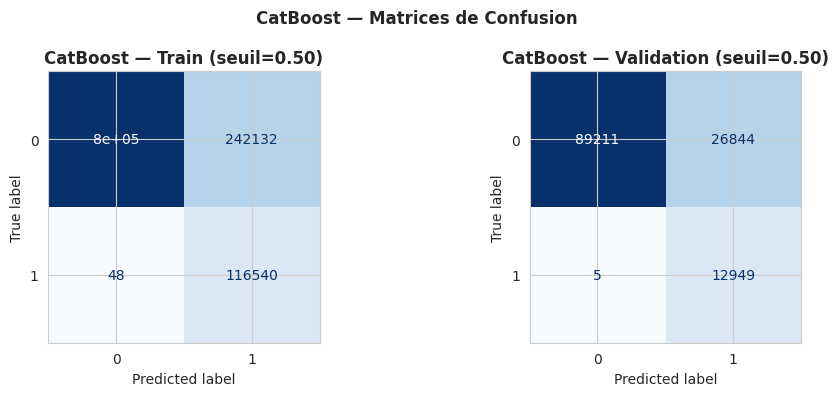

  → confusion_catboost.png sauvegardé

════════════════════════════════════════════════════════════
  ÉTAPE 2 — Construction des datasets augmentés
════════════════════════════════════════════════════════════
  Dataset train augmenté : (1290081, 51)
  Dataset test  augmenté : (430100, 51)

════════════════════════════════════════════════════════════
  ÉTAPE 3 — XGBoost Cost-Sensitive sur dataset augmenté
════════════════════════════════════════════════════════════
  Poids XGB → classe 0 : 0.1004  |  classe 1 : 0.8996


  0%|          | 0/50 [00:00<?, ?it/s]


✅ XGBoost meilleur PR-AUC val : 0.4545
   Paramètres : {'n_estimators': 1275, 'max_depth': 10, 'learning_rate': 0.1353673323484377, 'subsample': 0.5021207906054961, 'colsample_bytree': 0.5661706633016962, 'min_child_weight': 5, 'gamma': 0.7816661109550105, 'reg_alpha': 0.36200759274252625, 'reg_lambda': 0.008781065084027399, 'max_delta_step': 10}

  PR-AUC Train : 0.8705  |  PR-AUC Val : 0.4475
  ⚠️  Écart important train/val — possible overfitting, vérifier les params

🎯 Seuil optimal XGB (val) : 0.0474  |  F1 : 0.4915


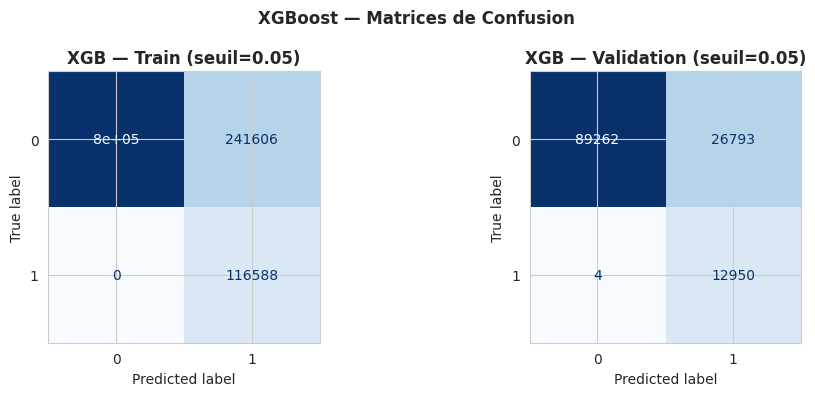

  → confusion_xgb.png sauvegardé

════════════════════════════════════════════════════════════
  ÉTAPE 4 — Prédictions finales sur X_test
════════════════════════════════════════════════════════════
✅ submission.csv créé
                  id       target
dtf_0000001_08a8a524 4.917137e-07
dtf_0000002_ae0d3769 8.090706e-01
dtf_0000003_843bab7c 6.960963e-01
dtf_0000004_91643844 1.519465e-06
dtf_0000005_17bd9a08 5.754586e-01
dtf_0000006_252a6318 4.969322e-06
dtf_0000007_52b0ffae 2.057035e-07
dtf_0000008_c37743d9 8.791133e-07
dtf_0000009_bff3cf50 3.463922e-01
dtf_0000010_7f815b93 3.104994e-01

════════════════════════════════════════════════════════════
  RÉSUMÉ
════════════════════════════════════════════════════════════
  CatBoost — PR-AUC val    : 0.4529
  XGBoost  — PR-AUC val    : 0.4545
  CatBoost — Seuil optimal : 0.5005
  XGBoost  — Seuil optimal : 0.0474
  Fichiers : confusion_catboost.png | confusion_xgb.png | submission.csv


In [25]:
import pandas as pd
import numpy as np
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score, confusion_matrix,
    precision_recall_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
N_TRIALS     = 50
RANDOM_STATE = 42

# ─────────────────────────────────────────────────────────────
# UTILITAIRES
# ─────────────────────────────────────────────────────────────

def compute_class_weights(y):
    """Retourne (w0, w1) cost-sensitive : w1=n0/n_total, w0=n1/n_total"""
    n_total = len(y)
    n0 = (y == 0).sum()
    n1 = (y == 1).sum()
    w0 = n1 / n_total   # poids classe majoritaire → petit
    w1 = n0 / n_total   # poids classe minoritaire → grand
    return w0, w1

def make_sample_weights(y, w0, w1):
    return np.where(y == 1, w1, w0)

def plot_confusion(y_true, y_pred_label, title, ax):
    cm = confusion_matrix(y_true, y_pred_label)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

def find_best_threshold(y_true, y_prob):
    """Seuil qui maximise le F1-score sur la PR-curve"""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = np.where(
        (precision + recall) == 0, 0,
        2 * precision * recall / (precision + recall)
    )
    best_idx = np.argmax(f1_scores[:-1])
    return thresholds[best_idx], f1_scores[best_idx]

def print_section(title):
    print("\n" + "═" * 60)
    print(f"  {title}")
    print("═" * 60)

# ─────────────────────────────────────────────────────────────
# VÉRIFICATION DES DONNÉES
# (X_train_selected / y_train_selected / X_test_selected viennent
#  du script de feature selection — c'est le SEUL dataset valide,
#  on n'utilise plus aucune variable suffixée "1")
# ─────────────────────────────────────────────────────────────
print_section("VÉRIFICATION DES DONNÉES")
print(f"  X_train_selected : {X_train_selected.shape}")
print(f"  y_train_selected : {y_train  .shape}")
print(f"  X_test_selected  : {X_test_selected.shape}")
print(f"  Features : {X_train_selected.columns.tolist()}")

# ─────────────────────────────────────────────────────────────
# ÉTAPE 1 — CATBOOST COST-SENSITIVE  (90% train / 10% val)
# ─────────────────────────────────────────────────────────────
print_section("ÉTAPE 1 — CatBoost Cost-Sensitive")

# Split 90/10 stratifié
X_cat_train, X_cat_val, y_cat_train, y_cat_val = train_test_split(
    X_train_selected, y_train  ,
    test_size=0.10, random_state=RANDOM_STATE, stratify=y_train  
)

# Poids cost-sensitive
w0_cat, w1_cat = compute_class_weights(y_cat_train)
print(f"  Poids CatBoost → classe 0 : {w0_cat:.4f}  |  classe 1 : {w1_cat:.4f}")
sw_cat_train = make_sample_weights(y_cat_train.values, w0_cat, w1_cat)

# Optuna CatBoost
def cat_objective(trial):
    params = {
        'iterations':          trial.suggest_int('iterations', 200, 1500),
        'depth':               trial.suggest_int('depth', 3, 10),
        'learning_rate':       trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 2.0),
        'random_strength':     trial.suggest_float('random_strength', 1e-3, 10, log=True),
        'border_count':        trial.suggest_int('border_count', 32, 255),
        'min_data_in_leaf':    trial.suggest_int('min_data_in_leaf', 1, 50),
        'task_type':           'GPU',
        'devices':             '0',
        'eval_metric':         'PRAUC',
        'random_seed':         RANDOM_STATE,
        'verbose':             False,
        'early_stopping_rounds': 30,
    }
    cat = CatBoostClassifier(**params)
    cat.fit(
        X_cat_train, y_cat_train,
        sample_weight=sw_cat_train,
        eval_set=(X_cat_val, y_cat_val),
        verbose=False
    )
    y_prob_val = cat.predict_proba(X_cat_val)[:, 1]
    return average_precision_score(y_cat_val, y_prob_val)

study_cat = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_cat.optimize(cat_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_cat_params = {
    **study_cat.best_params,
    'task_type':   'GPU',
    'devices':     '0',
    'eval_metric': 'PRAUC',
    'random_seed': RANDOM_STATE,
    'verbose':     False,
}
print(f"\n✅ CatBoost meilleur PR-AUC val : {study_cat.best_value:.4f}")
print(f"   Paramètres : {study_cat.best_params}")

# Entraînement final CatBoost (sans early stopping)
cat_final = CatBoostClassifier(**best_cat_params)
cat_final.fit(
    X_cat_train, y_cat_train,
    sample_weight=sw_cat_train,
    eval_set=(X_cat_val, y_cat_val),
    verbose=False
)

# Probabilités CatBoost sur train + val + test
cat_prob_train = cat_final.predict_proba(X_cat_train)[:, 1]
cat_prob_val   = cat_final.predict_proba(X_cat_val)[:, 1]
cat_prob_test  = cat_final.predict_proba(X_test_selected)[:, 1]

# Seuil optimal CatBoost
best_thr_cat, best_f1_cat = find_best_threshold(y_cat_val, cat_prob_val)
print(f"\n🎯 Seuil optimal CatBoost (val) : {best_thr_cat:.4f}  |  F1 : {best_f1_cat:.4f}")

# Matrices de confusion CatBoost
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(
    y_cat_train,
    (cat_prob_train >= best_thr_cat).astype(int),
    f"CatBoost — Train (seuil={best_thr_cat:.2f})", axes[0]
)
plot_confusion(
    y_cat_val,
    (cat_prob_val >= best_thr_cat).astype(int),
    f"CatBoost — Validation (seuil={best_thr_cat:.2f})", axes[1]
)
plt.suptitle("CatBoost — Matrices de Confusion", fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_catboost.png", dpi=150, bbox_inches='tight')
plt.show()
print("  → confusion_catboost.png sauvegardé")

# ─────────────────────────────────────────────────────────────
# ÉTAPE 2 — CONSTRUCTION DU NOUVEAU DATASET AUGMENTÉ
# ─────────────────────────────────────────────────────────────
print_section("ÉTAPE 2 — Construction des datasets augmentés")

# Recoller les probas CatBoost dans le bon ordre (par index)
idx_cat_train = X_cat_train.index.tolist()
idx_cat_val   = X_cat_val.index.tolist()

prob_by_idx = pd.Series(
    np.concatenate([cat_prob_train, cat_prob_val]),
    index=idx_cat_train + idx_cat_val
).sort_index()

X_aug_full = X_train_selected.copy()
X_aug_full['cat_proba'] = prob_by_idx.values
y_aug_full = y_train.copy()

# Test augmenté
X_test_aug = X_test_selected.copy()
X_test_aug['cat_proba'] = cat_prob_test

print(f"  Dataset train augmenté : {X_aug_full.shape}")
print(f"  Dataset test  augmenté : {X_test_aug.shape}")

# ─────────────────────────────────────────────────────────────
# ÉTAPE 3 — XGBOOST COST-SENSITIVE  (90% train / 10% val)
# ─────────────────────────────────────────────────────────────
print_section("ÉTAPE 3 — XGBoost Cost-Sensitive sur dataset augmenté")

# Split 90/10 sur le dataset augmenté
X_xgb_train, X_xgb_val, y_xgb_train, y_xgb_val = train_test_split(
    X_aug_full, y_aug_full,
    test_size=0.10, random_state=RANDOM_STATE, stratify=y_aug_full
)

# Poids cost-sensitive XGB
w0_xgb, w1_xgb = compute_class_weights(y_xgb_train)
print(f"  Poids XGB → classe 0 : {w0_xgb:.4f}  |  classe 1 : {w1_xgb:.4f}")
sw_xgb_train = make_sample_weights(y_xgb_train.values, w0_xgb, w1_xgb)

# Optuna XGBoost
def xgb_objective(trial):
    params = {
        'n_estimators':          trial.suggest_int('n_estimators', 200, 1500),
        'max_depth':             trial.suggest_int('max_depth', 3, 10),
        'learning_rate':         trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample':             trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':      trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight':      trial.suggest_int('min_child_weight', 1, 10),
        'gamma':                 trial.suggest_float('gamma', 0, 5),
        'reg_alpha':             trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda':            trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'max_delta_step':        trial.suggest_int('max_delta_step', 0, 10),
        'tree_method':           'hist',
        'device':                'cuda',
        'eval_metric':           'aucpr',
        'random_state':          RANDOM_STATE,
        'use_label_encoder':     False,
        'verbosity':             0,
        'early_stopping_rounds': 30,
    }
    xgb = XGBClassifier(**params)
    xgb.fit(
        X_xgb_train, y_xgb_train,
        sample_weight=sw_xgb_train,
        eval_set=[(X_xgb_val, y_xgb_val)],
        verbose=False
    )
    y_prob_val = xgb.predict_proba(X_xgb_val)[:, 1]
    return average_precision_score(y_xgb_val, y_prob_val)

study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_xgb_params = {
    **study_xgb.best_params,
    'tree_method':       'hist',
    'device':            'cuda',
    'eval_metric':       'aucpr',
    'random_state':      RANDOM_STATE,
    'use_label_encoder': False,
    'verbosity':         0,
}
print(f"\n✅ XGBoost meilleur PR-AUC val : {study_xgb.best_value:.4f}")
print(f"   Paramètres : {study_xgb.best_params}")

# Entraînement final XGBoost
xgb_final = XGBClassifier(**best_xgb_params)
xgb_final.fit(
    X_xgb_train, y_xgb_train,
    sample_weight=sw_xgb_train,
    eval_set=[(X_xgb_val, y_xgb_val)],
    verbose=False
)

# Probabilités XGB
xgb_prob_train = xgb_final.predict_proba(X_xgb_train)[:, 1]
xgb_prob_val   = xgb_final.predict_proba(X_xgb_val)[:, 1]
xgb_prob_test  = xgb_final.predict_proba(X_test_aug)[:, 1]

pr_auc_train = average_precision_score(y_xgb_train, xgb_prob_train)
pr_auc_val   = average_precision_score(y_xgb_val,   xgb_prob_val)
print(f"\n  PR-AUC Train : {pr_auc_train:.4f}  |  PR-AUC Val : {pr_auc_val:.4f}")
if pr_auc_train - pr_auc_val > 0.10:
    print("  ⚠️  Écart important train/val — possible overfitting, vérifier les params")

# Seuil optimal XGB
best_thr_xgb, best_f1_xgb = find_best_threshold(y_xgb_val, xgb_prob_val)
print(f"\n🎯 Seuil optimal XGB (val) : {best_thr_xgb:.4f}  |  F1 : {best_f1_xgb:.4f}")

# Matrices de confusion XGBoost
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(
    y_xgb_train,
    (xgb_prob_train >= best_thr_xgb).astype(int),
    f"XGB — Train (seuil={best_thr_xgb:.2f})", axes[0]
)
plot_confusion(
    y_xgb_val,
    (xgb_prob_val >= best_thr_xgb).astype(int),
    f"XGB — Validation (seuil={best_thr_xgb:.2f})", axes[1]
)
plt.suptitle("XGBoost — Matrices de Confusion", fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_xgb.png", dpi=150, bbox_inches='tight')
plt.show()
print("  → confusion_xgb.png sauvegardé")

# ─────────────────────────────────────────────────────────────
# ÉTAPE 4 — PRÉDICTION SUR LE TEST & SUBMISSION
# ─────────────────────────────────────────────────────────────
print_section("ÉTAPE 4 — Prédictions finales sur X_test")

y_test_pred = xgb_prob_test

submission = pd.DataFrame({
    'id':     df_test['id'],
    'target': y_test_pred
})
submission.to_csv('submission.csv', index=False)
print("✅ submission.csv créé")
print(submission.head(10).to_string(index=False))

# ─────────────────────────────────────────────────────────────
# RÉSUMÉ FINAL
# ─────────────────────────────────────────────────────────────
print("\n" + "═" * 60)
print("  RÉSUMÉ")
print("═" * 60)
print(f"  CatBoost — PR-AUC val    : {study_cat.best_value:.4f}")
print(f"  XGBoost  — PR-AUC val    : {study_xgb.best_value:.4f}")
print(f"  CatBoost — Seuil optimal : {best_thr_cat:.4f}")
print(f"  XGBoost  — Seuil optimal : {best_thr_xgb:.4f}")
print(f"  Fichiers : confusion_catboost.png | confusion_xgb.png | submission.csv")

In [26]:
X_train_selected.columns

Index(['op_op_03', 'dest_receive_frequency', 'op_op_05',
       'amount_rank_in_origin_history', 'period_sin',
       'dest_avg_amount_received', 'abs_amount_minus_mean_over_amount',
       'period_since_start', 'origin_to_dest_pair_count', 'period_cos',
       'dest_balance_before_group_mean', 'origin_balance_after',
       'dest_balance_delta', 'amount_to_origin_balance_ratio',
       'dest_was_empty', 'tx_velocity', 'origin_balance_before_group_median',
       'amount_vs_avg', 'origin_balance_error', 'origin_n_unique_operations',
       'origin_robust_zscore', 'origin_time_since_last_tx', 'amount_mad_ratio',
       'no_balance_change_dest', 'accounting_mismatch', 'amount_in_q25_q75',
       'op_op_04', 'origin_pct_drains', 'origin_max_amount',
       'origin_std_amount', 'origin_iqr_ratio', 'origin_skew_amount',
       'origin_balance_before_mean', 'origin_q90_amount',
       'origin_balance_after_skew', 'destination_balance_after_mad',
       'origin_balance_before_mad', 'amount_be

# **Cost-Sensitive Stacking Pipeline with Pre-Optimized Hyperparameters**

This notebook implements two advanced cost-sensitive stacking pipelines for fraud detection using **LightGBM**, **XGBoost**, and **CatBoost**.

Unlike the previous notebook, **no hyperparameter optimization is performed here**. All models are trained using the **best hyperparameters previously obtained through Optuna**, allowing us to focus exclusively on the evaluation of the final ensemble architectures.

---

# **Pipeline A — Cascaded Stacking**

This pipeline follows a sequential cascade:

> **LightGBM → XGBoost → CatBoost**

## **Pipeline Architecture**

```text
                    Original Features
                           │
                           ▼
                  LightGBM (50% Train)
                           │
             Probability + Logit Features
                           │
                           ▼
                  XGBoost (25% Train)
                           │
             Probability + Logit Features
                           │
                           ▼
                 CatBoost (10% Train)
                           │
                           ▼
                 Final Validation (15%)
                           │
                           ▼
                   Test Predictions
```

### **Workflow**

- **Stage 1:** Train a LightGBM model.
- **Stage 2:** Add the predicted probabilities and logits from LightGBM as new features.
- **Stage 3:** Train an XGBoost model on the augmented dataset.
- **Stage 4:** Add the XGBoost probabilities and logits.
- **Stage 5:** Train a final CatBoost classifier to produce the final predictions.

The dataset is intentionally split into independent subsets (50% / 25% / 10% / 15%) to minimize information leakage while progressively enriching the feature space with meta-features generated by previous models.

---

# **Pipeline B — Out-of-Fold (OOF) Stacking**

This pipeline follows a classical stacking strategy:

> **CatBoost (OOF) → XGBoost**

## **Pipeline Architecture**

```text
               Original Training Dataset
                         │
                         ▼
              Stratified 5-Fold Split
                         │
        ┌────────────────┼────────────────┐
        ▼                ▼                ▼
     Fold 1           Fold 2          ... Fold 5
        │                │
        ▼                ▼
     CatBoost        CatBoost
        │                │
        └────────────────┴──────────────┐
                                        ▼
                        Out-of-Fold Predictions
                                        │
                         Probability + Logit
                                        │
                                        ▼
                     Augmented Training Dataset
                                        │
                                        ▼
                            Final XGBoost Model
                                        │
                                        ▼
                              Test Predictions
```

### **Workflow**

- Generate **Out-of-Fold (OOF)** predictions using a 5-fold CatBoost model.
- Create two new meta-features:
  - CatBoost probability
  - CatBoost logit
- Train a final XGBoost classifier using the augmented dataset.
- Produce the final test predictions.

Using OOF predictions guarantees that every generated meta-feature is computed without information leakage.

---

# **Hyperparameter Optimization**

The hyperparameters used in this notebook are **not optimized during execution**.

They correspond to the **best configurations previously obtained using Optuna** in a dedicated hyperparameter optimization notebook.

Each model therefore uses its own optimized parameter set:

- **LightGBM:** Best Optuna configuration
- **XGBoost (Pipeline A):** Best Optuna configuration
- **CatBoost (Pipeline A):** Best Optuna configuration
- **CatBoost (Pipeline B):** Best Optuna configuration
- **XGBoost (Pipeline B):** Best Optuna configuration

This significantly reduces computation time while ensuring that every model is trained using its most effective hyperparameter configuration.

---

# **Main Characteristics**

- Pre-optimized hyperparameters obtained with **Optuna**
- Cost-sensitive learning using sample weights
- GPU acceleration for CatBoost and XGBoost
- LightGBM as the first-level learner
- Automatic optimal threshold selection based on the F1-score
- Precision-Recall AUC (PR-AUC) as the primary evaluation metric
- Confusion matrix visualization
- Generation of multiple submission files for leaderboard evaluation

---

# **Outputs**

The notebook produces:

- `submission_pipeline_A.csv`
- `submission_xgb_only.csv`
- `submission_ensemble.csv`
- Confusion matrices for every model
- PR-AUC, optimal threshold, and F1-score for each pipeline
- Final comparison between both stacking strategies


═════════════════════════════════════════════════════════════════
  VÉRIFICATION DES DONNÉES
═════════════════════════════════════════════════════════════════
  X_train_selected : (1290081, 50)
  y_train_selected : (1290081,)
  X_test_selected  : (430100, 50)

═════════════════════════════════════════════════════════════════
  PIPELINE A — CASCADE 4 MODÈLES (params fixés)
═════════════════════════════════════════════════════════════════

  Répartition Pipeline A :
    LightGBM train   :   645,040  (~50%)
    XGBoost  train   :   322,520  (~25%)
    CatBoost train   :   129,008  (~10%)
    Val finale       :   193,513  (~15%)

═════════════════════════════════════════════════════════════════
  PIPELINE A — Étape 1 : LightGBM
═════════════════════════════════════════════════════════════════
  Poids → classe 0 : 0.1004  |  classe 1 : 0.8996
  LightGBM (sur XGB train) → PR-AUC : 0.4477  |  Seuil F1 : 0.6735  |  F1 : 0.4914


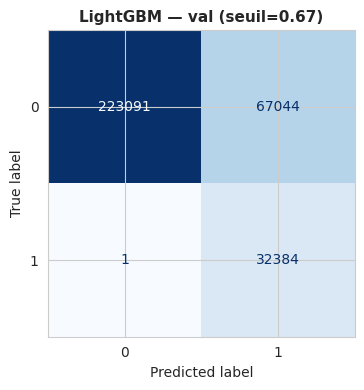

  → confusion_A_lightgbm.png sauvegardé

═════════════════════════════════════════════════════════════════
  PIPELINE A — Étape 2 : XGBoost
═════════════════════════════════════════════════════════════════
  Poids → classe 0 : 0.1004  |  classe 1 : 0.8996
  XGBoost-A (sur CatBoost train) → PR-AUC : 0.4473  |  Seuil F1 : 0.1962  |  F1 : 0.4913


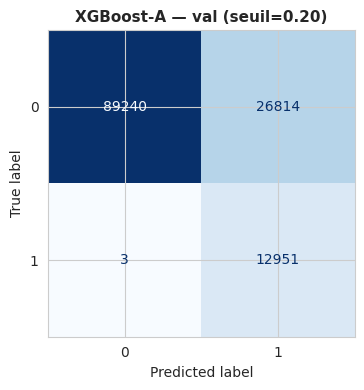

  → confusion_A_xgboost.png sauvegardé

═════════════════════════════════════════════════════════════════
  PIPELINE A — Étape 3 : CatBoost Cascade
═════════════════════════════════════════════════════════════════
  Poids → classe 0 : 0.1004  |  classe 1 : 0.8996


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  Pipeline A final (CatBoost cascade) → PR-AUC : 0.4480  |  Seuil F1 : 0.0081  |  F1 : 0.4897


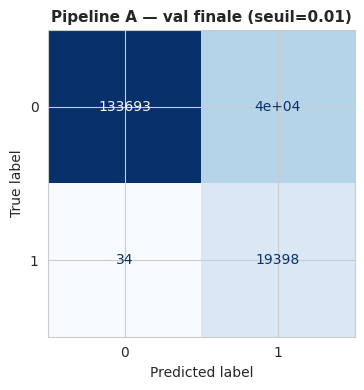

  → confusion_A_catboost_final.png sauvegardé

═════════════════════════════════════════════════════════════════
  PIPELINE B — OOF CatBoost (5 folds, params fixés)
═════════════════════════════════════════════════════════════════

  Génération OOF CatBoost-B ...
    Fold 1/5 ... 

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


PR-AUC = 0.4487
    Fold 2/5 ... 

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


PR-AUC = 0.4479
    Fold 3/5 ... 

...

PR-AUC = 0.4487
    Fold 4/5 ... 

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


PR-AUC = 0.4502
    Fold 5/5 ... 

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


PR-AUC = 0.4451

  OOF global PR-AUC : 0.4481

  Dataset B augmenté : (1290081, 52)

═════════════════════════════════════════════════════════════════
  PIPELINE B — XGBoost final (params fixés)
═════════════════════════════════════════════════════════════════
  Poids → classe 0 : 0.1004  |  classe 1 : 0.8996
  Pipeline B (XGBoost final) → PR-AUC : 0.7398  |  Seuil F1 : 0.7852  |  F1 : 0.6660


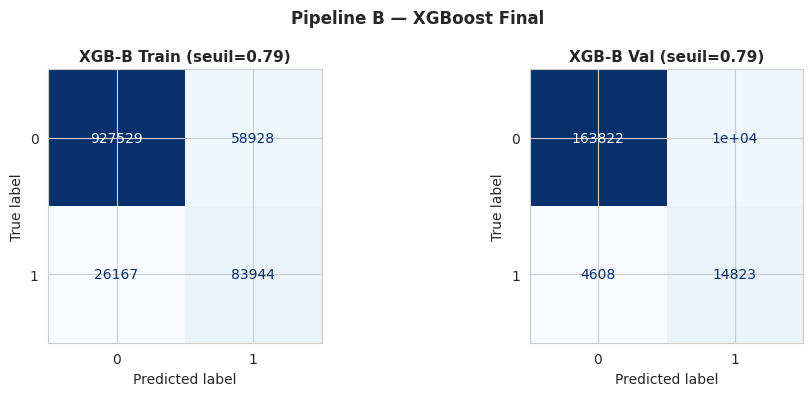

  → confusion_B_xgboost.png sauvegardé

═════════════════════════════════════════════════════════════════
  SOUMISSIONS
═════════════════════════════════════════════════════════════════
✅ submission_xgb_only.csv
✅ submission_pipeline_A.csv
✅ submission_ensemble.csv

═════════════════════════════════════════════════════════════════
  RÉSUMÉ FINAL
═════════════════════════════════════════════════════════════════

  ── PIPELINE A (Cascade LGB → XGB → CatBoost) ──
     LightGBM   PR-AUC (val)  : 0.4477
     XGBoost-A  PR-AUC (val)  : 0.4473
     Pipeline A PR-AUC (val)  : 0.4480  |  Seuil : 0.0081  |  F1 : 0.4897

  ── PIPELINE B (OOF CatBoost → XGBoost) ──
     CatBoost-B PR-AUC OOF    : 0.4481
     Pipeline B PR-AUC (val)  : 0.7398  |  Seuil : 0.7852  |  F1 : 0.6660

  ── FICHIERS GÉNÉRÉS ──
     submission_xgb_only.csv        (XGBoost seul — Pipeline B)
     submission_pipeline_A.csv      (Cascade LGB → XGB → CatBoost)
     submission_ensemble.csv        (Moyenne Pipeline A + B)
     co

In [27]:
import pandas as pd
import numpy as np
import warnings
import lightgbm as lgb_lib
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, confusion_matrix,
    precision_recall_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42

# ─────────────────────────────────────────────────────────────
# MEILLEURS HYPERPARAMÈTRES (Optuna pré-calculé)
# ─────────────────────────────────────────────────────────────
BEST_LGB_PARAMS = {
    'n_estimators':      1237,
    'max_depth':         9,
    'learning_rate':     0.0010869589066672075,
    'num_leaves':        81,
    'subsample':         0.9896262103720795,
    'colsample_bytree':  0.8216698991262852,
    'min_child_samples': 89,
    'reg_alpha':         0.0013256530038927626,
    'reg_lambda':        0.006815746818486279,
    'device':            'cpu',
    'random_state':      RANDOM_STATE,
    'verbosity':         -1,
    'n_jobs':            -1,
}

BEST_XGB_A_PARAMS = {
    'n_estimators':     1461,
    'max_depth':        9,
    'learning_rate':    0.21244807336152005,
    'subsample':        0.9474136752138245,
    'colsample_bytree': 0.7587399872866512,
    'min_child_weight': 10,
    'gamma':            0.4424625102595975,
    'reg_alpha':        0.0009548041810464163,
    'reg_lambda':       0.00016832027985721928,
    'max_delta_step':   3,
    'tree_method':      'hist',
    'device':           'cuda',
    'eval_metric':      'aucpr',
    'random_state':     RANDOM_STATE,
    'verbosity':        0,
}

BEST_CAT_A_PARAMS = {
    'iterations':          1429,
    'depth':               10,
    'learning_rate':       0.25215116809209465,
    'l2_leaf_reg':         0.0011799062523159302,
    'bagging_temperature': 0.7944181527289241,
    'random_strength':     0.06688216072994568,
    'border_count':        246,
    'min_data_in_leaf':    34,
    'task_type':           'GPU',
    'devices':             '0',
    'eval_metric':         'PRAUC',
    'random_seed':         RANDOM_STATE,
    'verbose':             False,
}

BEST_CAT_B_PARAMS = {
    'iterations':          1364,
    'depth':               10,
    'learning_rate':       0.04220565240590451,
    'l2_leaf_reg':         0.0011799062523159302,
    'bagging_temperature': 0.030735474656208628,
    'random_strength':     0.056535821855678674,
    'border_count':        35,
    'min_data_in_leaf':    49,
    'task_type':           'GPU',
    'devices':             '0',
    'eval_metric':         'PRAUC',
    'random_seed':         RANDOM_STATE,
    'verbose':             False,
}

BEST_XGB_B_PARAMS = {
    'n_estimators':     1461,
    'max_depth':        9,
    'learning_rate':    0.21244807336152005,
    'subsample':        0.9474136752138245,
    'colsample_bytree': 0.7587399872866512,
    'min_child_weight': 10,
    'gamma':            0.4424625102595975,
    'reg_alpha':        0.0009548041810464163,
    'reg_lambda':       0.00016832027985721928,
    'max_delta_step':   3,
    'tree_method':      'hist',
    'device':           'cuda',
    'eval_metric':      'aucpr',
    'random_state':     RANDOM_STATE,
    'verbosity':        0,
}

# ─────────────────────────────────────────────────────────────
# UTILITAIRES
# ─────────────────────────────────────────────────────────────

def compute_class_weights(y):
    n_total = len(y)
    n0 = (y == 0).sum()
    n1 = (y == 1).sum()
    w0 = n1 / n_total
    w1 = n0 / n_total
    return w0, w1

def make_sample_weights(y, w0, w1):
    return np.where(y == 1, w1, w0)

def add_logit(proba):
    eps = 1e-7
    return np.log(proba + eps) - np.log(1 - proba + eps)

def to_float32(df):
    return df.astype(np.float32)

def plot_confusion(y_true, y_pred_label, title, ax):
    cm = confusion_matrix(y_true, y_pred_label)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')

def find_best_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = np.where(
        (precision + recall) == 0, 0,
        2 * precision * recall / (precision + recall)
    )
    best_idx = np.argmax(f1_scores[:-1])
    return thresholds[best_idx], f1_scores[best_idx]

def print_section(title):
    print("\n" + "═" * 65)
    print(f"  {title}")
    print("═" * 65)

def print_metrics(name, y_true, y_prob):
    auc = average_precision_score(y_true, y_prob)
    thr, f1 = find_best_threshold(y_true, y_prob)
    print(f"  {name} → PR-AUC : {auc:.4f}  |  Seuil F1 : {thr:.4f}  |  F1 : {f1:.4f}")
    return auc, thr, f1

# ─────────────────────────────────────────────────────────────
# VÉRIFICATION
# ─────────────────────────────────────────────────────────────
print_section("VÉRIFICATION DES DONNÉES")
print(f"  X_train_selected : {X_train_selected.shape}")
print(f"  y_train_selected : {y_train_selected.shape}")
print(f"  X_test_selected  : {X_test_selected.shape}")

feature_cols = X_train_selected.columns.tolist()

# ═════════════════════════════════════════════════════════════
# PIPELINE A — CASCADE LGB → XGB → CatBoost
# ═════════════════════════════════════════════════════════════

print_section("PIPELINE A — CASCADE 4 MODÈLES (params fixés)")

# Split 50 / 25 / 10 / 15
X_A_train, X_A_rest, y_A_train, y_A_rest = train_test_split(
    X_train_selected, y_train_selected,
    test_size=0.50, random_state=RANDOM_STATE, stratify=y_train_selected
)
X_A_xgb_train, X_A_xgb_rest, y_A_xgb_train, y_A_xgb_rest = train_test_split(
    X_A_rest, y_A_rest,
    test_size=0.50, random_state=RANDOM_STATE, stratify=y_A_rest
)
X_A_cat_train, X_A_final_val, y_A_cat_train, y_A_final_val = train_test_split(
    X_A_xgb_rest, y_A_xgb_rest,
    test_size=0.60, random_state=RANDOM_STATE, stratify=y_A_xgb_rest
)

print(f"\n  Répartition Pipeline A :")
print(f"    LightGBM train   : {X_A_train.shape[0]:>9,}  (~50%)")
print(f"    XGBoost  train   : {X_A_xgb_train.shape[0]:>9,}  (~25%)")
print(f"    CatBoost train   : {X_A_cat_train.shape[0]:>9,}  (~10%)")
print(f"    Val finale       : {X_A_final_val.shape[0]:>9,}  (~15%)")

# ─────────────────────────────────────────────────────────────
# A.1 — LIGHTGBM
# ─────────────────────────────────────────────────────────────
print_section("PIPELINE A — Étape 1 : LightGBM")

w0_lgb, w1_lgb = compute_class_weights(y_A_train)
sw_lgb = make_sample_weights(y_A_train.values, w0_lgb, w1_lgb)
print(f"  Poids → classe 0 : {w0_lgb:.4f}  |  classe 1 : {w1_lgb:.4f}")

lgb_final = LGBMClassifier(**BEST_LGB_PARAMS)
lgb_final.fit(X_A_train, y_A_train, sample_weight=sw_lgb)

lgb_proba_xgb_train = lgb_final.predict_proba(X_A_xgb_train)[:, 1]
lgb_proba_cat_train = lgb_final.predict_proba(X_A_cat_train)[:, 1]
lgb_proba_final_val = lgb_final.predict_proba(X_A_final_val)[:, 1]
lgb_proba_test      = lgb_final.predict_proba(X_test_selected)[:, 1]

auc_lgb, thr_lgb, f1_lgb = print_metrics(
    "LightGBM (sur XGB train)", y_A_xgb_train, lgb_proba_xgb_train
)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
plot_confusion(
    y_A_xgb_train,
    (lgb_proba_xgb_train >= thr_lgb).astype(int),
    f"LightGBM — val (seuil={thr_lgb:.2f})", ax
)
plt.tight_layout()
plt.savefig("confusion_A_lightgbm.png", dpi=150, bbox_inches='tight')
plt.show()
print("  → confusion_A_lightgbm.png sauvegardé")

# ─────────────────────────────────────────────────────────────
# A.2 — XGBOOST  (features + lgb_proba + lgb_logit)
# ─────────────────────────────────────────────────────────────
print_section("PIPELINE A — Étape 2 : XGBoost")

def augment_lgb(X, lgb_p):
    df = X.copy()
    df['lgb_proba'] = lgb_p.astype(np.float32)
    df['lgb_logit'] = add_logit(lgb_p).astype(np.float32)
    return to_float32(df)

X_A_xgb_train_aug = augment_lgb(X_A_xgb_train, lgb_proba_xgb_train)
X_A_cat_train_aug = augment_lgb(X_A_cat_train, lgb_proba_cat_train)
X_A_final_val_aug = augment_lgb(X_A_final_val, lgb_proba_final_val)
X_test_aug_A1     = augment_lgb(X_test_selected, lgb_proba_test)

w0_xgb_A, w1_xgb_A = compute_class_weights(y_A_xgb_train)
sw_xgb_A = make_sample_weights(y_A_xgb_train.values, w0_xgb_A, w1_xgb_A)
print(f"  Poids → classe 0 : {w0_xgb_A:.4f}  |  classe 1 : {w1_xgb_A:.4f}")

xgb_A_final = XGBClassifier(**BEST_XGB_A_PARAMS)
xgb_A_final.fit(
    X_A_xgb_train_aug, y_A_xgb_train,
    sample_weight=sw_xgb_A,
    verbose=False
)

xgb_proba_cat_train = xgb_A_final.predict_proba(X_A_cat_train_aug)[:, 1]
xgb_proba_final_val = xgb_A_final.predict_proba(X_A_final_val_aug)[:, 1]
xgb_proba_test_A    = xgb_A_final.predict_proba(X_test_aug_A1)[:, 1]

auc_xgb_A, thr_xgb_A, f1_xgb_A = print_metrics(
    "XGBoost-A (sur CatBoost train)", y_A_cat_train, xgb_proba_cat_train
)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
plot_confusion(
    y_A_cat_train,
    (xgb_proba_cat_train >= thr_xgb_A).astype(int),
    f"XGBoost-A — val (seuil={thr_xgb_A:.2f})", ax
)
plt.tight_layout()
plt.savefig("confusion_A_xgboost.png", dpi=150, bbox_inches='tight')
plt.show()
print("  → confusion_A_xgboost.png sauvegardé")

# ─────────────────────────────────────────────────────────────
# A.3 — CATBOOST CASCADE (features + lgb + xgb probas/logits)
# ─────────────────────────────────────────────────────────────
print_section("PIPELINE A — Étape 3 : CatBoost Cascade")

def augment_xgb(X_aug1, xgb_p):
    df = X_aug1.copy()
    df['xgb_proba'] = xgb_p.astype(np.float32)
    df['xgb_logit'] = add_logit(xgb_p).astype(np.float32)
    return to_float32(df)

X_A_cat_train_aug2 = augment_xgb(X_A_cat_train_aug, xgb_proba_cat_train)
X_A_final_val_aug2 = augment_xgb(X_A_final_val_aug, xgb_proba_final_val)
X_test_aug_A2      = augment_xgb(X_test_aug_A1,     xgb_proba_test_A)

w0_cat_A, w1_cat_A = compute_class_weights(y_A_cat_train)
sw_cat_A = make_sample_weights(y_A_cat_train.values, w0_cat_A, w1_cat_A)
print(f"  Poids → classe 0 : {w0_cat_A:.4f}  |  classe 1 : {w1_cat_A:.4f}")

cat_A_final = CatBoostClassifier(**BEST_CAT_A_PARAMS)
cat_A_final.fit(
    X_A_cat_train_aug2, y_A_cat_train,
    sample_weight=sw_cat_A,
    eval_set=(X_A_final_val_aug2, y_A_final_val),
    verbose=False
)

pipe_A_proba_val  = cat_A_final.predict_proba(X_A_final_val_aug2)[:, 1]
pipe_A_proba_test = cat_A_final.predict_proba(X_test_aug_A2)[:, 1]

auc_A, thr_A, f1_A = print_metrics(
    "Pipeline A final (CatBoost cascade)", y_A_final_val, pipe_A_proba_val
)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
plot_confusion(
    y_A_final_val,
    (pipe_A_proba_val >= thr_A).astype(int),
    f"Pipeline A — val finale (seuil={thr_A:.2f})", ax
)
plt.tight_layout()
plt.savefig("confusion_A_catboost_final.png", dpi=150, bbox_inches='tight')
plt.show()
print("  → confusion_A_catboost_final.png sauvegardé")

# ═════════════════════════════════════════════════════════════
# PIPELINE B — OOF CatBoost → XGBoost
# ═════════════════════════════════════════════════════════════

print_section("PIPELINE B — OOF CatBoost (5 folds, params fixés)")

X_B      = X_train_selected.values.astype(np.float32)
y_B      = y_train_selected.values
X_B_test = X_test_selected.values.astype(np.float32)
n_train  = X_B.shape[0]
n_test   = X_B_test.shape[0]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_cat_B  = np.zeros(n_train, dtype=np.float32)
test_cat_B = np.zeros((n_test, 5), dtype=np.float32)

print("\n  Génération OOF CatBoost-B ...")
for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_B, y_B)):
    print(f"    Fold {fold+1}/5 ...", end=' ')
    w0_f, w1_f = compute_class_weights(y_B[tr_idx])
    sw_f = make_sample_weights(y_B[tr_idx], w0_f, w1_f)
    cat_f = CatBoostClassifier(**BEST_CAT_B_PARAMS)
    cat_f.fit(
        X_B[tr_idx], y_B[tr_idx],
        sample_weight=sw_f,
        eval_set=(X_B[vl_idx], y_B[vl_idx]),
        use_best_model=False,
        verbose=False
    )
    oof_cat_B[vl_idx]   = cat_f.predict_proba(X_B[vl_idx])[:, 1]
    test_cat_B[:, fold] = cat_f.predict_proba(X_B_test)[:, 1]
    fold_auc = average_precision_score(y_B[vl_idx], oof_cat_B[vl_idx])
    print(f"PR-AUC = {fold_auc:.4f}")

test_cat_B_mean = test_cat_B.mean(axis=1)
auc_oof = average_precision_score(y_B, oof_cat_B)
print(f"\n  OOF global PR-AUC : {auc_oof:.4f}")

# Dataset B augmenté
X_B_aug_df = pd.DataFrame(X_B, columns=feature_cols)
X_B_aug_df['cat_proba'] = oof_cat_B
X_B_aug_df['cat_logit'] = add_logit(oof_cat_B)
X_B_aug_df = to_float32(X_B_aug_df)

X_B_test_aug_df = pd.DataFrame(X_B_test, columns=feature_cols)
X_B_test_aug_df['cat_proba'] = test_cat_B_mean
X_B_test_aug_df['cat_logit'] = add_logit(test_cat_B_mean)
X_B_test_aug_df = to_float32(X_B_test_aug_df)

print(f"\n  Dataset B augmenté : {X_B_aug_df.shape}")

# ─────────────────────────────────────────────────────────────
# B.3 — XGBoost final
# ─────────────────────────────────────────────────────────────
print_section("PIPELINE B — XGBoost final (params fixés)")

X_B_xgb_tr, X_B_xgb_vl, y_B_xgb_tr, y_B_xgb_vl = train_test_split(
    X_B_aug_df, y_B,
    test_size=0.15, random_state=RANDOM_STATE, stratify=y_B
)

w0_xgb_B, w1_xgb_B = compute_class_weights(y_B_xgb_tr)
sw_xgb_B = make_sample_weights(y_B_xgb_tr, w0_xgb_B, w1_xgb_B)
print(f"  Poids → classe 0 : {w0_xgb_B:.4f}  |  classe 1 : {w1_xgb_B:.4f}")

# Entraînement final sur tout le dataset B augmenté
xgb_B_final = XGBClassifier(**BEST_XGB_B_PARAMS)
xgb_B_final.fit(
    X_B_aug_df, y_B,
    sample_weight=make_sample_weights(y_B, w0_xgb_B, w1_xgb_B),
    verbose=False
)

pipe_B_proba_val  = xgb_B_final.predict_proba(X_B_xgb_vl)[:, 1]
pipe_B_proba_test = xgb_B_final.predict_proba(X_B_test_aug_df)[:, 1]

auc_B, thr_B, f1_B = print_metrics(
    "Pipeline B (XGBoost final)", y_B_xgb_vl, pipe_B_proba_val
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(
    y_B_xgb_tr,
    (xgb_B_final.predict_proba(X_B_xgb_tr)[:, 1] >= thr_B).astype(int),
    f"XGB-B Train (seuil={thr_B:.2f})", axes[0]
)
plot_confusion(
    y_B_xgb_vl,
    (pipe_B_proba_val >= thr_B).astype(int),
    f"XGB-B Val (seuil={thr_B:.2f})", axes[1]
)
plt.suptitle("Pipeline B — XGBoost Final", fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_B_xgboost.png", dpi=150, bbox_inches='tight')
plt.show()
print("  → confusion_B_xgboost.png sauvegardé")

# ═════════════════════════════════════════════════════════════
# SOUMISSIONS
# ═════════════════════════════════════════════════════════════
print_section("SOUMISSIONS")

sub_xgb_only = pd.DataFrame({'id': df_test['id'], 'target': pipe_B_proba_test})
sub_xgb_only.to_csv('submission_xgb_only.csv', index=False)
print("✅ submission_xgb_only.csv")

sub_pipeline_A = pd.DataFrame({'id': df_test['id'], 'target': pipe_A_proba_test})
sub_pipeline_A.to_csv('submission_pipeline_A.csv', index=False)
print("✅ submission_pipeline_A.csv")

ensemble_proba = (pipe_A_proba_test + pipe_B_proba_test) / 2
sub_ensemble = pd.DataFrame({'id': df_test['id'], 'target': ensemble_proba})
sub_ensemble.to_csv('submission_ensemble.csv', index=False)
print("✅ submission_ensemble.csv")

# ═════════════════════════════════════════════════════════════
# RÉSUMÉ FINAL
# ═════════════════════════════════════════════════════════════
print("\n" + "═" * 65)
print("  RÉSUMÉ FINAL")
print("═" * 65)
print(f"\n  ── PIPELINE A (Cascade LGB → XGB → CatBoost) ──")
print(f"     LightGBM   PR-AUC (val)  : {auc_lgb:.4f}")
print(f"     XGBoost-A  PR-AUC (val)  : {auc_xgb_A:.4f}")
print(f"     Pipeline A PR-AUC (val)  : {auc_A:.4f}  |  Seuil : {thr_A:.4f}  |  F1 : {f1_A:.4f}")
print(f"\n  ── PIPELINE B (OOF CatBoost → XGBoost) ──")
print(f"     CatBoost-B PR-AUC OOF    : {auc_oof:.4f}")
print(f"     Pipeline B PR-AUC (val)  : {auc_B:.4f}  |  Seuil : {thr_B:.4f}  |  F1 : {f1_B:.4f}")
print(f"\n  ── FICHIERS GÉNÉRÉS ──")
print(f"     submission_xgb_only.csv        (XGBoost seul — Pipeline B)")
print(f"     submission_pipeline_A.csv      (Cascade LGB → XGB → CatBoost)")
print(f"     submission_ensemble.csv        (Moyenne Pipeline A + B)")
print(f"     confusion_A_lightgbm.png")
print(f"     confusion_A_xgboost.png")
print(f"     confusion_A_catboost_final.png")
print(f"     confusion_B_xgboost.png")